<div align="center">

#  **Ingeniería del Dato**
## **Análisis del desequilibrio entre precios de vivienda en alquiler**  
## **y salarios de jóvenes en España · 2011–2024**

---

**Universidad Francisco de Vitoria · Madrid**  
**Grado en Business Analytics**  
**Trabajo de Fin de Grado de Business Analytics · Curso 2025–2026**

---

</div>

### **¿De qué trata este trabajo?**

España atraviesa una crisis de accesibilidad a la vivienda en alquiler que golpea con particular dureza a la población joven en edad de emancipación. Para acotar a ese grupo se recurre a las bandas de edad que publica la AEAT: la de 26 a 35 años como referencia principal, la de 18 a 25 como banda más joven y la de 36 a 45 como referencia adulta, en línea con la definición de juventud de Eurostat (18 a 34). Ahora bien, el problema no se reparte de manera uniforme. Hay provincias en las que la tasa de esfuerzo supera con holgura el 30% del salario mensual dedicado al alquiler —el umbral de asequibilidad que reconocen la Unión Europea y Naciones Unidas— y otras que se mantienen por debajo. Este trabajo mide ese desequilibrio, estudia cómo cambia de una provincia a otra y a lo largo del tiempo, y deja listo el conjunto de datos sobre el que, ya en el bloque de Análisis del Dato, se proyectarán escenarios para 2025–2027.

### **Pregunta central de investigación**

> *¿Cuál es la magnitud del desequilibrio entre la accesibilidad de la vivienda en alquiler y los salarios de los jóvenes en España? ¿Cómo varía geográfica y temporalmente? ¿Qué escenarios cabe proyectar para 2025–2027?*

### **¿Qué es la Ingeniería del Dato y por qué es el primer paso?**

La ingeniería del dato es el cimiento sobre el que se apoya todo lo demás. Bajo el esquema ETL (*Extract, Transform, Load*), consiste en reunir datos en bruto de fuentes muy distintas, transformarlos en un formato común y coherente, y cargarlos en un conjunto analítico listo para el modelado.

Si esta base no es sólida, los modelos posteriores acaban dando resultados poco fiables. Lo que se decide aquí —qué fuente emplear, cómo tratar los valores faltantes o cómo unir tablas con granularidades distintas— condiciona de forma directa la calidad y la validez de las conclusiones finales.

### **Estructura de este notebook**

| Sección | Contenido | Lo que demuestra |
|---------|-----------|-----------------|
| **1. Herramientas** | Entorno, lenguaje y librerías justificadas | Conocimiento del ecosistema técnico |
| **2. Origen y extracción** | 7 fuentes oficiales (5 del panel + 2 de validación/contexto) y 1 complementaria de impacto, inspección y validación | Capacidad de identificar y evaluar fuentes de calidad |
| **3. Limpieza y transformación** | Reestructuración tidy, bruto→neto, deflactación, merge, variables derivadas | Manejo de técnicas avanzadas de preprocesamiento |
| **4. Análisis exploratorio (EDA)** | Estadísticos, visualizaciones, series temporales, estacionariedad | Comprensión profunda de los datos antes de modelar |
| **5. Dataset final** | Panel 48 provincias comunes × 14 años (672 obs.), exportación y conclusiones | Capacidad de construir un dataset analítico de calidad |

> **Nota sobre los datos:** el análisis se apoya por completo en fuentes oficiales públicas: Ministerio de Vivienda (SERPAVI), Agencia Tributaria (AEAT), Instituto Nacional de Estadística (INE) y Ministerio de Trabajo (SMI). No se utilizan datos privados ni de pago.

---

## **1. Herramientas utilizadas**

---

### **1.1 Entorno de desarrollo: Google Colab**

El trabajo se desarrolla en Google Colab, el servicio de Google que ejecuta código Python en la nube sin instalación local. Frente a alternativas como Jupyter local, VS Code o RStudio, tres motivos concretos inclinan la balanza en este TFG.

El primero es la reproducibilidad: cualquier evaluador o tutor puede abrir el enlace de Drive y ejecutar el notebook entero desde cualquier equipo, sin instalar nada, algo esencial para verificar el trabajo. El segundo es la capacidad de cálculo, ya que los datos brutos combinan el SERPAVI (~70 MB), cinco tablas del INE y del Ministerio de Trabajo y 42 PDF de la AEAT, y Colab ofrece RAM de sobra para procesarlos sin las limitaciones de un portátil. El tercero es la persistencia: los archivos viven en Google Drive, en `TFG-Accesibilidad-Vivienda-Joven/data/raw/` (los PDF de la AEAT en su subcarpeta `AEAT_sueldos/`), de modo que siguen disponibles entre sesiones sin volver a subirlos.

---

### **1.2 Lenguaje: Python 3.10+**

El lenguaje es Python, estándar de facto en *Data Science* tanto académica como profesional. Su elección frente a R o MATLAB se apoya en cuatro razones:

- Un único ecosistema cubre el ETL, el análisis estadístico, el *machine learning* y la visualización sin cambiar de entorno.
- Cuenta con librerías de referencia para cada tarea, con documentación extensa y una comunidad amplia.
- El código resulta legible para un evaluador sin necesidad de documentación añadida.
- Permite encadenar extracción, transformación, análisis, modelado y visualización en un solo entorno, sin saltar de herramienta en ningún punto del proceso.

---

### **1.3 Librerías: justificación individual**

Cada librería importada cumple un papel dentro del notebook: unas intervienen ya en esta fase de extracción e inspección y otras quedan preparadas para la transformación y el análisis posteriores.

| Librería | Versión | Función en este TFG | Por qué esta y no otra |
|----------|---------|--------------------|-----------------------|
| `pandas` | ≥2.0 | Carga, manipulación y merge de los DataFrames de las fuentes; transformación wide→long; agrupaciones y pivots | Estándar para datos tabulares en Python; permite operaciones vectorizadas sobre grandes volúmenes de datos |
| `numpy` | ≥1.24 | Operaciones numéricas para deflactación, conversión bruto→neto y cálculo de variables derivadas | Librería base de computación numérica; integrada con pandas para operaciones matriciales eficientes |
| `matplotlib` | ≥3.7 | Visualizaciones base: líneas temporales, barras, scatter | Control total sobre el estilo y exportación en alta resolución |
| `seaborn` | ≥0.12 | Heatmaps, boxplots, distribuciones, gráficos de correlación | Interfaz de alto nivel sobre matplotlib optimizada para análisis estadístico |
| `scipy.stats` | ≥1.11 | Tests de normalidad, correlaciones de Pearson y Spearman | Implementaciones validadas de tests estadísticos con valores p exactos |
| `statsmodels` | ≥0.14 | Test ADF de estacionariedad (series temporales) | Librería de referencia en econometría para Python |
| `python-calamine` | ≥0.2 | Lectura del archivo `SMI_historico.xls` (.xls legacy) | `calamine` lee Excel legacy `.xls` de forma robusta sin depender de la versión de `xlrd` instalada (con `xlrd` como motor de respaldo) |
| `pypdf` | ≥3.0 | Extracción de las tablas de los 42 PDF de salario provincial (AEAT) | AEAT publica estas tablas solo en PDF |

---

### **1.4 Parámetros globales del análisis**

Todos los parámetros que gobiernan el análisis se reúnen en una sola celda de configuración. Esto aporta coherencia (un mismo valor se usa en todas las secciones, sin riesgo de discrepancias), reproducibilidad (cambiar el período o la base del deflactor exige tocar únicamente esa celda) y transparencia (el evaluador ve de golpe todas las decisiones de configuración).

Conviene justificar las elecciones más relevantes:

*Período 2011–2024.* El SERPAVI, fuente principal de precios de alquiler, ofrece datos desde 2011 para las provincias del territorio fiscal común. Arrancar en 2011 abarca un ciclo económico completo: la crisis posterior a la burbuja (2011–2014), la recuperación (2015–2019), el shock de la COVID (2020) y la nueva aceleración (2021–2024).

*Año base IPC = 2020.* Se toma 2020 como año base para expresar los precios nominales en términos reales. Es una referencia operativa que homogeneiza las magnitudes; la elección del año base no altera las variaciones relativas entre observaciones, que son independientes de él.

*Año de validación = 2024.* Los modelos se entrenarán con datos de 2011 a 2023 y se validarán con 2024, año para el que el SERPAVI ya publica observaciones. Es una validación fuera de muestra (*out-of-sample*) que mide el error de predicción real antes de extrapolar a 2025–2027.

In [1]:
# ═
# ══════════════════════════════════════════════════════════════════
# SECCIÓN 1 · Configuración del entorno
# Objetivo: importar librerías, definir parámetros globales y
#           verificar que todos los archivos de datos están disponibles
# ══════════════════════════════════════════════════════════════════

# ── Conexión con Google Drive (robusta y reproducible) ────────────
# El notebook está pensado para Google Colab, pero se mantiene
# ejecutable en cualquier entorno (Jupyter/VS Code local): si Colab no
# está disponible, se continúa con una ruta de datos local de respaldo.
import subprocess, os
import warnings
# Silenciar SOLO el warning cosmético externo de pypdf/cryptography (ARC4), ajeno al código del TFG
try:
    from cryptography.utils import CryptographyDeprecationWarning
    warnings.filterwarnings('ignore', category=CryptographyDeprecationWarning)
except Exception:
    pass
try:
    from google.colab import drive
    drive.mount('/content/drive')
    EN_COLAB = True
except Exception:
    EN_COLAB = False
    print("[info] Entorno no-Colab: se usará la ruta de datos local de respaldo.")

# ── Motor de lectura para el .xls del SMI ────────────────────────
# python-calamine: lectura robusta de .xls (SMI) sin depender de xlrd.
# Solo se instala si no está ya disponible (evita reinstalar en local).
try:
    import python_calamine  # noqa: F401
except Exception:
    subprocess.run(['pip', 'install', 'python-calamine', '-q'], capture_output=True)
# pypdf: lectura de los PDF de salario provincial de AEAT
try:
    from pypdf import PdfReader  # noqa: F401
except Exception:
    subprocess.run(['pip', 'install', 'pypdf', '-q'], capture_output=True)
    from pypdf import PdfReader  # noqa: F401

# ── Importación de librerías ──────────────────────────────────────
import pandas as pd          # Manipulación de datos tabulares
import numpy as np           # Operaciones numéricas
import matplotlib.pyplot as plt   # Visualizaciones base
import matplotlib.ticker as mticker
import seaborn as sns        # Visualizaciones estadísticas
import warnings
import os
from pathlib import Path
from scipy import stats      # Tests estadísticos
import statsmodels.api as sm # Series temporales y econometría

# Silenciado SELECTIVO: solo avisos cosméticos de openpyxl al leer .xlsx
# con estilos (no se silencian FutureWarning ni errores reales de pandas).
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

# ══════════════════════════════════════════════════════════════════
# PARÁMETROS GLOBALES DEL ANÁLISIS
# ══════════════════════════════════════════════════════════════════

ANIO_INICIO    = 2011   # Inicio del período de análisis
ANIO_FIN       = 2024   # Fin del período (último año SERPAVI)
ANIO_TRAIN_FIN = 2023   # Último año de entrenamiento de modelos
ANIO_VALID     = 2024   # Año de validación out-of-sample
ANIO_BASE_IPC  = 2020   # Año base para deflactar a euros constantes

# Universo del análisis: 48 provincias de RÉGIMEN FISCAL COMÚN.
# Los 4 territorios forales se EXCLUYEN:
#   - AEAT no los cubre por su régimen fiscal propio.
#   - SERPAVI no ofrece cobertura homogénea para ellos durante todo 2011-2024.
# Ceuta y Melilla SÍ entran (universo común).
CPRO_FORALES = [1, 20, 31, 48]   # Araba/Álava, Gipuzkoa, Navarra, Bizkaia
PROV_FORALES = ['Araba/Álava', 'Gipuzkoa', 'Navarra', 'Bizkaia']
CPRO_COMUN   = [c for c in range(1, 53) if c not in CPRO_FORALES]   # 48 provincias

# ── Rutas de datos (Colab o local) ───────────────────────────────
# En Colab los datos viven en Google Drive; en local, en una carpeta
# 'data raw' situada junto al notebook. Se elige automáticamente la
# primera ruta que exista, garantizando reproducibilidad sin editar nada.
DRIVE_COLAB = '/content/drive/MyDrive/TFG-Accesibilidad-Vivienda-Joven/data/raw'
DRIVE_LOCAL = 'raw'
DRIVE = DRIVE_COLAB if os.path.isdir(DRIVE_COLAB) else DRIVE_LOCAL

DIR_AEAT = f'{DRIVE}/AEAT_sueldos'   # carpeta con los 42 PDF de salario provincial por edad
DIR_OUT  = os.path.join(os.path.dirname(DRIVE), 'clean')   # salidas limpias (carpeta hermana de 'raw')
os.makedirs(DIR_OUT, exist_ok=True)

# Carpeta de figuras: Drive en Colab (misma raíz del proyecto), local como fallback
_DRIVE_ROOT = '/content/drive/MyDrive/TFG-Accesibilidad-Vivienda-Joven'
FIG_DIR = os.path.join(_DRIVE_ROOT, 'figuras', 'Ingeniería del Dato') if os.path.isdir('/content/drive/MyDrive') else 'figuras'
os.makedirs(FIG_DIR, exist_ok=True)

ARCH = {
    'serpavi'   : (f'{DRIVE}/SERPAVI.xlsx',
                   'SERPAVI — Ministerio de Vivienda',
                   'Precio mediano alquiler mensual por provincia (PANEL)'),
    'aeat'      : (DIR_AEAT,
                   'AEAT — Mercado de Trabajo (Modelo 190)',
                   'Salario medio por provincia y edad — 42 PDF (PANEL)'),
    'epa_prov'  : (f'{DRIVE}/EPA_paro_provincial.xlsx',
                   'EPA provincial — INE (t=65349)',
                   'Tasa de paro total por provincia (PANEL)'),
    'ipc'       : (f'{DRIVE}/IPC_ccaa.xlsx',
                   'IPC — INE (t=76136)',
                   'Índice de precios de consumo (deflactor nacional, PANEL)'),
    'smi'       : (f'{DRIVE}/SMI_historico.xls',
                   'SMI — Ministerio de Trabajo',
                   'Salario mínimo interprofesional (contexto, PANEL)'),
    'eaes'      : (f'{DRIVE}/EAES_salario_edad_ccaa.xlsx',
                   'EAES — INE (t=28201)',
                   'Salario por edad y CC.AA. (VALIDACIÓN del salario)'),
    'epa_edad'  : (f'{DRIVE}/EPA_paro_edad_ccaa.xlsx',
                   'EPA edad — INE (t=65334)',
                   'Tasa de paro por edad y CC.AA. (paro juvenil, NARRATIVA)'),
    'poblacion_joven' : (f'{DRIVE}/INE_poblacion_joven_provincia.xlsx',
                   'Padrón continuo — INE',
                   'Población 18-34 por provincia (IMPACTO complementario)'),
}

# ── Estilo de gráficos ────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize'    : (14, 6),
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.dpi'        : 130,
    'savefig.dpi'       : 200,
    'savefig.bbox'      : 'tight',
})
sns.set_style('whitegrid')
PALETA = ['#1d4e89','#e84855','#f4a261','#2a9d8f','#6a4c93','#457b9d','#e9c46a']

# ══════════════════════════════════════════════════════════════════
# VERIFICACIÓN DE ARCHIVOS Y RESUMEN DE VOLUMEN
# ══════════════════════════════════════════════════════════════════
print("=" * 70)
print("  TFG UFV · INGENIERÍA DEL DATO")
print(f"  Período: {ANIO_INICIO}–{ANIO_FIN}  |  48 provincias de régimen común (forales excluidos)")
print("=" * 70)
print()
print(f"  {'Fuente':<10} {'Nombre oficial':<42} {'Detalle':>9}")
print("  " + "─" * 63)

import glob as _glob
todos_ok = True
vol_total = 0
for clave, (ruta, nombre, variable) in ARCH.items():
    if clave == 'aeat':
        pdfs = _glob.glob(f'{ruta}/AEAT_*_*.pdf')
        existe = len(pdfs) == 42   # 3 bandas x 14 años = 42 PDF
        tam = sum(os.path.getsize(p) for p in pdfs) / 1024
        detalle = f'{len(pdfs)}/42 PDF'
    else:
        existe = os.path.exists(ruta)
        tam = os.path.getsize(ruta) / 1024 if existe else 0
        detalle = f'{tam:.1f} KB'
    vol_total += tam
    icono = '✓' if existe else '✗'
    print(f"  {icono}  {clave:<10} {nombre:<42} {detalle:>9}")
    if not existe:
        todos_ok = False

print()
print(f"  Volumen total de datos brutos: {vol_total/1024:.1f} MB  "
      f"({len(ARCH)} fuentes: 5 del panel + 2 de validación + 1 complementaria de impacto)")
print(f"  Versiones: pandas {pd.__version__} · .xls: calamine · PDF: pypdf")
print()
if todos_ok:
    print("  ✓ Todos los archivos disponibles (incluidos los 42 PDF de AEAT). Entorno configurado correctamente.")
else:
    print("  ✗ FALTAN ARCHIVOS — revisa la ruta del Drive en la variable DRIVE.")
    raise FileNotFoundError("Faltan archivos críticos o AEAT no contiene exactamente 42 PDF. Revisa DRIVE y la carpeta AEAT_sueldos/.")

Mounted at /content/drive
  TFG UFV · INGENIERÍA DEL DATO
  Período: 2011–2024  |  48 provincias de régimen común (forales excluidos)

  Fuente     Nombre oficial                               Detalle
  ───────────────────────────────────────────────────────────────
  ✓  serpavi    SERPAVI — Ministerio de Vivienda           69485.4 KB
  ✓  aeat       AEAT — Mercado de Trabajo (Modelo 190)     42/42 PDF
  ✓  epa_prov   EPA provincial — INE (t=65349)              261.6 KB
  ✓  ipc        IPC — INE (t=76136)                        1713.8 KB
  ✓  smi        SMI — Ministerio de Trabajo                  43.0 KB
  ✓  eaes       EAES — INE (t=28201)                         65.1 KB
  ✓  epa_edad   EPA edad — INE (t=65334)                    238.9 KB
  ✓  poblacion_joven Padrón continuo — INE                      7268.0 KB

  Volumen total de datos brutos: 86.9 MB  (8 fuentes: 5 del panel + 2 de validación + 1 complementaria de impacto)
  Versiones: pandas 2.2.2 · .xls: calamine · PDF: pypdf

  

### **Conclusiones de la Sección 1 — Herramientas**

El entorno queda configurado y operativo. De cara al resto del análisis conviene retener cuatro ideas:

- Se han verificado 7 fuentes principales (5 del panel y 2 de validación o contexto) más el Padrón complementario, incluidos los 42 PDF de la AEAT, un volumen considerable y heterogéneo que combina Excel, .xls y PDF.
- Python sobre Google Colab proporciona un entorno reproducible y accesible, con todas las librerías necesarias para el trabajo estadístico, econométrico y visual.
- Los parámetros quedan centralizados: período 2011–2024, año base IPC = 2020 como deflactor nacional y validación fuera de muestra en 2024.
- El universo son las 48 provincias de régimen fiscal común, Ceuta y Melilla incluidas. Las 4 forales se excluyen y se documentan, porque la AEAT no las cubre por su régimen fiscal y el SERPAVI carece de cobertura homogénea para ellas.

> La sección siguiente detalla el origen de cada fuente, su forma de recogida, sus variables y sus limitaciones conocidas antes de aplicar ninguna transformación.

---

## **2. Origen y extracción de datos**

### **2.1 Justificación del enfoque multi-fuente**

El desequilibrio entre precios de alquiler y salarios de los jóvenes no puede estudiarse con una sola fuente, porque ninguna base pública española reúne a la vez los precios de alquiler provinciales, los salarios juveniles por provincia y las variables macroeconómicas de control. La aportación de la ingeniería del dato consiste precisamente en construir a mano un conjunto analítico integrado a partir de fuentes heterogéneas de varios organismos —Ministerio de Vivienda, Agencia Tributaria, INE y Ministerio de Trabajo—, con granularidades, frecuencias y formatos distintos (.xlsx, .xls, PDF).

### **2.2 Las 7 fuentes y su rol**

El panel `provincia × año` se construye con cinco fuentes; las otras dos se reservan para validación y narrativa.

*Tabla 1. Fuentes de datos utilizadas en la Ingeniería del Dato. Fuente: elaboración propia.*

| # | Fuente | Organismo | Variable principal | Granularidad | Rol |
|---|--------|-----------|-------------------|--------------|-----|
| 1 | **SERPAVI** | Min. Vivienda | Alquiler mediano (€/mes) | **Provincial** | Panel — dependiente / KPI |
| 2 | **AEAT** (Modelo 190) | Agencia Tributaria | Salario medio por edad (€/año) | **Provincial** | Panel — denominador KPI |
| 3 | **EPA provincial** (t=65349) | INE | Tasa de paro total | **Provincial** | Panel — control |
| 4 | **IPC** (t=76136) | INE | Índice de precios de consumo | Nacional/CC.AA. | Panel — deflactor nacional |
| 5 | **SMI** | Min. Trabajo | Salario mínimo interprofesional | Nacional | Panel — contexto |
| 6 | **EAES** (t=28201) | INE | Salario por edad y CC.AA. | CC.AA. | Validación del salario |
| 7 | **EPA edad** (t=65334) | INE | Paro por edad | CC.AA. | Narrativa (paro juvenil) |

> Las tablas IPVA del INE (t=59058/59059) se inspeccionaron, pero quedan descartadas: son índices del propio alquiler (riesgo de circularidad con la variable dependiente) y el ángulo del tamaño ya lo cubre el SERPAVI (`€/m²`, superficie).

> **Fuente complementaria de impacto:** junto a las 7 fuentes se emplea la población joven de 18 a 34 años por provincia (INE, Estadística del Padrón). No forma parte del panel de modelado; sirve en la Sección 5.2c para dimensionar el impacto humano del problema.

### **2.3 Arquitectura ETL — flujo de datos**

Esta sección corresponde a la fase *Extract* (carga e inspección). La fase *Transform* (Sección 3) integrará todo en un panel `provincia × año`: wide→long del SERPAVI, salario neto provincial de la AEAT, agregación temporal de la EPA, deflactación con el IPC y construcción de variables derivadas como la tasa de esfuerzo. La fase *Load* (Sección 5) entrega el panel final de 48 provincias comunes × 14 años = 672 observaciones y lo exporta a CSV.

### **Figura 1 — Diagrama de flujo del proceso ETL**

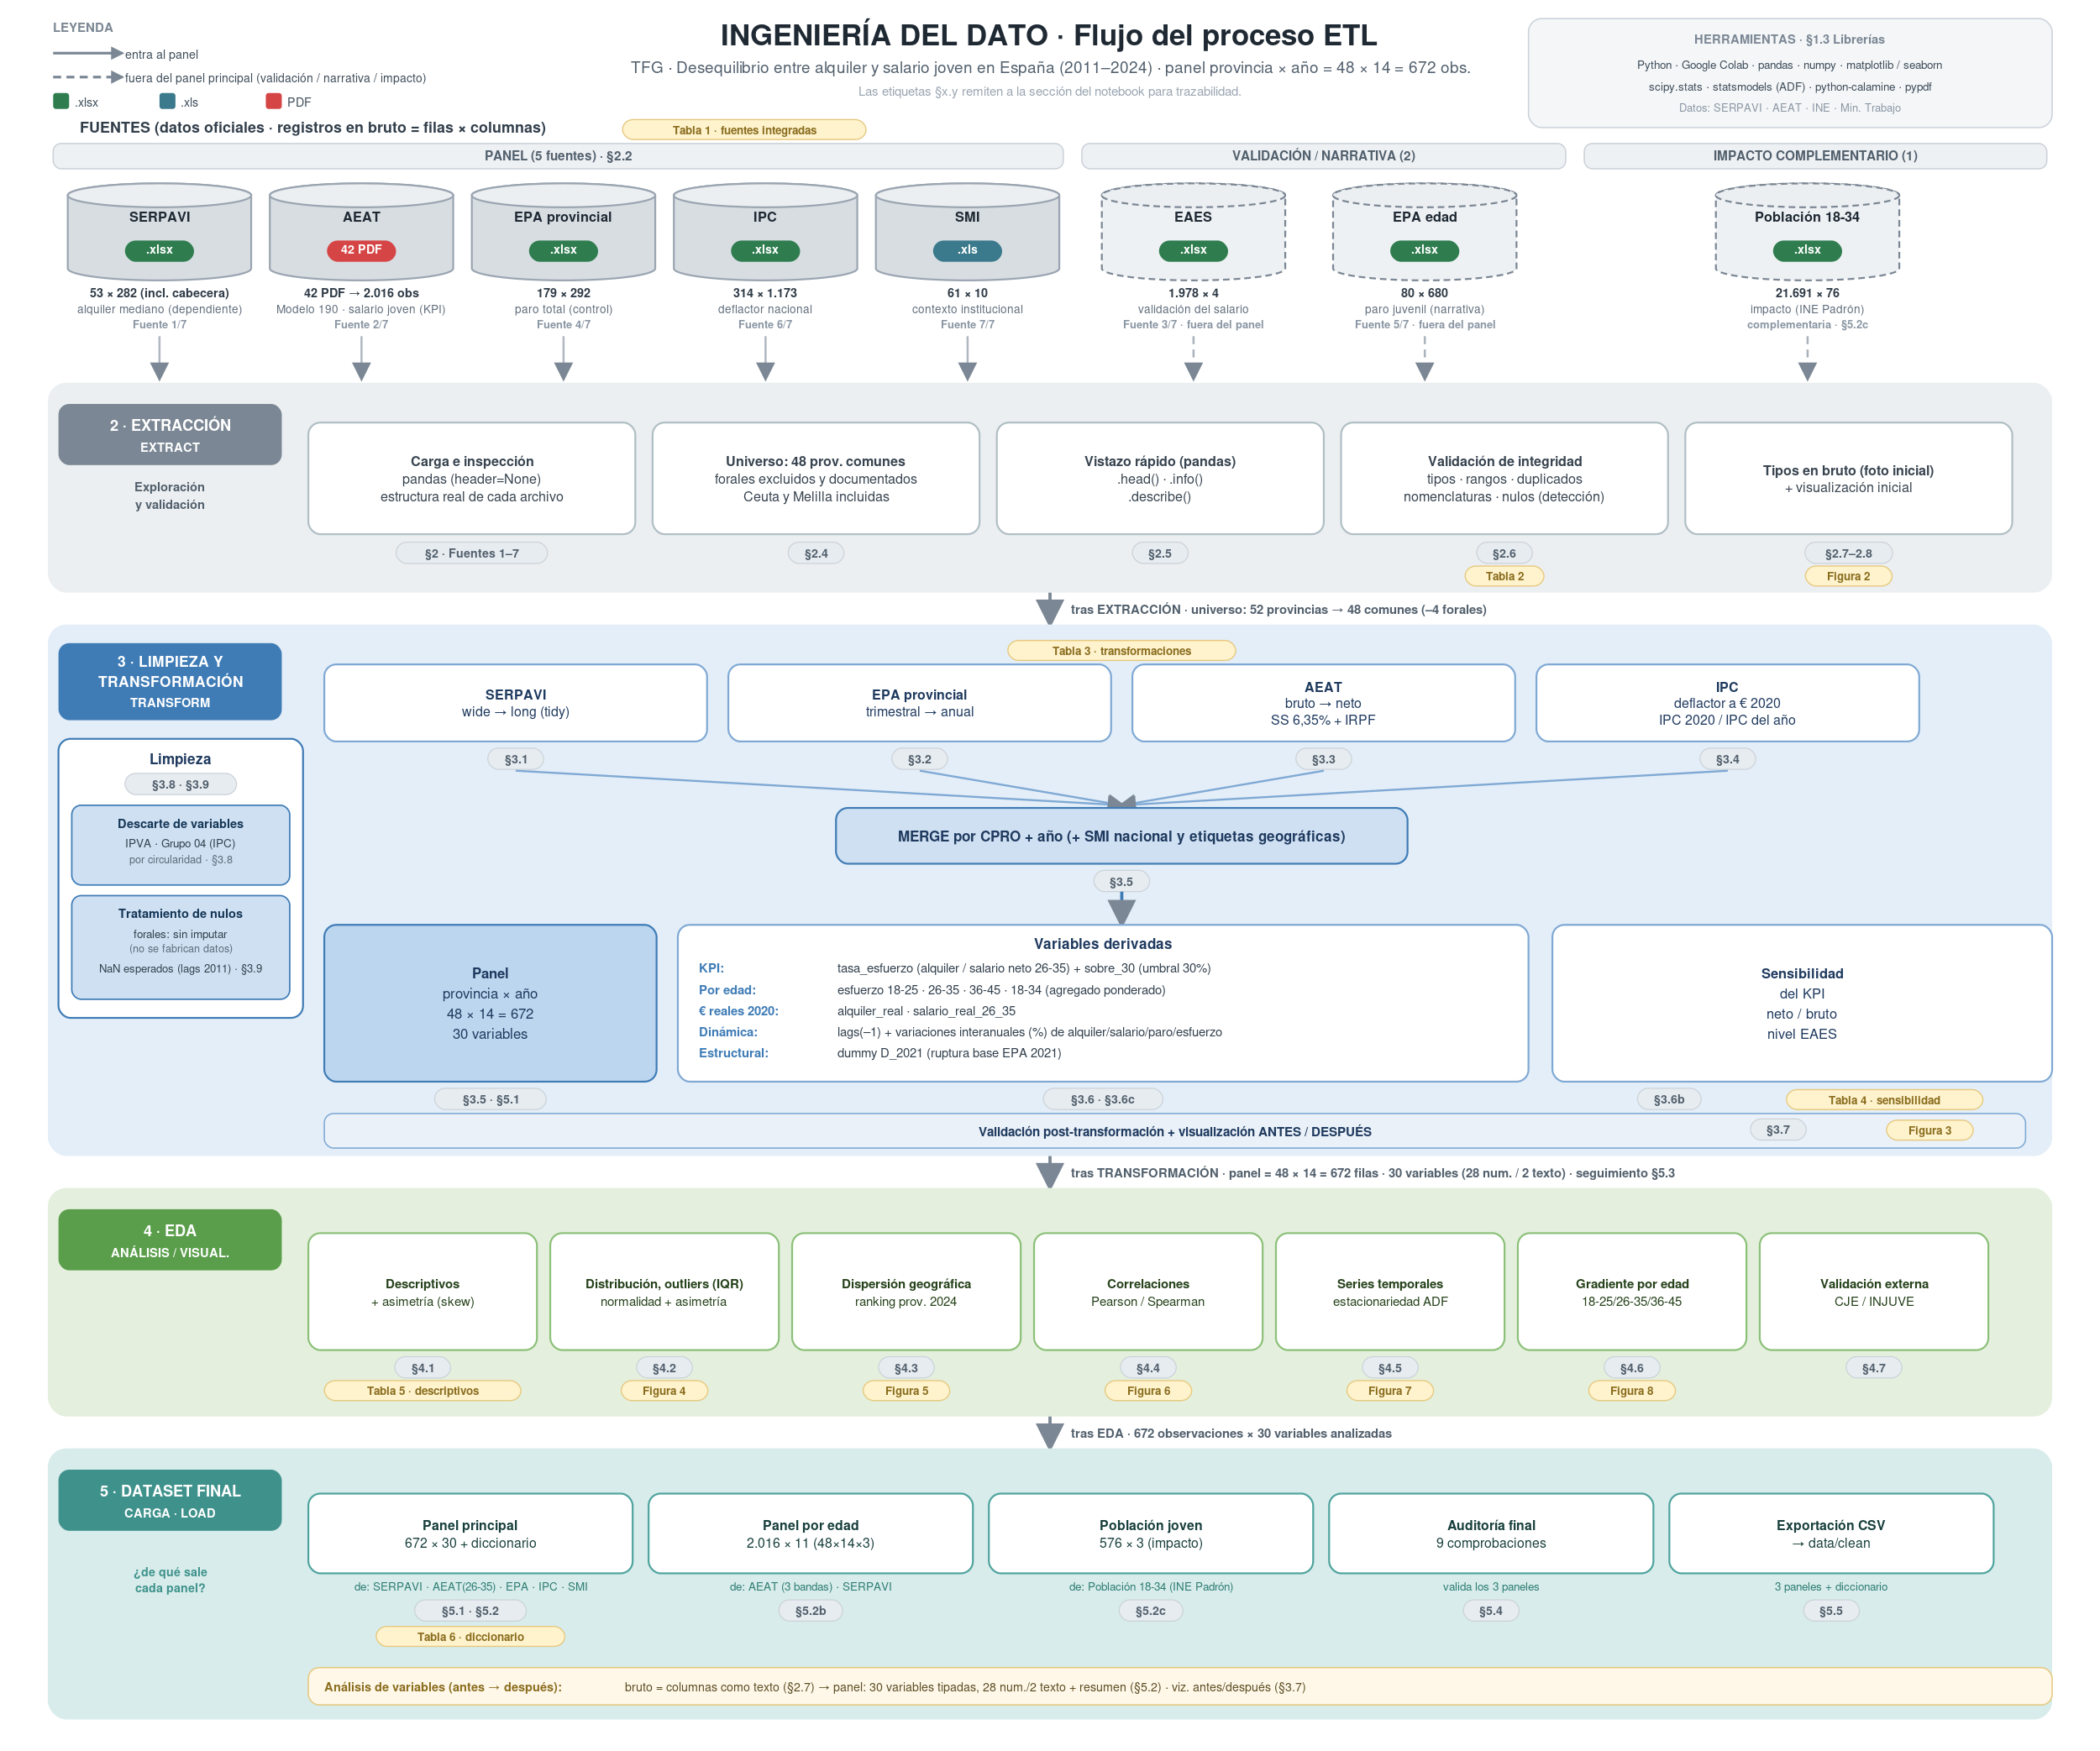

*Figura 1. Diagrama de flujo del proceso ETL de la Ingeniería del Dato. Las referencias §x.y que figuran en el diagrama remiten a las secciones del cuaderno de código. Fuente: elaboración propia.*

### **2.4 Decisión metodológica transversal: granularidades y universo**

*Universo: 48 provincias de régimen fiscal común.* La AEAT, fuente del salario, deja fuera al País Vasco y a Navarra por su régimen foral, y el SERPAVI, fuente del alquiler, no cubre esas provincias de forma homogénea entre 2011 y 2024 (solo aparecen datos sueltos en años recientes). Para que numerador y denominador del KPI compartan el mismo terreno, el análisis se define sobre las 48 provincias comunes, Ceuta y Melilla incluidas; las 4 forales se excluyen y se documentan. No se imputan: rellenar provincias que las propias fuentes excluyen equivaldría a fabricar datos.

*Salario a escala provincial, sin estimación sintética.* Como la AEAT facilita el salario por provincia y edad, no hace falta recurrir a estimaciones indirectas por ratio. La EAES, que solo llega al nivel de CC.AA., queda como validación del nivel y la tendencia del salario de la AEAT.

*Variables nacionales dentro de un panel provincial.* El IPC entra como deflactor nacional —una vara común para comparar valores reales entre provincias, que además se cancela en el KPI por tratarse de un cociente del mismo año— y el SMI como contexto. Que no varíen por provincia es correcto: la variación territorial la aportan el SERPAVI, la AEAT y la EPA provincial.

In [2]:
# ═
# ══════════════════════════════════════════════════════════════════
# SECCIÓN 2 · Tabla de correspondencia geográfica provincia → CC.AA.
# Fuente: codificación oficial INE (códigos de provincia 01–52)
# Propósito: clave de unión entre fuentes provinciales y autonómicas
# ══════════════════════════════════════════════════════════════════

PROV_CCAA = {
     1:('Araba/Álava',             'País Vasco'),
     2:('Albacete',                'Castilla - La Mancha'),
     3:('Alicante/Alacant',        'Comunitat Valenciana'),
     4:('Almería',                 'Andalucía'),
     5:('Ávila',                   'Castilla y León'),
     6:('Badajoz',                 'Extremadura'),
     7:('Balears, Illes',          'Balears, Illes'),
     8:('Barcelona',               'Cataluña'),
     9:('Burgos',                  'Castilla y León'),
    10:('Cáceres',                 'Extremadura'),
    11:('Cádiz',                   'Andalucía'),
    12:('Castellón/Castelló',      'Comunitat Valenciana'),
    13:('Ciudad Real',             'Castilla - La Mancha'),
    14:('Córdoba',                 'Andalucía'),
    15:('Coruña, A',              'Galicia'),
    16:('Cuenca',                  'Castilla - La Mancha'),
    17:('Girona',                  'Cataluña'),
    18:('Granada',                 'Andalucía'),
    19:('Guadalajara',             'Castilla - La Mancha'),
    20:('Gipuzkoa',                'País Vasco'),
    21:('Huelva',                  'Andalucía'),
    22:('Huesca',                  'Aragón'),
    23:('Jaén',                    'Andalucía'),
    24:('León',                    'Castilla y León'),
    25:('Lleida',                  'Cataluña'),
    26:('Rioja, La',              'Rioja, La'),
    27:('Lugo',                    'Galicia'),
    28:('Madrid',                  'Madrid, Comunidad de'),
    29:('Málaga',                  'Andalucía'),
    30:('Murcia',                  'Murcia, Región de'),
    31:('Navarra',                 'Navarra, Comunidad Foral de'),
    32:('Ourense',                 'Galicia'),
    33:('Asturias',                'Asturias, Principado de'),
    34:('Palencia',                'Castilla y León'),
    35:('Palmas, Las',            'Canarias'),
    36:('Pontevedra',              'Galicia'),
    37:('Salamanca',               'Castilla y León'),
    38:('Santa Cruz de Tenerife',  'Canarias'),
    39:('Cantabria',               'Cantabria'),
    40:('Segovia',                 'Castilla y León'),
    41:('Sevilla',                 'Andalucía'),
    42:('Soria',                   'Castilla y León'),
    43:('Tarragona',               'Cataluña'),
    44:('Teruel',                  'Aragón'),
    45:('Toledo',                  'Castilla - La Mancha'),
    46:('Valencia/València',       'Comunitat Valenciana'),
    47:('Valladolid',              'Castilla y León'),
    48:('Bizkaia',                 'País Vasco'),
    49:('Zamora',                  'Castilla y León'),
    50:('Zaragoza',                'Aragón'),
    51:('Ceuta',                   'Ceuta'),
    52:('Melilla',                 'Melilla'),
}

df_geo = pd.DataFrame.from_dict(
    PROV_CCAA, orient='index',
    columns=['provincia', 'ccaa']
).reset_index().rename(columns={'index': 'cpro'})

print(f"Tabla geográfica: {len(df_geo)} provincias · {df_geo['ccaa'].nunique()} CC.AA.\n")
dist = df_geo['ccaa'].value_counts().sort_values(ascending=False)
print(f"  {'CC.AA.':<35} {'Provincias':>10}  Distribución")
print("  " + "─" * 70)
for ccaa, n in dist.items():
    print(f"  {ccaa:<35} {n:>5}       {'█' * n}")

print(f"\n  Provincias forales EXCLUIDAS del universo (régimen foral): {PROV_FORALES}")
print(f"  Universo de análisis: {len(CPRO_COMUN)} provincias de régimen común (incluidas Ceuta y Melilla)")
print(f"\n  [✓] df_geo creada y disponible para los merges posteriores.")

Tabla geográfica: 52 provincias · 19 CC.AA.

  CC.AA.                              Provincias  Distribución
  ──────────────────────────────────────────────────────────────────────
  Castilla y León                         9       █████████
  Andalucía                               8       ████████
  Castilla - La Mancha                    5       █████
  Galicia                                 4       ████
  Cataluña                                4       ████
  Comunitat Valenciana                    3       ███
  País Vasco                              3       ███
  Aragón                                  3       ███
  Extremadura                             2       ██
  Canarias                                2       ██
  Balears, Illes                          1       █
  Rioja, La                               1       █
  Madrid, Comunidad de                    1       █
  Navarra, Comunidad Foral de             1       █
  Murcia, Región de                       1       █
  Astu

### **Interpretación de la tabla geográfica**

La tabla recoge 52 provincias repartidas en 19 entidades; el universo de análisis son las 48 de régimen fiscal común, una vez apartadas las 4 forales (Araba/Álava, Gipuzkoa, Bizkaia y Navarra). El reparto es muy desigual: Castilla y León concentra 9 provincias, mientras que Madrid, Navarra, Cantabria, La Rioja, Baleares, Asturias, Murcia, Ceuta y Melilla tienen una sola.

De esa heterogeneidad se derivan varias consecuencias metodológicas:

- En el plano geográfico, las comunidades con más provincias muestran mayor variabilidad interna, lo que refuerza la decisión de trabajar a escala provincial y no autonómica.
- En cuanto al IPC, se usa solo como deflactor nacional (Índice general); no se asigna un IPC autonómico a las provincias, ya que el salario y el alquiler vienen de la AEAT y el SERPAVI, que ya son provinciales.
- Respecto a las 4 forales, quedan fuera del universo porque la AEAT las excluye por su régimen fiscal y el SERPAVI no las cubre de forma homogénea. La exclusión queda documentada.

La tabla `df_geo` hace de columna vertebral del merge final: es la clave territorial que une las fuentes provinciales (SERPAVI, AEAT, EPA provincial) y valida las correspondencias autonómicas de las fuentes de apoyo (EAES, EPA edad). El IPC no se asigna territorialmente; funciona únicamente como deflactor nacional.

---

### **Fuente 1 de 7 — SERPAVI** · (PANEL — variable dependiente)
#### **Sistema Estatal de Referencia del Precio del Alquiler de Vivienda**
#### Ministerio de Vivienda y Agenda Urbana · Gobierno de España

---

**¿Qué es el SERPAVI?**

El SERPAVI es la única fuente oficial española que publica precios absolutos de alquiler residencial (en euros al mes) con desagregación provincial. Lo creó el Ministerio de Vivienda como instrumento de seguimiento del mercado de alquiler para dar apoyo a las políticas públicas.

**¿Cómo se recogen los datos?**

A diferencia de los portales inmobiliarios (Idealista, Fotocasa), que publican precios de *oferta* —lo que pide el propietario—, el SERPAVI parte de las declaraciones del IRPF (Modelo 100) que gestiona la AEAT. Son, por tanto, precios de contratos reales firmados y declarados a Hacienda. La diferencia no es menor: trabajar con precios de oferta introduciría un sesgo sistemático al alza y distorsionaría la tasa de esfuerzo que pagan de verdad los jóvenes.

**Variables disponibles** (por provincia, año y tipo de vivienda):

| Variable | Descripción | Unidad | Uso en este TFG |
|----------|-------------|--------|-----------------|
| `ALQTBID12_M_VC` | Alquiler mensual total **mediano** · vivienda colectiva | €/mes | **Variable dependiente principal** |
| `ALQTBID12_25_VC` | Percentil 25 del alquiler mensual | €/mes | Segmento asequible para jóvenes con salario bajo |
| `ALQTBID12_75_VC` | Percentil 75 del alquiler mensual | €/mes | Segmento alto · referencia de mercado |
| `ALQM2_LV_M_VC` | Alquiler mediano por m² | €/m²·mes | Control por tamaño de vivienda |
| `SLVM2_M_VC` | Superficie mediana de las viviendas | m² | Variable contextual |
| `BI_ALVHEPCO_TVC` | Número de contratos registrados | unidades | Volumen de mercado |

**Decisiones metodológicas sobre el SERPAVI**

La primera es trabajar solo con vivienda colectiva (pisos en edificios) y dejar fuera la unifamiliar. La población joven, aproximada con los grupos que ofrecen las fuentes oficiales (menores de 25 años y de 25 a 34), reside mayoritariamente en vivienda colectiva, y mezclar ambas tipologías distorsionaría la medida de asequibilidad.

La segunda es usar la mediana como estadístico central. La distribución de precios de alquiler es asimétrica hacia la derecha —las viviendas de lujo tiran de la media al alza—, de modo que la mediana representa mejor el precio que paga un joven típico; es, además, el estadístico que emplea el Ministerio en sus informes.

La tercera afecta a los territorios forales: el Modelo 100 no los cubre (Álava, Gipuzkoa, Bizkaia y Navarra) salvo incorporación tardía. Como la AEAT también los excluye por la misma razón fiscal, el análisis se define sobre las 48 provincias comunes y los forales se documentan como exclusión, sin imputarlos.

> **Descarga:** `mivau.gob.es/vivienda/alquila-bien-es-tu-derecho/serpavi`
> **Formato:** Excel (.xlsx) · hoja `Provincias` · formato wide (una columna por año)
> **Última actualización:** Marzo 2026 (datos hasta 2024 incluido)

In [3]:
# ═
# ══════════════════════════════════════════════════════════════════
# SECCIÓN 2 · Carga e inspección del SERPAVI
# Objetivo: cargar la hoja 'Provincias', identificar estructura,
#           detectar NaN y verificar coherencia de los valores
# ══════════════════════════════════════════════════════════════════

print("=" * 65)
print("  FUENTE 1/7: SERPAVI — Ministerio de Vivienda")
print("=" * 65)

df_serpavi_raw = pd.read_excel(ARCH['serpavi'][0], sheet_name='Provincias')

# ── Estructura del archivo ────────────────────────────────────────
print(f"\n  Hojas en el archivo:")
for h in pd.ExcelFile(ARCH['serpavi'][0]).sheet_names:
    print(f"    · {h}")

print(f"\n  Hoja 'Provincias':")
print(f"    Filas (provincias):   {len(df_serpavi_raw)}")
print(f"    Columnas (variables): {len(df_serpavi_raw.columns)}")

# ── Variables disponibles por tipo ───────────────────────────────
tipos = {
    'Mediana €/mes (VC)'     : [c for c in df_serpavi_raw.columns if c.startswith('ALQTBID12_M_VC_')],
    'P25 €/mes (VC)'         : [c for c in df_serpavi_raw.columns if c.startswith('ALQTBID12_25_VC_')],
    'P75 €/mes (VC)'         : [c for c in df_serpavi_raw.columns if c.startswith('ALQTBID12_75_VC_')],
    '€/m² mediana (VC)'      : [c for c in df_serpavi_raw.columns if c.startswith('ALQM2_LV_M_VC_')],
    'Superficie mediana (m²)': [c for c in df_serpavi_raw.columns if c.startswith('SLVM2_M_VC_')],
    'Nº contratos (VC)'      : [c for c in df_serpavi_raw.columns if c.startswith('BI_ALVHEPCO_TVC_')],
}

print(f"\n  Variables de interés identificadas:")
años_disponibles = []
for tipo, cols in tipos.items():
    años = sorted([int('20' + c[-2:]) for c in cols])
    if not años_disponibles:
        años_disponibles = años
    print(f"    {tipo:<28}  {len(cols)} años  ({años[0]}–{años[-1]})")

# ── Diagnóstico de NaN en variable principal ─────────────────────
print(f"\n  Diagnóstico NaN — alquiler mediano mensual (ALQTBID12_M_VC_XX):")
print(f"  {'Año':<8} {'NaN':>5}  {'Estado'}")
print("  " + "─" * 55)
for año in años_disponibles:
    col = f'ALQTBID12_M_VC_{str(año)[-2:]}'
    mask = df_serpavi_raw[col].isna()
    n = mask.sum()
    if n > 0:
        provs = ', '.join(df_serpavi_raw.loc[mask, 'LITPRO'].tolist())
        print(f"  {año:<8} {n:>5}  ⚠ NaN en: {provs}")
    else:
        print(f"  {año:<8} {n:>5}  ✓ completo")

# ── Verificación de coherencia ────────────────────────────────────
print(f"\n  Verificación de coherencia: alquiler mediano 2015 vs 2024")
print(f"  {'Provincia':<30} {'2015':>8} {'2024':>8} {'Variación':>10}  Nivel")
print("  " + "─" * 70)

verificar = ['Madrid', 'Barcelona', 'Balears, Illes', 'Málaga',
             'Sevilla', 'Valencia/València', 'Albacete', 'Lugo', 'Zamora']
for prov in verificar:
    row = df_serpavi_raw[df_serpavi_raw['LITPRO'] == prov]
    if len(row):
        v15 = row['ALQTBID12_M_VC_15'].values[0]
        v24 = row['ALQTBID12_M_VC_24'].values[0]
        if pd.notna(v15) and pd.notna(v24):
            var = (v24 - v15) / v15 * 100
            nivel = 'Alto (>50%)' if var > 50 else ('Medio (30-50%)' if var > 30 else 'Bajo (<30%)')
            print(f"  {prov:<30} {v15:>7.0f}€ {v24:>7.0f}€ {var:>+9.1f}%  {nivel}")

# ── Resumen calculado desde los datos, sin hardcodes ─────────────
cols_alq_all = [f'ALQTBID12_M_VC_{str(a)[-2:]}' for a in años_disponibles]
nan_total_forales = sum(
    df_serpavi_raw[col].isna().sum()
    for col in cols_alq_all
    if col in df_serpavi_raw.columns
)
prov_2024_completas = df_serpavi_raw['ALQTBID12_M_VC_24'].notna().sum()
prov_2011_completas = df_serpavi_raw['ALQTBID12_M_VC_11'].notna().sum()

print(f"\n  Resumen calculado desde los datos:")
print(f"  · Total NaN en variable principal (todas las provincias, todos los años): {nan_total_forales}")
print(f"  · Provincias con dato en 2011: {prov_2011_completas} (territorio fiscal común)")
print(f"  · Provincias con dato en 2024: {prov_2024_completas} (todas)")
print(f"  · Provincias forales documentadas como sin cobertura SERPAVI (incorporación 2021–2024): {PROV_FORALES}")
print(f"  · Variable principal seleccionada: ALQTBID12_M_VC (mediana €/mes, VC)")
print(f"  · Clave territorial principal: CPRO (código INE)")
print(f"  · LITPRO: etiqueta legible — no usar como clave de merge")

  FUENTE 1/7: SERPAVI — Ministerio de Vivienda

  Hojas en el archivo:
    · Metadatos
    · CCAA
    · Provincias
    · Municipios
    · Distritos
    · Secciones censales

  Hoja 'Provincias':
    Filas (provincias):   52
    Columnas (variables): 282

  Variables de interés identificadas:
    Mediana €/mes (VC)            14 años  (2011–2024)
    P25 €/mes (VC)                14 años  (2011–2024)
    P75 €/mes (VC)                14 años  (2011–2024)
    €/m² mediana (VC)             14 años  (2011–2024)
    Superficie mediana (m²)       14 años  (2011–2024)
    Nº contratos (VC)             14 años  (2011–2024)

  Diagnóstico NaN — alquiler mediano mensual (ALQTBID12_M_VC_XX):
  Año        NaN  Estado
  ───────────────────────────────────────────────────────
  2011         4  ⚠ NaN en: Araba/Álava, Gipuzkoa, Navarra, Bizkaia
  2012         4  ⚠ NaN en: Araba/Álava, Gipuzkoa, Navarra, Bizkaia
  2013         4  ⚠ NaN en: Araba/Álava, Gipuzkoa, Navarra, Bizkaia
  2014         4  ⚠ NaN

### **Conclusiones — Fuente 1: SERPAVI**

El archivo tiene 52 filas (una por provincia) × 282 columnas, en formato *wide*: cada variable se despliega en una columna por año, con sufijos de `_11` a `_24`. En la Sección 3 se convierte a formato *long* (tidy), con una fila por observación provincia-año.

La calidad es alta para las 48 provincias del territorio fiscal común, y los valores encajan con la realidad del mercado (clasificación del crecimiento 2015–2024: bajo <30% · medio 30–50% · alto >50%):

| Provincia | 2015 | 2024 | Variación | Nivel |
|-----------|------|------|-----------|-------|
| Madrid | 570 €/mes | 800 €/mes | +40,4% | Medio |
| Barcelona | 529 €/mes | 753 €/mes | +42,4% | Medio |
| Baleares | 500 €/mes | 750 €/mes | +50,0% | Medio |
| Málaga | 431 €/mes | 677 €/mes | +57,0% | Alto |
| Sevilla | 450 €/mes | 610 €/mes | +35,6% | Medio |
| Lugo | 300 €/mes | 370 €/mes | +23,3% | Bajo |
| Zamora | 312 €/mes | 399 €/mes | +27,8% | Bajo |

La variación del alquiler mediano entre 2015 y 2024 difiere bastante de una provincia a otra, con subidas que van del +23% de Lugo al +57% de Málaga según los valores calculados en la celda anterior. Esa dispersión geográfica es, de hecho, una de las hipótesis de trabajo que se examinará a fondo en el EDA.

En cuanto a los valores faltantes, el código detecta 47 NaN, todos en las 4 provincias forales: de las 56 celdas posibles solo 9 tienen dato, por la incorporación tardía y no homogénea del SERPAVI. Como la AEAT las excluye por régimen fiscal, quedan fuera del universo; las 48 provincias comunes tienen cobertura completa entre 2011 y 2024 y el panel no contiene ningún NaN en el alquiler. La exclusión se documenta y no se imputa.

> **Variable seleccionada para el análisis:** `ALQTBID12_M_VC` — alquiler mensual total mediano para vivienda colectiva, la más representativa del precio real que paga un joven inquilino en España.

---

### **Fuente 2 de 7 — AEAT · Salario provincial por edad** · (PANEL — denominador del KPI)
#### **Mercado de Trabajo y Pensiones en las Fuentes Tributarias** · Agencia Tributaria

---

**¿Qué es y por qué es la fuente de salarios?**

La estadística *Mercado de Trabajo y Pensiones en las Fuentes Tributarias* de la AEAT se basa en el Modelo 190 (declaración de retenciones sobre rendimientos del trabajo). Publica el salario medio por provincia y tramo de edad, lo que permite obtener el salario joven a escala provincial, algo que la EAES (limitada a CC.AA.) no ofrece. Es, además, una fuente tributaria igual que el SERPAVI, así que ambas comparten universo y filosofía: datos fiscales reales.

**Cobertura y coherencia con el SERPAVI.** La AEAT cubre el Territorio de Régimen Fiscal Común (48 provincias, Ceuta y Melilla incluidas) y excluye el País Vasco y Navarra; al restringir a las 48 provincias comunes comparte el mismo universo final que el SERPAVI, que tampoco cubre las forales de forma homogénea. Por eso el análisis se fija en esas 48 provincias y los forales quedan como caso especial documentado tanto en el numerador como en el denominador.

**Bandas de edad utilizadas:** `De 18 a 25`, `De 26 a 35` y `De 36 a 45`. La banda principal del KPI es la de 26-35 (núcleo de la emancipación, comparable a la franja 25-34 de la EAES); las de 18-25 (precariedad) y 36-45 (referencia adulta) alimentan el gradiente por edad, y el agregado 18-34 se reporta por comparabilidad con la definición de juventud de Eurostat.

**Medida de salario:** salario medio anual = masa salarial / nº de perceptores. Recoge ingresos reales declarados (incluido el trabajo a tiempo parcial o de parte del año), por lo que para los más jóvenes resulta bajo; esto se interpreta como una cota superior de la tasa de esfuerzo, coherente con la precariedad juvenil.

> **Acceso:** `sede.agenciatributaria.gob.es` → Mercado de Trabajo y Pensiones en las Fuentes Tributarias → tabla "salarios por provincia, edad y sexo".
> **Formato:** PDF · 1 archivo por banda y año (3 bandas × 14 años = 42 PDF) · `AEAT_<banda>_<año>.pdf`.

In [4]:
# Parseo de los 42 PDF de AEAT -> salario medio por provincia (CPRO), año y
# banda de edad. Sin hardcodes: todo se lee de los PDF. Los nombres de AEAT
# cambian entre años (Orense/Ourense, Comunidad/Comunitat...) -> mapa de alias.
# ══════════════════════════════════════════════════════════════════
import glob, re
print("=" * 65); print("  FUENTE 2/7: AEAT — salario provincial por edad (Modelo 190)"); print("=" * 65)

_PROV_AEAT = {
 'albacete':2,'alicante':3,'almería':4,'almeria':4,'ávila':5,'avila':5,'badajoz':6,
 'illes balears':7,'balears,illes':7,'balears, illes':7,'barcelona':8,'burgos':9,'cáceres':10,'caceres':10,
 'cádiz':11,'cadiz':11,'castellón':12,'castellon':12,'ciudad real':13,'córdoba':14,'cordoba':14,
 'a coruña':15,'la coruña':15,'a coruna':15,'cuenca':16,'girona':17,'gerona':17,'granada':18,'guadalajara':19,
 'huelva':21,'huesca':22,'jaén':23,'jaen':23,'león':24,'leon':24,'lleida':25,'lérida':25,'lerida':25,
 'la rioja':26,'rioja, la':26,'lugo':27,'comunidad de madrid':28,'madrid, comunidad de':28,'málaga':29,'malaga':29,
 'región de murcia':30,'murcia, región de':30,'region de murcia':30,'ourense':32,'orense':32,
 'principado de asturias':33,'asturias, principado de':33,'palencia':34,'las palmas':35,'pontevedra':36,
 'salamanca':37,'s. c. tenerife':38,'santa cruz de tenerife':38,'cantabria':39,'segovia':40,'sevilla':41,
 'soria':42,'tarragona':43,'teruel':44,'toledo':45,'valencia':46,'valladolid':47,'zamora':49,'zaragoza':50,
 'ciudad de ceuta':51,'ceuta':51,'ciudad de melilla':52,'melilla':52,
}
_SKIPSTART = ('http','unidad','asalariados','por persona','medio','empleo','perceptor',
              'provincia','sexo','tramos','ejercicio','tramo','05/','06/','total ')

def _parse_aeat_pdf(ruta):
    txt = "\n".join((p.extract_text() or "") for p in PdfReader(ruta).pages)
    out = {}
    for ln in txt.splitlines():
        ln = ln.strip()
        if not ln or ln.lower().startswith(_SKIPSTART):
            continue
        toks = re.findall(r'\d[\d.]*', ln)
        if len(toks) < 2:
            continue
        m = re.match(r'^([^\d]+?)\s+\d', ln)
        if not m:
            continue
        name = m.group(1).strip().lower()
        if name in _PROV_AEAT:
            out[_PROV_AEAT[name]] = (int(toks[0].replace('.', '')), int(toks[-1].replace('.', '')))
    return out

_BANDAS = {'18_25':'sal_18_25', '26_35':'sal_26_35', '36_45':'sal_36_45'}
_rows = []
_avisos_banda = []
for ruta in sorted(glob.glob(f'{DIR_AEAT}/AEAT_*_*.pdf')):
    mm = re.search(r'AEAT_(\d+_\d+)_(\d{4})', ruta)
    banda, año = mm.group(1), int(mm.group(2))
    # Verificación: la banda de la cabecera del PDF debe coincidir con el nombre
    _cab = (PdfReader(ruta).pages[0].extract_text() or '').upper()
    _mb = re.search(r'(?:TRAMO DE EDAD|EDAD):\s*DE (\d+) A (\d+)', _cab)
    if _mb and f'{_mb.group(1)}_{_mb.group(2)}' != banda:
        _avisos_banda.append(f'{ruta.split("/")[-1]} contiene banda {_mb.group(1)}-{_mb.group(2)}')
    for cp, (n_asal, val) in _parse_aeat_pdf(ruta).items():
        _rows.append({'cpro': cp, 'año': año, 'banda': _BANDAS[banda],
                      'salario_bruto': val, 'asalariados': n_asal})

df_aeat_long = pd.DataFrame(_rows)
_sal = df_aeat_long.pivot_table(index=['cpro', 'año'], columns='banda', values='salario_bruto')
_n   = df_aeat_long.pivot_table(index=['cpro', 'año'], columns='banda', values='asalariados')
_n.columns = [c.replace('sal_', 'n_') for c in _n.columns]
df_aeat = _sal.join(_n).reset_index()
df_aeat = df_aeat[(df_aeat['año'] >= ANIO_INICIO) & (df_aeat['año'] <= ANIO_FIN)]

# ── Diagnóstico ───────────────────────────────────────────────────
n_pdf = len(glob.glob(f'{DIR_AEAT}/AEAT_*_*.pdf'))
if n_pdf != 42:
    raise FileNotFoundError(f'AEAT: se esperaban 42 PDF (3 bandas x 14 años) y se encontraron {n_pdf} en {DIR_AEAT}')
print(f"\n  PDF leídos: {n_pdf}  (3 bandas × 14 años = 42)")
print(f"  Provincias: {df_aeat['cpro'].nunique()}  (48 comunes; sin forales)")
print(f"  Forales presentes (debe ser 0): {df_aeat['cpro'].isin(CPRO_FORALES).sum()}")
print(f"  Filas: {len(df_aeat)}  (48 × 14 = 672)")
print(f"  NaN por banda: "
      f"{df_aeat[['sal_18_25','sal_26_35','sal_36_45']].isna().sum().to_dict()}")
print(f"\n  Gradiente medio provincial 2024 (€/año bruto):")
g = df_aeat[df_aeat['año'] == 2024][['sal_18_25','sal_26_35','sal_36_45']].mean().round(0)
print(f"    18-25: {g['sal_18_25']:.0f}   26-35: {g['sal_26_35']:.0f}   36-45: {g['sal_36_45']:.0f}")
print(f"\n  Verificación (Madrid 2024):")
_mad = df_aeat[(df_aeat.cpro==28)&(df_aeat.año==2024)].iloc[0]
print(f"    18-25={_mad.sal_18_25:.0f}  26-35={_mad.sal_26_35:.0f}  36-45={_mad.sal_36_45:.0f}")
if _avisos_banda:
    raise ValueError(f"PDF de AEAT con banda incoherente respecto al nombre del archivo (revisar la descarga): {_avisos_banda}")
else:
    print(f"\n  ✓ Verificación: la banda de cada PDF coincide con su nombre de archivo.")
print(f"\n  [✓] df_aeat creado (salario joven provincial). Banda KPI: 26-35.")

  FUENTE 2/7: AEAT — salario provincial por edad (Modelo 190)

  PDF leídos: 42  (3 bandas × 14 años = 42)
  Provincias: 48  (48 comunes; sin forales)
  Forales presentes (debe ser 0): 0
  Filas: 672  (48 × 14 = 672)
  NaN por banda: {'sal_18_25': 0, 'sal_26_35': 0, 'sal_36_45': 0}

  Gradiente medio provincial 2024 (€/año bruto):
    18-25: 9237   26-35: 19849   36-45: 24273

  Verificación (Madrid 2024):
    18-25=10160  26-35=26037  36-45=33972

  ✓ Verificación: la banda de cada PDF coincide con su nombre de archivo.

  [✓] df_aeat creado (salario joven provincial). Banda KPI: 26-35.


### **Conclusiones — Fuente 2: AEAT (salario provincial)**

La cobertura queda verificada: 48 provincias × 14 años = 672 observaciones por banda, con 0 NaN. No hay forales (la AEAT los excluye por el régimen fiscal y el SERPAVI tampoco los cubre de forma homogénea), de modo que numerador y denominador del KPI comparten exactamente el mismo universo.

El gradiente por edad se confirma (media provincial de 2024, en bruto anual, según la salida de la celda anterior): unos 9.200 € en la banda 18-25, 19.800 € en la 26-35 y 24.300 € en la 36-45. La banda más joven cobra menos de la mitad que el adulto asentado, punto de partida del análisis de precariedad.

En cuanto a las decisiones, la banda principal del KPI es la de 26-35; las de 18-25 y 36-45 sirven para el gradiente y el agregado 18-34 se reporta por comparabilidad con Eurostat. El salario es bruto; en la Sección 3 se convierte a neto (cotización a la Seguridad Social más IRPF efectivo). Como la medida de la AEAT (masa / perceptores) refleja ingresos reales declarados, la tasa de esfuerzo resultante es una cota superior.

---

### **Fuente 3 de 7 — EAES** · (VALIDACIÓN del salario)
#### **Encuesta Anual de Estructura Salarial · INE** · Tabla t=28201

---

**¿Qué papel tiene la EAES?**

La EAES mide los salarios brutos anuales según las características del trabajador (edad, sexo), pero solo desagrega por CC.AA., no por provincia. Por eso no es la fuente del salario del panel —ese papel lo cumple la AEAT, que sí es provincial—, sino que se emplea para validar que el nivel y la tendencia del salario joven de la AEAT son coherentes con una fuente independiente del INE.

**Grupos de edad disponibles (Ambos sexos):** `Todas las edades`, `Menos de 25`, `De 25 a 34`, `De 35 a 44`, `De 45 a 54` y `55 y más`. Para validar se usa la franja `De 25 a 34`, equivalente aproximada a la banda 26-35 de la AEAT.

**Cobertura:** 17 CC.AA. más el Total Nacional, de 2008 a 2024, con frecuencia anual. No publica Ceuta ni Melilla, lo que resulta irrelevante para su papel de validación.

**Sobre los valores negativos del INE:** son una convención del INE para señalar baja fiabilidad muestral, no salarios negativos. Se conservan en valor absoluto con la bandera `baja_fiabilidad` y no se transforman en NaN.

La EAES confirma la brecha salarial por edad —el grupo 25-34 cobra menos que el conjunto— y permite contrastar de forma independiente la tendencia del salario joven provincial de la AEAT.

**Datos verificados — salario anual bruto, grupo 25–34 años, Ambos sexos (validación):**

| CC.AA. | 2011 | 2015 | 2024 | Var. 2015–2024 |
|--------|------|------|------|----------------|
| Total Nacional | 19.269 € | 18.252 € | 25.103 € | +37,5% |
| Madrid | 21.829 € | 20.929 € | 29.362 € | +40,3% |
| Andalucía | 16.970 € | 15.911 € | 20.580 € | +29,3% |
| Extremadura | 16.241 € | 14.680 € | 19.907 € | +35,6% |
| País Vasco | 22.822 € | 22.437 € | 28.035 € | +24,9% |

> Estos niveles se contrastan con la AEAT (banda 26-35): la EAES queda por encima al usar una medida de ganancia anual más completa, del orden de ≈13% en Madrid y ≈22% en el agregado nacional ponderado (ver la sensibilidad en 3.6b); para la validación, lo relevante es que coincide la tendencia.
> **Acceso:** `ine.es/jaxiT3/Tabla.htm?t=28201` · estructura jerárquica CC.AA. → grupo edad → año · 1.978 × 4.

In [5]:
# ═
# ══════════════════════════════════════════════════════════════════
# SECCIÓN 2 · Carga e inspección de la EAES (salario por edad y CC.AA.)
# Objetivo: parsear la estructura jerárquica del INE y extraer el
#           salario anual ('Ambos sexos') por grupo de edad y CC.AA.
#
# ESTRUCTURA REAL del archivo (4 columnas):
#   col 0 = etiqueta jerárquica por SANGRÍA:
#           · sin sangría  -> entidad (Total Nacional / CC.AA.)
#           · 4 espacios   -> grupo de edad ("De 25 a 34 años", ...)
#           · 8 espacios   -> año ("2024", "2023", ...)
#   col 1 = Ambos sexos | col 2 = Mujeres | col 3 = Hombres
# El parser se basa en el CONTENIDO (no en el nº de espacios) para ser robusto.
# ══════════════════════════════════════════════════════════════════
import re

df_eaes_raw = pd.read_excel(ARCH['eaes'][0], header=None)

print("=" * 65)
print("  FUENTE 3/7: EAES — INE (t=28201)  [validación del salario]")
print("=" * 65)
print(f"\n  Shape raw: {df_eaes_raw.shape[0]} filas × {df_eaes_raw.shape[1]} columnas")

# ── Inspección de la estructura jerárquica ─────────────────────────
print(f"\n  Estructura de las primeras filas (detección de jerarquía):")
for i in range(min(12, len(df_eaes_raw))):
    no_nan = [str(x) for x in df_eaes_raw.iloc[i].tolist() if pd.notna(x)]
    print(f"    Fila {i:>2}: {no_nan[:5]}")

# ── Localizar la fila de cabecera de sexos (col 1 == 'Ambos sexos') ─
fila_sexos = None
for i in range(min(15, len(df_eaes_raw))):
    if str(df_eaes_raw.iloc[i, 1]).strip() == 'Ambos sexos':
        fila_sexos = i
        break
COL_AMBOS = 1   # columna 'Ambos sexos' = salario que usamos
print(f"\n  Fila de cabecera de sexos detectada: {fila_sexos}  "
      f"(col 1 = Ambos sexos, col 2 = Mujeres, col 3 = Hombres)")

# ── Funciones de clasificación de etiquetas ────────────────────────
GRUPOS_EDAD = ['Todas las edades', 'Menos de 25 años', 'De 25 a 34 años',
               'De 35 a 44 años', 'De 45 a 54 años', '55 y más años']

def es_anio(t):
    t = t.strip()
    return t.isdigit() and len(t) == 4 and 2000 <= int(t) <= 2030

def es_grupo_edad(t):
    t = t.strip()
    if any(t == g or t.startswith(g) for g in GRUPOS_EDAD):
        return True
    return bool(re.match(r'^(De \d+ a \d+ años|Menos de \d+ años|\d+ y más años)$', t))

META = ('resultados', 'ganancia', 'sexo y edad', 'unidades')

# ── Parseo jerárquico ──────────────────────────────────────────────
registros, ccaa_actual, grupo_actual = [], None, None
inicio = (fila_sexos + 1) if fila_sexos is not None else 0
for i in range(inicio, len(df_eaes_raw)):
    et = str(df_eaes_raw.iloc[i, 0]).strip()
    low = et.lower()
    if low in ('nan', '') or any(low.startswith(m) for m in META):
        continue
    if es_anio(et):
        if ccaa_actual and grupo_actual:
            val = pd.to_numeric(df_eaes_raw.iloc[i, COL_AMBOS], errors='coerce')
            registros.append({'ccaa': ccaa_actual, 'grupo_edad': grupo_actual,
                              'año': int(et), 'sal_anual_bruto': val})
    elif es_grupo_edad(et):
        grupo_actual = next((g for g in GRUPOS_EDAD if et == g or et.startswith(g)), et)
    elif len(et) > 2:                      # entidad: Total Nacional o CC.AA.
        ccaa_actual = et
        grupo_actual = None

df_eaes = pd.DataFrame(registros)
df_eaes = df_eaes[(df_eaes['año'] >= ANIO_INICIO) & (df_eaes['año'] <= ANIO_FIN)]

# ── Marcar valores con baja fiabilidad muestral (negativos en INE) ──
# El INE codifica con signo NEGATIVO los valores de baja fiabilidad muestral.
# El signo NO indica un salario negativo ni un dato inválido: la magnitud es la
# estimación publicada, solo que con menor fiabilidad. Por eso se CONSERVA el
# valor (en valor absoluto) y se marca con una bandera, en lugar de descartarlo
# (descartarlo perdería datos válidos; convertirlo en NaN sería un error).
df_eaes['quality_flag'] = np.where(
    df_eaes['sal_anual_bruto'] < 0, 'baja_fiabilidad',
    np.where(df_eaes['sal_anual_bruto'].isna(), 'sin_dato', 'observado'))
df_eaes['sal_anual_bruto'] = df_eaes['sal_anual_bruto'].abs()

print(f"\n  Registros parseados: {len(df_eaes)} (CC.AA. × grupo edad × año)")
print(f"  Entidades detectadas: {df_eaes['ccaa'].nunique()}  "
      f"(esperado: Total Nacional + 17 CC.AA.; la EAES por edad no publica Ceuta/Melilla)")
print(f"  Grupos de edad: {sorted(df_eaes['grupo_edad'].unique())}")
print(f"  Rango de años: {df_eaes['año'].min()}–{df_eaes['año'].max()}")
print(f"\n  Distribución de quality_flag:")
for flag, n in df_eaes['quality_flag'].value_counts().items():
    print(f"    {flag:<14}: {n}")

# ── Verificación: salario del grupo joven (25-34) en años clave ────
print(f"\n  Salario anual bruto · grupo 25-34 años · verificación:")
jov = df_eaes[df_eaes['grupo_edad'] == 'De 25 a 34 años']
piv = jov.pivot_table(index='ccaa', columns='año', values='sal_anual_bruto')
cols_ver = [c for c in [2011, 2015, 2024] if c in piv.columns]
muestra_ccaa = ['Total Nacional', 'Madrid, Comunidad de', 'Andalucía',
                'Extremadura', 'País Vasco']
muestra_ccaa = [c for c in muestra_ccaa if c in piv.index]
if muestra_ccaa and cols_ver:
    print(piv.loc[muestra_ccaa, cols_ver].round(0).to_string())
else:
    print("    (Revisar nombres de CC.AA.: la celda de validación de la Sección 2 comprobará")
    print("     la correspondencia con df_geo antes del merge de la Sección 3.)")

print(f"\n  [✓] df_eaes parseado y disponible para la VALIDACIÓN del salario (vs AEAT).")

  FUENTE 3/7: EAES — INE (t=28201)  [validación del salario]

  Shape raw: 1978 filas × 4 columnas

  Estructura de las primeras filas (detección de jerarquía):
    Fila  0: ['Resultados nacionales y por comunidades aútonomas']
    Fila  1: ['Ganancia media anual por trabajador']
    Fila  2: []
    Fila  3: ['Sexo y edad']
    Fila  4: ['Unidades:   €']
    Fila  5: []
    Fila  6: [' ', 'Ambos sexos', 'Mujeres', 'Hombres']
    Fila  7: ['Total Nacional']
    Fila  8: ['    Todas las edades']
    Fila  9: ['        2024', '29540.26', '26904.9', '32057.55']
    Fila 10: ['        2023', '28049.94', '25591.31', '30372.49']
    Fila 11: ['        2022', '26948.87', '24359.82', '29381.84']

  Fila de cabecera de sexos detectada: 6  (col 1 = Ambos sexos, col 2 = Mujeres, col 3 = Hombres)

  Registros parseados: 1512 (CC.AA. × grupo edad × año)
  Entidades detectadas: 18  (esperado: Total Nacional + 17 CC.AA.; la EAES por edad no publica Ceuta/Melilla)
  Grupos de edad: ['55 y más años', 'D

### **Conclusiones — Fuente 3: EAES (validación)**

El archivo tiene 1.978 filas × 4 columnas (shape en bruto leído con `header=None`). La estructura es jerárquica por sangría en la columna 0: entidad (Total Nacional o CC.AA.) → grupo de edad → año, con los valores en las columnas *Ambos sexos*, *Mujeres* y *Hombres*. Esta inspección trabaja únicamente con la columna *Ambos sexos*.

El parseo, acotado al período 2011–2024, produce 1.512 registros = 18 entidades (Total Nacional más 17 CC.AA.) × 6 grupos de edad × 14 años. La EAES por edad no publica Ceuta ni Melilla, que se tratan aparte en la Sección 3. La cobertura es completa en estructura, aunque con distintos niveles de fiabilidad muestral:

| `quality_flag` | Registros | Significado |
|---|---|---|
| `observado` | 1.318 | Valor con fiabilidad muestral normal |
| `baja_fiabilidad` | 187 | Valor con baja fiabilidad muestral (codificado con signo negativo en origen). Se **conserva en valor absoluto** y se marca con bandera |
| `sin_dato` | 7 | Celda sin valor publicado |

Sobre los valores negativos conviene insistir: los que aparecen así en el archivo del INE no son salarios negativos. Según la metodología de la EAES, el signo negativo es la convención del INE para marcar cifras de baja fiabilidad muestral (muestras reducidas, sujetas a mayor variabilidad). Aquí el valor se conserva en valor absoluto —la magnitud es la estimación publicada por el INE— y se etiqueta como `baja_fiabilidad`. Así no se descartan datos válidos: el modelado podrá decidir si los pondera, los filtra o los usa con cautela, sin perder la trazabilidad. Convertirlos en NaN habría supuesto tirar 187 observaciones reales.

En conjunto, el salario del grupo 25–34 es sistemáticamente inferior al del total de edades, y la amplitud de esa brecha varía entre comunidades. La EAES no entra en el panel; actúa como validación del salario provincial de la AEAT, con la franja 25-34 (≈ 26-35) como contraste de nivel y tendencia.

---

### **Fuentes 4 y 5 de 7 — EPA provincial (panel) y EPA por edad (narrativa)**
#### **Encuesta de Población Activa · INE** · Tablas t=65349 y t=65334

---

**¿Por qué hacen falta dos tablas de la EPA?**

La Encuesta de Población Activa es la fuente oficial del INE para el mercado laboral. Se necesitan dos tablas porque ninguna ofrece por sí sola lo que el análisis requiere: la t=65349 tiene desagregación provincial pero sin grupos de edad, y la t=65334 tiene grupos de edad pero solo a escala de CC.AA.

De la EPA provincial (t=65349) sale el paro total provincial, que entra como variable de control del panel (dato real). De la EPA por edad (t=65334) sale el paro juvenil de menores de 25 a escala nacional y autonómica, que se reserva para la narrativa. No se construye un paro joven provincial sintético, porque el INE no publica paro provincial por edad con fiabilidad.

**Tabla t=65349 — EPA por provincia:**

| Característica | Valor |
|----------------|-------|
| Granularidad | **53 entidades** (Total Nacional + 52 provincias) |
| Período | 2002T1–2026T1 (97 trimestres) |
| Indicadores | Tasa actividad · **Tasa paro** · Tasa empleo |
| Frecuencia | Trimestral → se agrega a **media anual** |
| Uso en el TFG | Tasa de paro total provincial (variable de control del análisis posterior) |

**Tabla t=65334 — EPA por edad y CC.AA.:**

| Característica | Valor |
|----------------|-------|
| Granularidad | **20 entidades** (Total Nacional + 17 CC.AA. + Ceuta + Melilla) |
| Período | 2002T1–2026T1 (97 trimestres por grupo) |
| Grupos de edad | Total · **Menores de 25 años** · 25 y más · 16–19 · 20–24 · **25–54** · 55+ |
| Frecuencia | Trimestral → se agrega a **media anual** |
| Uso en el TFG | Paro juvenil <25 nacional/autonómico (narrativa); **no** se imputa a provincias |

**Limitación del grupo de edad en la t=65334.** El INE no publica el grupo 25–34 de forma aislada en esta tabla. Se utiliza `Menores de 25 años` como indicador principal del paro joven, asumiendo que marca el límite superior de la presión laboral sobre los jóvenes (el paro en ese grupo es siempre mayor que en el 25–34). La limitación se hace constar de forma explícita.

**Ruptura metodológica de la EPA en 2021.** El INE cambió la base poblacional de referencia en el primer trimestre de 2021 (del Censo 2011 al Censo 2021), lo que genera una discontinuidad en la frontera 2020–2021 en algunas CC.AA. Al agregar los trimestres a media anual el efecto se atenúa, y en los modelos del Análisis del Dato se añadirá una variable dummy `D_2021 = 1 si año ≥ 2021` para absorber el quiebre estructural.

**Datos clave verificados:**

- El paro de menores de 25 años (Total Nacional) pasó del 51,4% en 2015T1 al 24,9% en 2024T4, según los valores comprobados en la celda de código anterior. Esa evolución se pondrá en relación con la del alquiler en el EDA.
- La tasa de paro total de Madrid bajó del 17,8% en 2015T1 al 8,6% en 2024T4, coherente con la recuperación del mercado laboral tras la crisis.

In [6]:
# ═
# ══════════════════════════════════════════════════════════════════
#  Carga e inspección EPA (t=65349 y t=65334)
# Objetivo: verificar estructura, indicadores, grupos de edad
#           y coherencia de valores para ambas tablas
# ══════════════════════════════════════════════════════════════════

print("=" * 65)
print("  FUENTES 4 y 5/7: EPA — INE (t=65349 y t=65334)")
print("=" * 65)

# ════════════════════════════════════════════════════════
# TABLA t=65349: Tasa de paro total por provincia
# ════════════════════════════════════════════════════════
df_epa49_raw = pd.read_excel(ARCH['epa_prov'][0], header=None)

print(f"\n  [t=65349 — Tasa de paro total por provincia]")
print(f"  Shape raw: {df_epa49_raw.shape[0]} filas × {df_epa49_raw.shape[1]} columnas")

fila6_49 = [str(v) for v in df_epa49_raw.iloc[6]
            if str(v).strip() not in ('nan','')]
fila7_49 = [str(v) for v in df_epa49_raw.iloc[7]
            if str(v).strip() not in ('nan','')]
n_trim_49 = len(fila7_49) // len(fila6_49)

print(f"  Indicadores: {fila6_49}")
print(f"  Trimestres por indicador: {n_trim_49}  ({fila7_49[-1]} a {fila7_49[0]})")

provs_49 = [str(df_epa49_raw.iloc[i, 0]).strip()
            for i in range(9, 62)
            if str(df_epa49_raw.iloc[i, 0]).strip() not in ('nan','')]
print(f"  Entidades (Ambos sexos): {len(provs_49)}  (Total Nacional + 52 provincias)")

# Verificar coherencia: Madrid tasa de paro
col_paro = 1 + n_trim_49
mad_row = next((i for i in range(9, 62)
                if '28' in str(df_epa49_raw.iloc[i, 0]) and
                'Madrid' in str(df_epa49_raw.iloc[i, 0])), None)

print(f"\n  Verificación coherencia — Madrid, tasa de paro total:")
print(f"  {'Trimestre':<12} {'Tasa paro':>10}")
print("  " + "─" * 26)
if mad_row:
    for j, trim in enumerate(fila7_49[:n_trim_49]):
        if any(t in trim for t in ['2011T1','2015T1','2020T1','2021T1','2024T4']):
            try:
                val = float(df_epa49_raw.iloc[mad_row, col_paro + j])
                print(f"  {trim:<12} {val:>9.2f}%")
            except:
                pass

# ════════════════════════════════════════════════════════
# TABLA t=65334: Tasa de paro por edad y CC.AA.
# ════════════════════════════════════════════════════════
df_epa34_raw = pd.read_excel(ARCH['epa_edad'][0], header=None)

print(f"\n  [t=65334 — Tasa de paro por grupo de edad y CC.AA.]")
print(f"  Shape raw: {df_epa34_raw.shape[0]} filas × {df_epa34_raw.shape[1]} columnas")

fila6_34 = [str(v) for v in df_epa34_raw.iloc[6]
            if str(v).strip() not in ('nan','')]
fila7_34 = [str(v) for v in df_epa34_raw.iloc[7]
            if str(v).strip() not in ('nan','')]
n_trim_34 = len(fila7_34) // len(fila6_34)

print(f"  Grupos de edad ({len(fila6_34)}): {fila6_34}")
print(f"  Trimestres por grupo: {n_trim_34}  ({fila7_34[-1]} a {fila7_34[0]})")

ccaa_34 = [str(df_epa34_raw.iloc[i, 0]).strip()
           for i in range(9, 29)
           if str(df_epa34_raw.iloc[i, 0]).strip() not in ('nan','')]
print(f"  Entidades: {len(ccaa_34)}")

# Verificar paro menores de 25 Total Nacional
# Grupo 'Menores de 25 años' = índice 1 → offset n_trim_34
col_m25 = 1 + n_trim_34
print(f"\n  Verificación coherencia — Paro menores de 25, Total Nacional:")
print(f"  {'Trimestre':<12} {'Tasa paro <25':>14}")
print("  " + "─" * 30)
for j, trim in enumerate(fila7_34[:n_trim_34]):
    if any(t in trim for t in ['2011T1','2015T1','2020T1','2021T1','2024T4']):
        try:
            val = float(df_epa34_raw.iloc[9, col_m25 + j])
            print(f"  {trim:<12} {val:>13.1f}%")
        except:
            pass

# ── Resumen compatibilidad ────────────────────────────────────────
print(f"\n  Compatibilidad entre ambas tablas EPA:")
print(f"  {'Tabla':<20} {'Período':<20} {'Geo':<25} {'Edad'}")
print("  " + "─" * 75)
print(f"  {'t=65349':<20} {'2002T1–2026T1':<20} {'52 provincias':<25} Sin desglose")
print(f"  {'t=65334':<20} {'2002T1–2026T1':<20} {'20 entidades':<25} 7 grupos")
print(f"\n  Uso en el panel (Sección 3):")
print(f"    - EPA provincial -> paro TOTAL provincial (media anual) = variable de control.")
print(f"    - EPA edad -> paro juvenil <25 nacional/autonomico = narrativa (NO entra al panel).")
print(f"    - No se construye paro joven provincial sintetico (sin dato provincial por edad fiable).")
print(f"    - Dummy D_2021 para la ruptura de base poblacional (Censo 2011 -> 2021).")
print(f"\n  [✓] df_epa49_raw y df_epa34_raw cargados. Disponibles para Sección 3.")

  FUENTES 4 y 5/7: EPA — INE (t=65349 y t=65334)

  [t=65349 — Tasa de paro total por provincia]
  Shape raw: 179 filas × 292 columnas
  Indicadores: ['Tasa de actividad', 'Tasa de paro de la población', 'Tasa de empleo de la población']
  Trimestres por indicador: 97  (2002T1 a 2026T1)
  Entidades (Ambos sexos): 53  (Total Nacional + 52 provincias)

  Verificación coherencia — Madrid, tasa de paro total:
  Trimestre     Tasa paro
  ──────────────────────────
  2024T4            8.58%
  2021T1           12.24%
  2020T1           10.60%
  2015T1           17.79%
  2011T1           15.18%

  [t=65334 — Tasa de paro por grupo de edad y CC.AA.]
  Shape raw: 80 filas × 680 columnas
  Grupos de edad (7): ['Total', 'Menores de 25 años', '25 y más años', 'De 16 a 19 años', 'De 20 a 24 años', 'De 25 a 54 años', 'De 55 y más años']
  Trimestres por grupo: 97  (2002T1 a 2026T1)
  Entidades: 20

  Verificación coherencia — Paro menores de 25, Total Nacional:
  Trimestre     Tasa paro <25
  ───────

### **Conclusiones — Fuentes 4 y 5: EPA**

Ambas tablas cubren 97 trimestres (2002T1–2026T1), bastante más que el período de análisis 2011–2024, lo que aporta contexto histórico y permite comprobar la coherencia de los datos.

El hallazgo más llamativo del período es la caída del paro de menores de 25 años, del 51,4% en 2015T1 al 24,9% en 2024T4: más de 26 puntos porcentuales en 9 años. En 2011T1 el paro juvenil era del 45,3%, lo que indica que el problema laboral de los jóvenes venía de antes de la crisis de 2012. Esto sugiere que la tensión de asequibilidad no se explica solo por el desempleo joven, que mejoró con fuerza; la relación entre paro, salario y alquiler se contrastará formalmente en el Análisis del Dato.

En el panel (Sección 3) estas fuentes se usan así:

1. *Paro total provincial (control).* De la EPA provincial (t=65349) se toma la *Tasa de paro* (Ambos sexos), agregada a media anual, como variable de control. Es dato observado, sin estimación.
2. *Paro juvenil <25 (narrativa, no panel).* De la EPA por edad (t=65334) se usa `Menores de 25` a escala nacional y autonómica (cayó del 51% al 25%). No se construye un paro joven provincial sintético, porque el INE no lo publica con fiabilidad muestral.
3. *Ruptura de base poblacional en 2021 y agregación.* La media anual atenúa la discontinuidad Censo 2011→2021, que además se controla con la dummy `D_2021`. Los trimestres se agregan a media anual para mantener la frecuencia anual del resto de fuentes.

---

### **Fuente 6 de 7 — IPC** · (PANEL — deflactor nacional)
#### **Índice de Precios de Consumo · INE** · Tabla t=76136

---

**¿Qué es el IPC y para qué se usa aquí?**

El Índice de Precios de Consumo mide la evolución del nivel general de precios de los bienes y servicios que consumen los hogares españoles. En este TFG cumple una sola función: deflactar. Convierte los precios nominales (euros corrientes) en precios reales (euros constantes de 2020) mediante el Índice general nacional. Sin deflactar, comparar 2011 con 2024 mezclaría el efecto de la inflación general con lo que de verdad interesa: cuánto subió el alquiler por encima o por debajo de esa inflación.

El IPC se emplea solo como deflactor (Índice general nacional) para expresar alquileres y salarios en euros constantes de 2020. No se usa el Grupo 04 (Vivienda) como control, porque incluye los propios alquileres como subcomponente y eso introduciría circularidad con la variable dependiente.

**Cobertura:**

| Característica | Valor |
|----------------|-------|
| Granularidad | **Nacional + 17 CC.AA. + Ceuta + Melilla** |
| Período | 2002M01–2026M05 (~293 meses; 1.172 columnas = ~293 meses × 4 medidas) |
| Base | Según el archivo (se rebasará a 2020 = 100 en la Sección 3) |
| Grupos ECOICOP | 13 grupos + Índice general |
| Frecuencia | Mensual → se agrega a **media anual** |

**Sobre la base del índice.** Se trabaja con base 2020 = 100. El año 2020 actúa como referencia operativa para expresar las magnitudes en términos reales; elegir el año base es una operación aritmética que no altera las variaciones relativas entre años ni entre CC.AA.

**Aislar la medida correcta.** El archivo del INE guarda cuatro medidas por mes (Índice, variación mensual, variación anual y variación en lo que va de año). Para el deflactor se utiliza exclusivamente la medida Índice; mezclarla con las variaciones daría una serie sin sentido económico.

**Compatibilidad con el panel.** Se usa el Índice general nacional como deflactor común para todas las provincias, una vara única para comparar valores reales. No se asigna un IPC autonómico por provincia: la variación territorial la aportan el SERPAVI, la AEAT y la EPA provincial.

> **Acceso:** `ine.es/jaxiT3/Tabla.htm?t=76136`
> **Formato:** Excel (.xlsx) · 314 filas × 1.173 columnas · estructura jerárquica CC.AA. → grupos ECOICOP

In [7]:
# ═
# ══════════════════════════════════════════════════════════════════
# SECCIÓN 2 · Carga e inspección del IPC (t=76136)
# Objetivo: extraer la serie ANUAL del Índice general Nacional para el
#           deflactor, aislando la medida 'Índice' del resto de medidas.
#
# CORRECCIÓN: el archivo del INE almacena 4 medidas por mes (Índice,
# Variación mensual, Variación anual y Variación en lo que va de año).
# Promediar las 4 juntas corrompe la serie (mezcla el nivel del índice
# con porcentajes de variación). Aquí se seleccionan SOLO las columnas
# cuya medida es 'Índice', de forma robusta a celdas combinadas.
# ══════════════════════════════════════════════════════════════════

print("=" * 65)
print("  FUENTE 6/7: IPC — INE (t=76136)")
print("=" * 65)

df_ipc_raw = pd.read_excel(ARCH['ipc'][0], header=None)
print(f"\n  Shape raw: {df_ipc_raw.shape[0]} filas × {df_ipc_raw.shape[1]} columnas")

# ── Detección automática de la fila de medidas y la de meses ──────
fila_medidas = None
for r in range(4, 9):
    txt = ' '.join(str(v).lower() for v in df_ipc_raw.iloc[r])
    if ('índice' in txt or 'indice' in txt) and 'variaci' in txt:
        fila_medidas = r
        break
if fila_medidas is None:
    fila_medidas = 6  # valor por defecto si no se detecta

fila_meses, mejor = 7, -1
for r in range(4, 10):
    cnt = sum(1 for v in df_ipc_raw.iloc[r]
              if isinstance(v, str) and len(v) >= 6
              and v[:4].isdigit() and 'M' in v[:7])
    if cnt > mejor:
        mejor, fila_meses = cnt, r

medidas_row = df_ipc_raw.iloc[fila_medidas].ffill()   # rellena celdas combinadas
meses_row   = df_ipc_raw.iloc[fila_meses]
print(f"  Fila de medidas: {fila_medidas}  ·  Fila de meses: {fila_meses}")

medidas_unicas = sorted(set(str(v).strip() for v in medidas_row
                            if str(v).strip() not in ('nan', '')))
print(f"\n  Medidas detectadas en el archivo:")
for m in medidas_unicas:
    print(f"    · {m}")

# ── Columnas que corresponden EXCLUSIVAMENTE a la medida 'Índice' ─
def es_indice(txt):
    t = str(txt).strip().lower()
    return ('índice' in t or 'indice' in t) and 'variaci' not in t

cols_indice = [c for c in range(1, df_ipc_raw.shape[1])
               if es_indice(medidas_row.iloc[c])
               and str(meses_row.iloc[c]).strip() not in ('nan', '')]

print(f"\n  Columnas de la medida 'Índice' aisladas: {len(cols_indice)}  "
      f"(deberían ser ~293, una por mes 2002M01–2026M05)")
if not (200 < len(cols_indice) < 400):
    print(f"  ⚠ AVISO: el nº de columnas Índice no es el esperado. "
          f"Revisar filas {fila_medidas}–{fila_meses} del Excel.")

# ── Entidades y grupos ECOICOP (estructura regular de 15 filas) ──
CCAA_IPC = {}
for i in range(8, 313, 15):
    v = str(df_ipc_raw.iloc[i, 0]).strip()
    if v and v not in ('nan', '') and not v.startswith(('Avance', 'Notas', 'INE')):
        CCAA_IPC[v] = i
print(f"\n  Entidades identificadas: {len(CCAA_IPC)} "
      f"(Nacional + 17 CC.AA. + Ceuta + Melilla)")

print(f"\n  Grupos ECOICOP por entidad (14 grupos):")
for i in range(9, 23):
    v = str(df_ipc_raw.iloc[i, 0]).strip()
    if v and v not in ('nan', ''):
        uso = ' <- USADO: deflactor (Índice general nacional)' if 'general' in v.lower() else ''
        print(f"    . {v}{uso}")

# ── Serie ANUAL del IPC general Nacional (fila 9), SOLO 'Índice' ──
# Nacional = fila 8 ; Índice general = fila 9
records_ipc = []
for c in cols_indice:
    mes = str(meses_row.iloc[c]).strip()
    try:
        anio = int(mes[:4])
        if ANIO_INICIO <= anio <= ANIO_FIN:
            records_ipc.append({'año': anio, 'ipc': float(df_ipc_raw.iloc[9, c])})
    except (ValueError, TypeError):
        pass

df_ipc_check = pd.DataFrame(records_ipc)
ipc_anual = df_ipc_check.groupby('año')['ipc'].mean()

print(f"\n  IPC General Nacional — media anual (Índice, base del archivo):")
print(f"  {'Año':<8} {'IPC medio':>10}")
print("  " + "─" * 22)
for anio, val in ipc_anual.items():
    marca = ' <- año base rebase' if anio == ANIO_BASE_IPC else ''
    print(f"  {anio:<8} {val:>9.3f}{marca}")

# ── Control de calidad: detectar SOLO caídas anómalas del índice ──
# España tuvo deflación leve en 2014, 2015, 2016 y 2020 (caídas < 1 punto),
# que son reales. Una caída brusca (> 2 puntos) sí indicaría error de parseo.
diffs    = ipc_anual.sort_index().diff().dropna()
anomalas = diffs[diffs < -2.0]
leves    = diffs[(diffs < -0.01) & (diffs >= -2.0)]
print(f"\n  Control de calidad de la serie del Índice:")
if len(anomalas) == 0:
    print(f"    ✓ Sin caídas anómalas: extracción del Índice correcta.")
    if len(leves):
        print(f"    (Caídas leves < 1 punto en {list(leves.index)}: "
              f"deflación real de esos años, no error de parseo.)")
else:
    print(f"    ⚠ Caídas anómalas (> 2 puntos) en {list(anomalas.index)} — revisar el parseo.")

# ── Factor de rebase a 2020 ───────────────────────────────────────
ipc_2020 = ipc_anual.get(ANIO_BASE_IPC)
ipc_2024 = ipc_anual.get(2024)
ipc_2015 = ipc_anual.get(2015)
print(f"\n  Factor de rebase a {ANIO_BASE_IPC}:")
print(f"    IPC_{ANIO_BASE_IPC} = {ipc_2020:.3f}")
print(f"    precio_real_{ANIO_BASE_IPC} = precio_nominal × ({ipc_2020:.3f} / IPC_año)")
print(f"  Ejemplos de deflactación:")
print(f"    2015: factor = {ipc_2020/ipc_2015:.4f}")
print(f"    2024: factor = {ipc_2020/ipc_2024:.4f}")

print(f"\n  Valores no nulos del archivo: {df_ipc_raw.notna().sum().sum():,}")
print(f"  [✓] df_ipc_raw cargado. Para deflactar se usa SOLO la medida Índice")
print(f"  general Nacional. Disponible para Sección 3.")

  FUENTE 6/7: IPC — INE (t=76136)

  Shape raw: 314 filas × 1173 columnas
  Fila de medidas: 6  ·  Fila de meses: 7

  Medidas detectadas en el archivo:
    · Variación anual
    · Variación en lo que va de año
    · Variación mensual
    · Índice

  Columnas de la medida 'Índice' aisladas: 293  (deberían ser ~293, una por mes 2002M01–2026M05)

  Entidades identificadas: 20 (Nacional + 17 CC.AA. + Ceuta + Melilla)

  Grupos ECOICOP por entidad (14 grupos):
    . Índice general <- USADO: deflactor (Índice general nacional)
    . 01 Alimentos y bebidas no alcohólicas
    . 02 Bebidas alcohólicas y tabaco
    . 03 Vestido y calzado
    . 04 Vivienda, agua, electricidad, gas y otros combustibles
    . 05 Muebles, artículos del hogar y artículos para el mantenimiento corriente del hogar
    . 06 Sanidad
    . 07 Transporte
    . 08 Información y comunicaciones
    . 09 Actividades recreativas, deporte y cultura
    . 10 Enseñanza
    . 11 Restaurantes y servicios de alojamiento
    . 12 Seg

### **Conclusiones — Fuente 6: IPC (deflactor nacional)**

El archivo tiene 314 filas × 1.173 columnas y una estructura muy regular: 20 entidades (Nacional, 17 CC.AA., Ceuta y Melilla), con 15 filas por entidad —14 series analíticas (el índice general más 13 grupos ECOICOP) y la fila de etiqueta— a lo largo del período 2002M01–2026M05. Cada mes se guarda con 4 medidas (Índice, variación mensual, variación anual y variación en lo que va de año), lo que da 1.172 columnas de datos para unos 293 meses reales.

La decisión clave es aislar la medida Índice: para el deflactor se usa solo el *Índice* del bloque *Índice general* de la entidad *Nacional*. La celda anterior localiza esas columnas a partir de la fila de medidas del propio archivo y descarta las tres columnas de variación. Promediar las cuatro medidas juntas mezclaría el nivel del índice con porcentajes de variación y daría una serie sin sentido económico.

El control de calidad va incorporado: tras aislar el Índice, la celda comprueba que no haya caídas anómalas superiores a 2 puntos entre años consecutivos. Las bajadas anuales pequeñas son posibles y reales en contextos de inflación muy baja o deflación (España registró deflación leve en 2014–2016 y en 2020) y no implican error de parseo; una caída brusca, en cambio, delataría un fallo de extracción. La serie anual concreta y los factores de rebase a 2020 se imprimen en la salida de la celda.

El precio real en euros constantes de 2020 se obtiene como `precio_real = precio_nominal × (IPC_2020 / IPC_año)`. Este ajuste es imprescindible: sin él, la comparación 2011–2024 confundiría la inflación general con el encarecimiento relativo del alquiler. Solo deflactando se aísla si el alquiler subió por encima o por debajo de la inflación. El KPI (alquiler/salario del mismo año) es independiente del deflactor; este sirve para las series en términos reales del EDA. El Grupo 04 no se usa como control, por la circularidad con el alquiler.

In [8]:
# ═
# ══════════════════════════════════════════════════════════════════
#  · Carga e inspección del SMI (Salario Mínimo Interprofesional)
# Objetivo: extraer la serie 2011-2024 del archivo oficial y
#           verificar su estructura y cobertura temporal
#
# NOTA DE LECTURA: el archivo es .xls (formato legacy). Las versiones
# recientes de xlrd (>=2.0) dejaron de soportar los formatos modernos
# (.xlsx) y su manejo de .xls puede dar problemas de compatibilidad con
# pandas; para evitarlo se lee con el motor 'calamine' (python-calamine),
# robusto con .xls legacy, dejando 'xlrd' como motor de respaldo. La lógica de parseo (columnas 0=fecha, 5=SMI/mes, 6=SMI/año)
# es idéntica a la original; solo cambia el motor de lectura.
# ══════════════════════════════════════════════════════════════════

print("=" * 65)
print("  FUENTE 7/7: SMI — Ministerio de Trabajo")
print("=" * 65)

try:
    df_smi_raw = pd.read_excel(ARCH['smi'][0], header=None, engine='calamine')
    motor_smi = 'calamine'
except Exception:
    df_smi_raw = pd.read_excel(ARCH['smi'][0], header=None, engine='xlrd')
    motor_smi = 'xlrd'

n_filas, n_cols = df_smi_raw.shape
print(f"\n  Motor de lectura .xls: {motor_smi}")
print(f"  Shape raw: {n_filas} filas × {n_cols} columnas")
print(f"  Celdas totales: {n_filas * n_cols}")

# ── Extraer serie 2011–2024 ───────────────────────────────────────
SMI_SERIE = {}
for i in range(1, n_filas):
    try:
        fecha   = str(df_smi_raw.iloc[i, 0]).strip()
        smi_mes = float(df_smi_raw.iloc[i, 5])
        smi_año = float(df_smi_raw.iloc[i, 6])
        for año in range(2011, 2025):
            if str(año) in fecha and año not in SMI_SERIE:
                SMI_SERIE[año] = {
                    'smi_mes'    : smi_mes,
                    'smi_año'    : smi_año,
                    'fecha_vigor': fecha
                }
    except:
        pass

# ── Tabla de la serie ─────────────────────────────────────────────
print(f"\n  Serie SMI 2011–2024 (extraída del archivo oficial):")
print(f"  {'Año':<6} {'SMI/mes':>10} {'SMI/año':>12} {'Var. anual':>11}")
print("  " + "─" * 44)

años_smi = sorted(SMI_SERIE.keys())
for i, año in enumerate(años_smi):
    d = SMI_SERIE[año]
    if i > 0:
        prev = SMI_SERIE[años_smi[i-1]]['smi_mes']
        var = (d['smi_mes'] - prev) / prev * 100
        var_str = f"{var:>+10.1f}%"
    else:
        var_str = "          —"
    nota = ' <- mayor subida del período' if año == 2019 else \
           (' <- año base análisis IPC'   if año == ANIO_BASE_IPC else '')
    print(f"  {año:<6} {d['smi_mes']:>9.2f}€ {d['smi_año']:>11.2f}€ "
          f"{var_str}{nota}")

# ── Alquiler mediano nacional calculado directamente desde SERPAVI ─
# No se usan valores hardcodeados. Se calcula desde df_serpavi_raw.
FORALES_SMI = ['Araba/Álava', 'Gipuzkoa', 'Navarra', 'Bizkaia']
cols_alq_smi = sorted([c for c in df_serpavi_raw.columns
                       if c.startswith('ALQTBID12_M_VC_')])

alq_nac_smi = {}
for col in cols_alq_smi:
    año = int('20' + col[-2:])
    vals = df_serpavi_raw.loc[
        ~df_serpavi_raw['LITPRO'].isin(FORALES_SMI), col
    ].dropna()
    if len(vals) > 0:
        alq_nac_smi[año] = vals.median()

# ── Comparativa SMI vs Alquiler mediano nacional ──────────────────
años_comunes = sorted(set(años_smi) & set(alq_nac_smi.keys()))

print(f"\n  Comparativa SMI vs Alquiler mediano nacional:")
print(f"  Alquiler = mediana de las "
      f"{sum(~df_serpavi_raw['LITPRO'].isin(FORALES_SMI))} "
      f"provincias del territorio fiscal común (calculado desde SERPAVI)")
print(f"  Valores nominales sin deflactar")
print(f"\n  {'Año':<6} {'SMI/mes':>10} {'Alq. med. nac.':>16} {'Alq/SMI':>10}")
print("  " + "─" * 46)
for año in años_comunes:
    smi  = SMI_SERIE[año]['smi_mes']
    alq  = alq_nac_smi[año]
    ratio = alq / smi
    print(f"  {año:<6} {smi:>9.2f}€ {alq:>15.1f}€ {ratio:>9.3f}")

# ── Variación nominal 2015→2024 ───────────────────────────────────
if 2015 in alq_nac_smi and 2024 in alq_nac_smi:
    var_alq = (alq_nac_smi[2024] - alq_nac_smi[2015]) / alq_nac_smi[2015] * 100
    var_smi_val = (SMI_SERIE[2024]['smi_mes'] - SMI_SERIE[2015]['smi_mes']) / \
                   SMI_SERIE[2015]['smi_mes'] * 100
    print(f"\n  Variación nominal 2015→2024:")
    print(f"    SMI mensual:               {var_smi_val:+.1f}%")
    print(f"    Alquiler mediano nacional: {var_alq:+.1f}%")
    print(f"    Nota: la comparación en términos reales se realizará en Sección 3.")

# ── Crear DataFrame ───────────────────────────────────────────────
df_smi = pd.DataFrame.from_dict(SMI_SERIE, orient='index').reset_index()
df_smi.columns = ['año', 'smi_mes', 'smi_año', 'fecha_vigor']
df_smi['año']  = df_smi['año'].astype(int)
df_smi = df_smi.sort_values('año').reset_index(drop=True)

print(f"\n  [✓] df_smi creado — {len(df_smi)} filas × {len(df_smi.columns)} columnas")
print(f"  Columnas: {df_smi.columns.tolist()}")

  FUENTE 7/7: SMI — Ministerio de Trabajo

  Motor de lectura .xls: calamine
  Shape raw: 61 filas × 10 columnas
  Celdas totales: 610

  Serie SMI 2011–2024 (extraída del archivo oficial):
  Año       SMI/mes      SMI/año  Var. anual
  ────────────────────────────────────────────
  2011      641.40€     8979.60€           —
  2012      641.40€     8979.60€       +0.0%
  2013      645.30€     9034.20€       +0.6%
  2014      645.30€     9034.20€       +0.0%
  2015      648.60€     9080.40€       +0.5%
  2016      655.20€     9172.80€       +1.0%
  2017      707.70€     9907.80€       +8.0%
  2018      735.90€    10302.60€       +4.0%
  2019      900.00€    12600.00€      +22.3% <- mayor subida del período
  2020      950.00€    13300.00€       +5.6% <- año base análisis IPC
  2021      950.00€    13300.00€       +0.0%
  2022     1000.00€    14000.00€       +5.3%
  2023     1080.00€    15120.00€       +8.0%
  2024     1134.00€    15876.00€       +5.0%

  Comparativa SMI vs Alquiler medi

### **Conclusiones — Fuente 7: SMI**

El archivo tiene 61 filas × 10 columnas (shape en bruto verificado). La serie 2011–2024 reúne 14 observaciones anuales extraídas directamente del archivo oficial del Ministerio de Trabajo.

El SMI mensual pasó de 641,40 € en 2011 a 1.134,00 € en 2024, con una subida nominal acumulada del +74,8% entre 2015 y 2024 según los valores calculados en la celda anterior. El mayor salto se produjo en 2019 (+22,3%), con otros incrementos destacados en 2017 y 2023 (+8,0% en ambos casos) y uno más moderado en 2022 (+5,3%).

La comparación con el alquiler, calculada directamente desde el SERPAVI, muestra que el alquiler mediano de las 48 provincias comunes supuso entre el 41,9% y el 62,4% del SMI mensual a lo largo del período, en términos nominales. El ratio más alto corresponde a 2011 (0,624) y el más bajo a 2023 (0,419). Son valores nominales y sin deflactar; la comparación real se hará en la Sección 3, tras la deflactación.

Un apunte sobre 2021: el SMI se mantuvo en 950 €/mes, igual que en 2020, con una variación anual del 0,0%, coherente con la incertidumbre económica del período COVID y registrado así en el archivo oficial.

En el panel, el SMI entra como variable de política pública de ámbito nacional, con el mismo valor para todas las provincias cada año; su papel es recoger el contexto de la política salarial como referencia institucional.

En suma, la inspección apunta a que el alquiler mediano nacional ha representado una proporción elevada del SMI durante todo el período, por encima del umbral de asequibilidad del 30% recomendado internacionalmente. El análisis por grupos de renta y provincias se desarrollará en el EDA, una vez construido el panel con datos deflactados.

### **2.5 Vistazo rápido con Pandas**

Como complemento a la inspección detallada de cada fuente, se aplica el vistazo rápido habitual de Pandas (`.head()`, `.info()`, `.describe()`) sobre los DataFrames analíticos ya construidos. Es la inspección inicial que recomienda la metodología de ingeniería del dato: confirma de un golpe la forma de cada tabla, los tipos de columna y los estadísticos básicos de las variables numéricas antes de la validación formal.

In [9]:
# ═══════════════════  Vistazo rápido con Pandas  ═══════════════════
# Técnica estándar de inspección (head / info / describe) sobre los
# DataFrames analíticos construidos en esta sección.
# ══════════════════════════════════════════════════════════════════

print("VISTAZO RÁPIDO CON PANDAS — DataFrames analíticos\n")

print("── df_geo.head() ──")
print(df_geo.head().to_string(index=False))

print("\n── df_eaes.head() ──")
print(df_eaes.head().to_string(index=False))

print("\n── df_eaes.info() ──")
df_eaes.info()

print("\n── df_eaes['sal_anual_bruto'].describe() ──")
print(df_eaes['sal_anual_bruto'].describe().round(1).to_string())

print("\n── df_smi.head() ──")
print(df_smi.head().to_string(index=False))

print("\n── df_smi[['smi_mes','smi_año']].describe() ──")
print(df_smi[['smi_mes', 'smi_año']].describe().round(1).to_string())

print("\n── df_serpavi_raw — columnas clave (head) ──")
print(df_serpavi_raw[['CPRO', 'LITPRO',
                      'ALQTBID12_M_VC_11', 'ALQTBID12_M_VC_24']].head().to_string(index=False))


print("\n── df_aeat.head() ──")
print(df_aeat.head().to_string(index=False))

print("\n── df_aeat[['sal_18_25','sal_26_35','sal_36_45']].describe() ──")
print(df_aeat[['sal_18_25','sal_26_35','sal_36_45']].describe().round(0).to_string())

print("\n  [✓] Vistazo rápido completado. Validación formal a continuación.")

VISTAZO RÁPIDO CON PANDAS — DataFrames analíticos

── df_geo.head() ──
 cpro        provincia                 ccaa
    1      Araba/Álava           País Vasco
    2         Albacete Castilla - La Mancha
    3 Alicante/Alacant Comunitat Valenciana
    4          Almería            Andalucía
    5            Ávila      Castilla y León

── df_eaes.head() ──
          ccaa       grupo_edad  año  sal_anual_bruto quality_flag
Total Nacional Todas las edades 2024         29540.26    observado
Total Nacional Todas las edades 2023         28049.94    observado
Total Nacional Todas las edades 2022         26948.87    observado
Total Nacional Todas las edades 2021         25896.82    observado
Total Nacional Todas las edades 2020         25165.51    observado

── df_eaes.info() ──
<class 'pandas.core.frame.DataFrame'>
Index: 1512 entries, 0 to 1832
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ccaa             1512

---

### **2.6 Validación de la integridad de los datos**

Antes de visualizar y de transformar, se aplican los cinco controles de validación que marca la metodología de ingeniería del dato: tipos de datos, rango lógico de los valores, unicidad (duplicados), consistencia de nomenclaturas entre fuentes y valores nulos. Estos controles importan especialmente en un conjunto multi-fuente, porque la integración posterior depende de que las claves de unión (códigos y nombres de provincia y CC.AA.) sean coherentes en todas las fuentes.

Además, se verifica la estructura física de los 6 archivos Excel/.xls leyéndolos con `header=None` (la AEAT, séptima fuente, se valida en su propia celda al publicarse en PDF) y midiendo directamente su `shape` y sus valores no nulos con `.notna().sum().sum()`, sin multiplicaciones manuales. Esto respalda la tabla resumen de la sección.

In [10]:
# 5 controles sobre las 7 fuentes, universo 48 provincias de régimen común.
# ══════════════════════════════════════════════════════════════════
print("VERIFICACIÓN DE INTEGRIDAD — estructura física")
print(f"  {'Fuente':<12}{'Shape raw':>16}{'No nulos raw':>16}{'Obs. analíticas':>20}")
print("  " + "─" * 64)
_fuentes = [('SERPAVI','serpavi','Provincias'),('EAES','eaes',None),('EPA prov','epa_prov',None),
            ('EPA edad','epa_edad',None),('IPC','ipc',None),('SMI','smi',None)]
SHAPES_RAW = {}
total_nn = 0
for nombre, clave, hoja in _fuentes:
    ruta = ARCH[clave][0]; motor = 'calamine' if ruta.lower().endswith('.xls') else None
    try:
        d = pd.read_excel(ruta, sheet_name=hoja, header=None, engine=motor) if hoja else pd.read_excel(ruta, header=None, engine=motor)
    except Exception:
        d = pd.read_excel(ruta, header=None)
    nn = int(d.notna().sum().sum()); total_nn += nn
    SHAPES_RAW[nombre] = f"{d.shape[0]} × {d.shape[1]}"
    print(f"  {nombre:<12}{f'{d.shape[0]} x {d.shape[1]}':>16}{nn:>16,}{'':>20}")
nn_aeat = int(df_aeat[['sal_18_25','sal_26_35','sal_36_45']].notna().sum().sum())
SHAPES_RAW['AEAT'] = '42 PDF'
print(f"  {'AEAT':<12}{'42 PDF':>16}{'n/a':>16}{f'{nn_aeat:,} = 48x14x3':>20}")
d_pob = pd.read_excel(ARCH['poblacion_joven'][0], header=None)
nn_pob = int(d_pob.notna().sum().sum())
SHAPES_RAW['Padrón'] = f"{d_pob.shape[0]} × {d_pob.shape[1]}"
print(f"  {'Padrón*':<12}{f'{d_pob.shape[0]} x {d_pob.shape[1]}':>16}{nn_pob:>16,}{'complementaria':>20}")
print("  " + "─" * 64)
print(f"  Total valores no nulos raw (6 Excel): {total_nn:,}  ·  AEAT aporta 2.016 obs. analíticas (48x14x3)")
print("  * Padrón continuo (INE): fuente complementaria de impacto; no entra en el panel principal.")

print("\nVALIDACIÓN DE DATOS (tipos · unicidad · consistencia · nulos · rango)")
print("\n  [1] Tipos de datos:")
for nombre, df in [('df_geo', df_geo), ('df_eaes', df_eaes), ('df_aeat', df_aeat), ('df_smi', df_smi)]:
    print(f"    {nombre:<9}: " + ", ".join(f"{c}={t}" for c, t in df.dtypes.items()))

print("\n  [2] Unicidad y duplicados:")
print(f"    df_geo · CPRO único: {df_geo['cpro'].is_unique} ({df_geo['cpro'].nunique()} provincias)")
print(f"    df_aeat · pares (cpro, año) duplicados: {df_aeat.duplicated(['cpro','año']).sum()}")
print(f"    df_smi  · años duplicados: {df_smi.duplicated(['año']).sum()}")

print("\n  [3] Consistencia de la clave de merge (CPRO) en el universo común (48):")
_comun = set(CPRO_COMUN)
_serp = set(pd.to_numeric(df_serpavi_raw['CPRO'], errors='coerce').dropna().astype(int))
_aeat = set(df_aeat['cpro'].astype(int))
print(f"    SERPAVI cubre los 48 comunes: {'✓' if _comun.issubset(_serp) else '⚠'}")
print(f"    AEAT cubre exactamente los 48 comunes: {'✓' if _comun == _aeat else '⚠'}")
print(f"    AEAT sin forales: {'✓' if not (_aeat & set(CPRO_FORALES)) else '⚠'}")
_ccaa_eaes = set(df_eaes['ccaa']) - {'Total Nacional'}
print(f"    CC.AA. de EAES con correspondencia en df_geo: {'✓ todas' if not (_ccaa_eaes - set(df_geo['ccaa'])) else (_ccaa_eaes - set(df_geo['ccaa']))}")

print("\n  [4] Valores nulos en el universo común:")
_cols_alq = [c for c in df_serpavi_raw.columns if c.startswith('ALQTBID12_M_VC_')]
_serp_comun = df_serpavi_raw[df_serpavi_raw['CPRO'].isin(CPRO_COMUN)]
print(f"    SERPAVI · alquiler mediano (48 comunes) NaN: {int(_serp_comun[_cols_alq].isna().sum().sum())}")
print(f"    df_aeat · salario NaN: {int(df_aeat[['sal_18_25','sal_26_35','sal_36_45']].isna().sum().sum())}")

print("\n  [5] Rango lógico de valores:")
import numpy as _np
_s = df_aeat[['sal_18_25','sal_26_35','sal_36_45']].to_numpy('float64').ravel(); _s = _s[~_np.isnan(_s)]
_alq = _serp_comun[_cols_alq].to_numpy('float64').ravel(); _alq = _alq[~_np.isnan(_alq)]
print(f"    {'✓' if ((_s>=4000)&(_s<=60000)).all() else '⚠'} AEAT salario anual en [4.000, 60.000] €")
print(f"    {'✓' if ((_alq>=100)&(_alq<=3000)).all() else '⚠'} SERPAVI alquiler mediano en [100, 3.000] €/mes")
print(f"    {'✓' if (df_smi['smi_mes'].between(600,1300)).all() else '⚠'} SMI mensual en [600, 1.300] €")

print(f"\n  [✓] Validación completada (5 controles). Universo: 48 provincias de régimen común.")

VERIFICACIÓN DE INTEGRIDAD — estructura física
  Fuente             Shape raw    No nulos raw     Obs. analíticas
  ────────────────────────────────────────────────────────────────
  SERPAVI             53 x 282          14,006                    
  EAES                1978 x 4           7,484                    
  EPA prov           179 x 292          46,737                    
  EPA edad            80 x 680          41,501                    
  IPC               314 x 1173         329,645                    
  SMI                  61 x 10             486                    
  AEAT                  42 PDF             n/a     2,016 = 48x14x3
  Padrón*           21691 x 76       1,238,114      complementaria
  ────────────────────────────────────────────────────────────────
  Total valores no nulos raw (6 Excel): 439,859  ·  AEAT aporta 2.016 obs. analíticas (48x14x3)
  * Padrón continuo (INE): fuente complementaria de impacto; no entra en el panel principal.

VALIDACIÓN DE DATOS (tipos

---

### **2.7 Tipos de datos en estado bruto (foto inicial para comparación antes/después)**

Para cerrar la inspección, se registra el tipo de dato (numérico, texto, fecha) de cada fuente tal como se lee del archivo original, antes de cualquier transformación. Esta foto inicial cumple dos cometidos: documenta el formato de las variables —uno de los aspectos que la rúbrica pide describir, junto con la temporalidad y el período— y sirve de referencia frente al estado de los tipos en el dataset final de la Sección 5. La comparación entre el estado bruto y el posterior al ETL deja a la vista el trabajo de tipado: cabeceras leídas como texto que pasan a numérico, años a entero, fechas a `datetime`, etc.

In [11]:
# Foto inicial de tipos (header=None) para contraste antes/después con el
# dataset final (Sección 5). AEAT se mide sobre df_aeat (ya parseado de PDF).
# ══════════════════════════════════════════════════════════════════
print("TIPOS DE DATOS EN ESTADO BRUTO — fuentes del panel y de apoyo")
print(f"  {'Fuente':<12}{'Filas':>7}{'Cols':>6}{'Numéric.':>10}{'Texto':>7}{'Fecha':>7}")
print("  " + "─" * 49)
_fd = [('SERPAVI','serpavi','Provincias'),('EAES','eaes',None),('EPA prov','epa_prov',None),
       ('EPA edad','epa_edad',None),('IPC','ipc',None),('SMI','smi',None)]
resumen_tipos = []
for nombre, clave, hoja in _fd:
    ruta = ARCH[clave][0]; motor = 'calamine' if ruta.lower().endswith('.xls') else None
    try:
        d = pd.read_excel(ruta, sheet_name=hoja, header=None, engine=motor) if hoja else pd.read_excel(ruta, header=None, engine=motor)
    except Exception:
        d = pd.read_excel(ruta, header=None)
    dt = d.dtypes
    n_num = sum(pd.api.types.is_numeric_dtype(t) for t in dt)
    n_dt  = sum(pd.api.types.is_datetime64_any_dtype(t) for t in dt)
    n_obj = sum(t == object for t in dt)
    resumen_tipos.append({'fuente':nombre,'filas':d.shape[0],'cols':d.shape[1],'numericas':n_num,'texto':n_obj,'fecha':n_dt})
    print(f"  {nombre:<12}{d.shape[0]:>7}{d.shape[1]:>6}{n_num:>10}{n_obj:>7}{n_dt:>7}")
print(f"  {'AEAT (PDF)':<12}{'—':>7}{'—':>6}{'—':>10}{'—':>7}{'—':>7}   (texto en PDF → df_aeat numérico tras parseo)")
df_tipos_raw = pd.DataFrame(resumen_tipos)
print("\n  En bruto, las cabeceras (años, trimestres, medidas) se leen como texto;")
print("  en la Sección 5 se vuelve a medir esta tabla sobre el dataset final (antes/después).")
print(f"\n  [✓] df_tipos_raw guardado para la comparación antes/después.")

TIPOS DE DATOS EN ESTADO BRUTO — fuentes del panel y de apoyo
  Fuente        Filas  Cols  Numéric.  Texto  Fecha
  ─────────────────────────────────────────────────
  SERPAVI          53   282         0    282      0
  EAES           1978     4         0      4      0
  EPA prov        179   292         0    292      0
  EPA edad         80   680         0    680      0
  IPC             314  1173         0   1173      0
  SMI              61    10         0     10      0
  AEAT (PDF)        —     —         —      —      —   (texto en PDF → df_aeat numérico tras parseo)

  En bruto, las cabeceras (años, trimestres, medidas) se leen como texto;
  en la Sección 5 se vuelve a medir esta tabla sobre el dataset final (antes/después).

  [✓] df_tipos_raw guardado para la comparación antes/después.


---

### **2.8 Visualización inicial de las variables clave**

Antes de transformar, se visualiza el estado bruto de las variables centrales para confirmar de forma gráfica las tendencias detectadas en la inspección numérica.

**Definición operativa de "población joven".** La pregunta de investigación se refiere a los jóvenes en edad de emancipación. Se operativiza con las bandas de la AEAT: 26-35 años como banda principal del KPI (núcleo de la emancipación, comparable a la franja 25-34 de la EAES), 18-25 como banda más joven (gradiente de precariedad) y 36-45 como referencia adulta. Esta elección se alinea con la definición de juventud de Eurostat (18-34); el paro juvenil se mide con `<25`, la única banda que publica la EPA por edad.

Conviene precisar el papel de cada variable según la pregunta de investigación:

- *Variable dependiente principal — precio del alquiler* (SERPAVI). Es el fenómeno cuyo encarecimiento se quiere explicar y proyectar.
- *Variable de renta principal — salario de los jóvenes* (AEAT), por banda de edad (18-25, 26-35 y 36-45). Junto con el alquiler forma la tasa de esfuerzo (alquiler / salario), el KPI central; la banda principal es la de 26-35.
- *Variable de control — paro juvenil de menores de 25 años* (EPA). Es contexto del mercado laboral, no protagonista. Se mide con la banda <25 porque es el único grupo juvenil que publica la EPA por edad (t=65334) y, además, es el indicador estándar de desempleo juvenil en España y la UE. Al ser control, su función es capturar la tensión del mercado laboral, sin necesidad de coincidir banda a banda con el salario.

Esta visualización "antes" muestra las series a escala nacional, en valores nominales y sin transformar. La tasa de esfuerzo propiamente dicha —que combina alquiler y salario neto, en euros constantes y con desagregación provincial, contrastada con el umbral de asequibilidad del 30%— se construye en las Secciones 3 y 4.

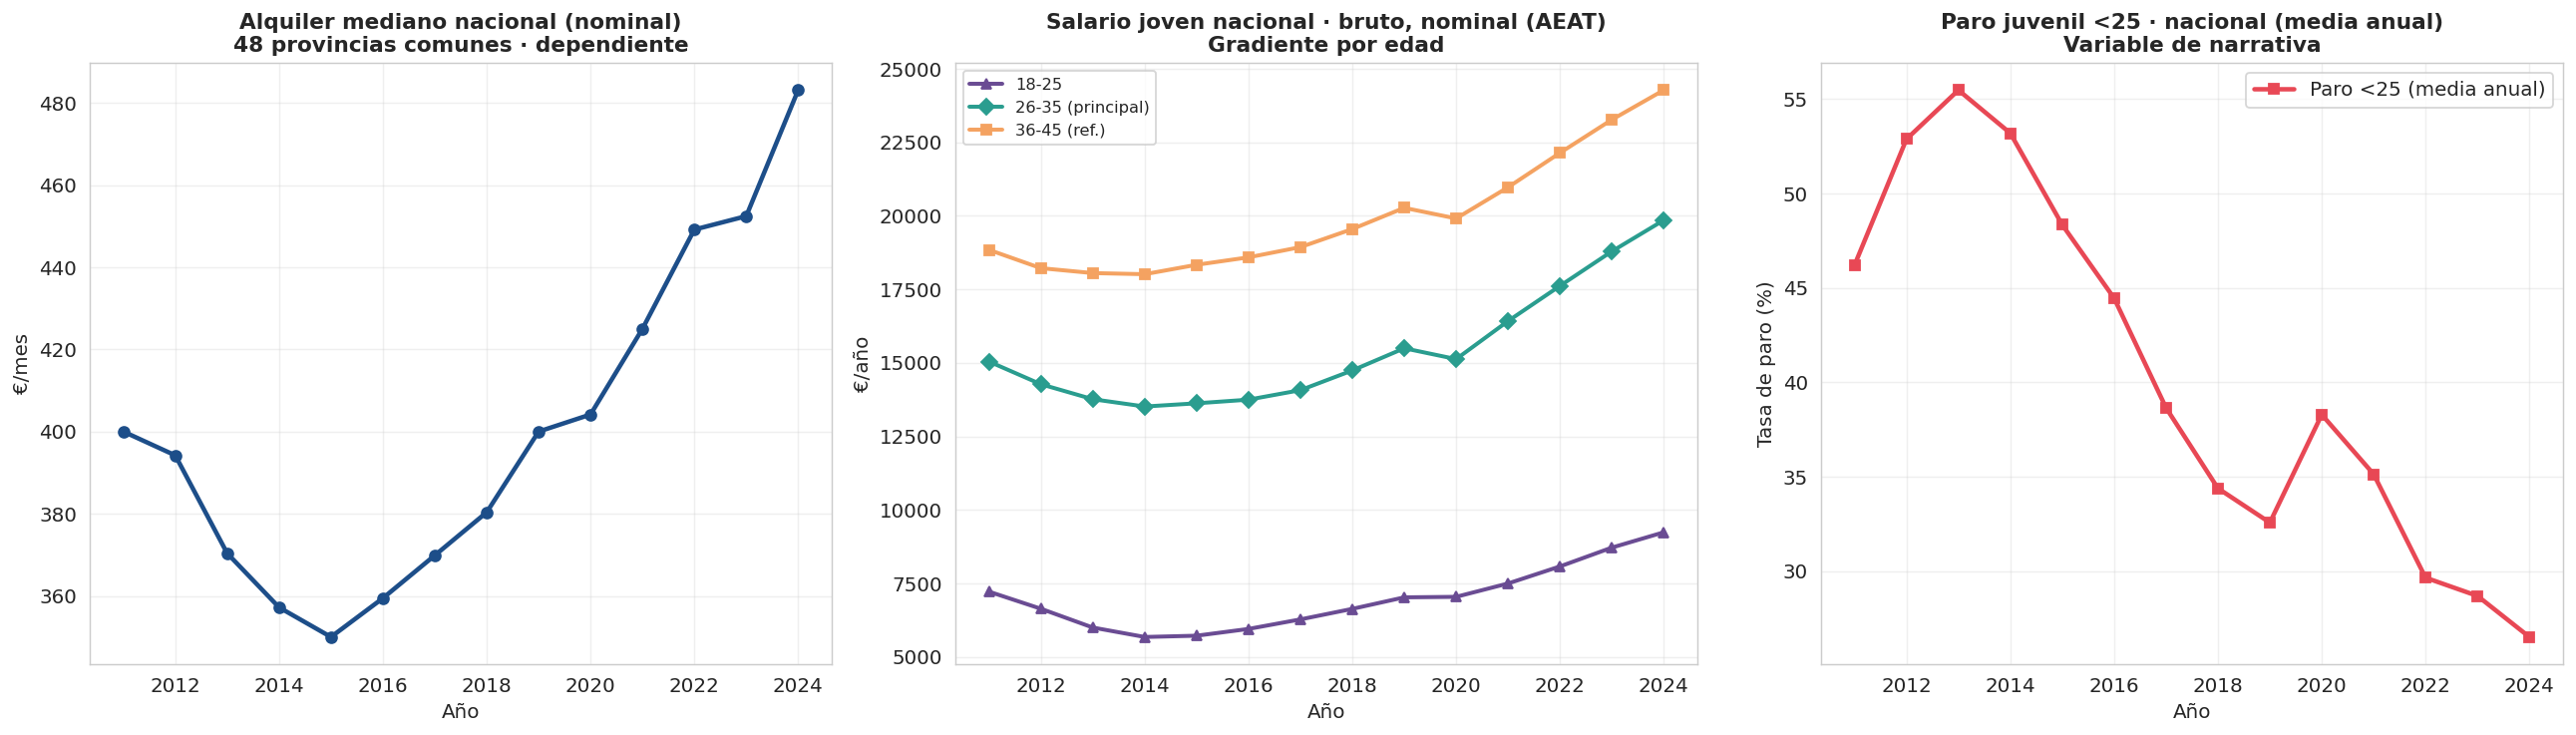

[✓] Visualización 'antes' — alquiler (SERPAVI), salario joven por banda (AEAT) y paro <25 (EPA).


In [12]:
# Panel 1: alquiler mediano nacional (SERPAVI, 48 comunes)  — dependiente
# Panel 2: salario joven nacional por banda AEAT (gradiente 18-25/26-35/36-45)
# Panel 3: paro juvenil <25 nacional (EPA edad)            — narrativa
# Series nacionales, nominales, sin transformar.
# ══════════════════════════════════════════════════════════════════
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5.8))

# Panel 1 — alquiler mediano nacional (mediana de las 48 comunes)
cols_alq = sorted([c for c in df_serpavi_raw.columns if c.startswith('ALQTBID12_M_VC_')])
_sc = df_serpavi_raw[df_serpavi_raw['CPRO'].isin(CPRO_COMUN)]
años_alq = [int('20'+c[-2:]) for c in cols_alq]
alq_med  = [_sc[c].median() for c in cols_alq]
ax1.plot(años_alq, alq_med, marker='o', lw=2.5, color=PALETA[0])
ax1.set_title('Alquiler mediano nacional (nominal)\n48 provincias comunes · dependiente', fontweight='bold', fontsize=12)
ax1.set_xlabel('Año'); ax1.set_ylabel('€/mes'); ax1.grid(alpha=0.3)

# Panel 2 — salario joven por banda (gradiente AEAT), media de comunes
ban = [('sal_18_25','18-25', PALETA[4],'^'),('sal_26_35','26-35 (principal)',PALETA[3],'D'),('sal_36_45','36-45 (ref.)',PALETA[2],'s')]
piv = df_aeat.groupby('año')[['sal_18_25','sal_26_35','sal_36_45']].mean()
for col,lab,color,mk in ban:
    ax2.plot(piv.index, piv[col], marker=mk, lw=2.2, color=color, label=lab)
ax2.set_title('Salario joven nacional · bruto, nominal (AEAT)\nGradiente por edad', fontweight='bold', fontsize=12)
ax2.set_xlabel('Año'); ax2.set_ylabel('€/año'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# Panel 3 — paro <25 nacional (EPA edad t=65334), media anual
g6=[str(v) for v in df_epa34_raw.iloc[6] if str(v).strip() not in ('nan','')]
t7=[str(v) for v in df_epa34_raw.iloc[7] if str(v).strip() not in ('nan','')]
ntq=len(t7)//len(g6) if g6 else 0
idx_m25=next((k for k,g in enumerate(g6) if 'Menores de 25' in g),None)
paro_anual={}
if idx_m25 is not None and ntq>0:
    base=1+idx_m25*ntq
    for j in range(ntq):
        tr=t7[j].strip()
        if len(tr)>=5 and tr[:4].isdigit() and 'T' in tr:
            try:
                a=int(tr[:4]); v=float(df_epa34_raw.iloc[9,base+j])
                if 0<v<100: paro_anual.setdefault(a,[]).append(v)
            except (ValueError,TypeError): pass
ap=sorted(a for a in paro_anual if ANIO_INICIO<=a<=ANIO_FIN)
pm=[np.mean(paro_anual[a]) for a in ap]
ax3.plot(ap, pm, marker='s', lw=2.5, color=PALETA[1], label='Paro <25 (media anual)')
ax3.set_title('Paro juvenil <25 · nacional (media anual)\nVariable de narrativa', fontweight='bold', fontsize=12)
ax3.set_xlabel('Año'); ax3.set_ylabel('Tasa de paro (%)'); ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig01_2-8_viz_inicial.png'), dpi=150, bbox_inches='tight'); plt.show()
print("[✓] Visualización 'antes' — alquiler (SERPAVI), salario joven por banda (AEAT) y paro <25 (EPA).")

*Figura 2. Series nacionales en bruto: alquiler mediano, salario joven y paro juvenil (2011–2024). Fuente: elaboración propia.*

---

## **Conclusiones de la Sección 2 — Origen y extracción de datos**

### **Resumen de las fuentes — siete principales y una complementaria**

Los valores de shape en bruto y de no nulos se obtienen leyendo cada archivo con `header=None` (`.shape` y `.notna().sum().sum()`), sin multiplicaciones manuales. El shape en bruto incluye la fila de cabecera; por ejemplo, el SERPAVI son 52 provincias + 1 cabecera = 53 filas.

*Tabla 2. Integridad de las fuentes en bruto (forma y valores no nulos). Fuente: elaboración propia.*

| # | Fuente | Shape raw / formato | No nulos (raw) | Rol |
|---|--------|---------------------|----------|-----|
| 1 | **SERPAVI** | 53 × 282 *(52 prov. + cabecera)* | 14.006 | Panel — alquiler (dependiente) |
| 2 | **AEAT** | 42 PDF → df_aeat | n/a ¹ | Panel — salario joven provincial |
| 3 | **EPA provincial** | 179 × 292 | 46.737 | Panel — paro total (control) |
| 4 | **IPC** | 314 × 1.173 | 329.645 | Panel — deflactor nacional |
| 5 | **SMI** | 61 × 10 | 486 | Panel — contexto |
| 6 | **EAES** | 1.978 × 4 | 7.484 | Validación del salario |
| 7 | **EPA edad** | 80 × 680 | 41.501 | Narrativa (paro juvenil) |
| 8 | **Padrón continuo** | 21.691 × 76 | 1.238.114 | Complementaria — impacto humano (no entra en el panel) |

> **Total valores no nulos en los 6 Excel: 439.859** + 2.016 en df_aeat — calculados directamente desde los archivos.
>
> ¹ En AEAT, las **2.016 no son "valores no nulos" de un Excel** sino **observaciones analíticas** (48 provincias × 14 años × 3 bandas de edad); no es una cifra comparable con el conteo en bruto de los archivos Excel.

---

### **Tres decisiones metodológicas transversales documentadas**

*① Fuentes tributarias para alquiler y salario.* El alquiler (SERPAVI, Modelo 100) y el salario (AEAT, Modelo 190) proceden de datos fiscales reales, no de oferta ni de encuesta. Comparten el universo de 48 provincias comunes, lo que da coherencia al numerador y al denominador del KPI.

*② Salario provincial directo, sin estimación sintética.* La AEAT aporta el salario por provincia y edad, de modo que el salario joven provincial es dato observado y no estimado por ratio. La EAES, limitada a CC.AA., queda como validación independiente del nivel y la tendencia.

*③ Universo = 48 provincias de régimen común; forales excluidos y documentados.* La AEAT excluye las 4 forales por su régimen fiscal y el SERPAVI no las cubre de forma homogénea. Se excluyen y se documentan, sin imputarlas (rellenar provincias que las fuentes excluyen sería fabricar datos). Ceuta y Melilla sí entran.

---

### **Lo que queda para la Sección 3 — Limpieza y Transformación**

| Pendiente | Técnica | Fuente |
|-----------|---------|--------|
| Conversión wide → long | `pd.melt()` | SERPAVI |
| Salario neto mensual (bruto → neto) | SS 6,35% + IRPF efectivo | AEAT |
| Agregación temporal trimestral → anual | media de trimestres | EPA provincial |
| Deflactación a euros constantes de 2020 | factor IPC (Índice nacional) | precios y salarios |
| Integración en panel | `merge` por CPRO y año | todas las del panel |
| Variables derivadas | tasa de esfuerzo, umbral 30%, gradiente por edad, D_2021 | panel |
| Visualizaciones antes/después | comparativa | panel |

El dataset final (48 provincias comunes × 14 años = 672 observaciones) se construye en la Sección 3.

---

## **3. Limpieza y transformación de datos**

Terminada la fase *Extract*, esta sección ejecuta la *T* del ETL: convertir las fuentes en un único panel analítico `provincia × año` (48 comunes × 14 años = 672 observaciones), limpio y con las variables derivadas que necesita el modelado. Cada transformación se documenta con su justificación y, cuando procede, con comparación antes / después.

*Tabla 3. Técnicas de transformación aplicadas. Fuente: elaboración propia.*

| # | Transformación | Técnica | Fuente |
|---|----------------|---------|--------|
| 3.1 | Reestructuración a formato tidy | `pd.melt` (wide→long) | SERPAVI |
| 3.2 | Agregación temporal trimestral→anual | media de trimestres | EPA provincial |
| 3.3 | Conversión salario bruto→neto mensual | cotización SS + IRPF efectivo | AEAT |
| 3.4 | Deflactor a euros constantes de 2020 | factor IPC (Índice nacional) | IPC |
| 3.5 | Integración en el panel | `merge` por CPRO + año | todas las del panel |
| 3.6 | Variables derivadas | tasa de esfuerzo, umbral 30%, gradiente edad, D_2021 | panel |
| 3.7 | Validación post-ETL + visualización antes/después | controles + gráficos | panel |

### **3.1 SERPAVI: formato wide → long (tidy)**

El SERPAVI llega en formato wide (una columna por variable-año). Para el panel se pasa a formato long/tidy, con una fila por `provincia-año`. Se conservan las seis variables de vivienda colectiva (VC) y se restringe al universo de 48 provincias comunes. Esa restricción deja fuera a los forales —sus 47 NaN salen del universo y no se imputan; el criterio se detalla en §3.9—, mientras que la vivienda unifamiliar, los totales mixtos y las tablas IPVA quedan descartados por relevancia o circularidad (detalle en §3.8).

In [13]:
# SERPAVI wide -> long
print("="*60); print("  3.1 · SERPAVI: wide -> long (48 provincias comunes)"); print("="*60)
VARS_SERPAVI = {'ALQTBID12_M_VC':'alquiler_mediano','ALQTBID12_25_VC':'alquiler_p25',
                'ALQTBID12_75_VC':'alquiler_p75','ALQM2_LV_M_VC':'alquiler_m2',
                'SLVM2_M_VC':'superficie_m2','BI_ALVHEPCO_TVC':'n_contratos'}
_frames=[]
for stub,nom in VARS_SERPAVI.items():
    cols=[c for c in df_serpavi_raw.columns if c.startswith(stub+'_')]
    lng=df_serpavi_raw[['CPRO']+cols].melt(id_vars='CPRO',var_name='v',value_name=nom)
    lng['año']=lng['v'].str[-2:].astype(int)+2000
    _frames.append(lng.drop(columns='v').set_index(['CPRO','año']))
df_serpavi=pd.concat(_frames,axis=1).reset_index().rename(columns={'CPRO':'cpro'})
df_serpavi['cpro']=df_serpavi['cpro'].astype(int)
df_serpavi=df_serpavi[(df_serpavi['cpro'].isin(CPRO_COMUN)) &
                      (df_serpavi['año'].between(ANIO_INICIO,ANIO_FIN))].sort_values(['cpro','año']).reset_index(drop=True)
print(f"\n  ANTES (wide):   {df_serpavi_raw.shape[0]} x {df_serpavi_raw.shape[1]}")
print(f"  DESPUÉS (long): {df_serpavi.shape[0]} x {df_serpavi.shape[1]}  "
      f"({df_serpavi.cpro.nunique()} prov × {df_serpavi.año.nunique()} años)")
print(f"  NaN en alquiler_mediano (comunes): {df_serpavi['alquiler_mediano'].isna().sum()}")
print("\n", df_serpavi.head(4).to_string(index=False))
print("\n  [✓] df_serpavi (long, 48 comunes) listo.")

  3.1 · SERPAVI: wide -> long (48 provincias comunes)

  ANTES (wide):   52 x 282
  DESPUÉS (long): 672 x 8  (48 prov × 14 años)
  NaN en alquiler_mediano (comunes): 0

  cpro  año  alquiler_mediano  alquiler_p25  alquiler_p75  alquiler_m2  superficie_m2  n_contratos
    2 2011            400.00        283.33        500.87         4.42          96.00      6895.00
    2 2012            398.81        282.94        500.00         4.30          96.00      6924.00
    2 2013            374.59        268.15        474.43         4.11          96.00      7076.00
    2 2014            359.89        269.24        450.00         4.03          96.00      7498.00

  [✓] df_serpavi (long, 48 comunes) listo.


### **3.2 EPA provincial: trimestral → anual**

La EPA publica trimestres y el panel es anual, así que se calcula la media anual de la tasa de paro (bloque Ambos sexos) por provincia y se restringe a las 48 comunes. La media anual, además, suaviza la ruptura de base poblacional de 2021, que más adelante se controla con la dummy `D_2021`.

In [14]:
# EPA provincial -> anual
import re
print("="*60); print("  3.2 · EPA provincial: paro total trimestral -> media anual"); print("="*60)
_f6=[str(v) for v in df_epa49_raw.iloc[6] if str(v).strip() not in ('nan','')]
_f7=[str(v) for v in df_epa49_raw.iloc[7] if str(v).strip() not in ('nan','')]
_nt=len(_f7)//len(_f6)
_ipar=[k for k,v in enumerate(_f6) if 'paro' in v.lower()][0]; _base=1+_ipar*_nt
_rows=[]
for i in range(9,62):
    nm=str(df_epa49_raw.iloc[i,0]).strip(); m=re.match(r'^(\d{1,2})\s',nm)
    if not m: continue
    cp=int(m.group(1)); d={}
    for j,q in enumerate(_f7[:_nt]):
        if re.match(r'^\d{4}T\d',q):
            y=int(q[:4])
            if ANIO_INICIO<=y<=ANIO_FIN:
                try: d.setdefault(y,[]).append(float(df_epa49_raw.iloc[i,_base+j]))
                except: pass
    for y,v in d.items(): _rows.append({'cpro':cp,'año':y,'paro_total':round(sum(v)/len(v),2)})
df_paro=pd.DataFrame(_rows)
df_paro=df_paro[df_paro['cpro'].isin(CPRO_COMUN)].reset_index(drop=True)
print(f"\n  Trimestres por indicador: {_nt} · indicador usado: 'Tasa de paro' (Ambos sexos)")
print(f"  Filas: {len(df_paro)} ({df_paro.cpro.nunique()} prov × {df_paro.año.nunique()} años) · NaN: {df_paro['paro_total'].isna().sum()}")
print("  Madrid:", df_paro[(df_paro.cpro==28)&(df_paro.año.isin([2011,2024]))].set_index('año')['paro_total'].to_dict())
print("\n  [✓] df_paro (anual, 48 comunes) listo.")

  3.2 · EPA provincial: paro total trimestral -> media anual

  Trimestres por indicador: 97 · indicador usado: 'Tasa de paro' (Ambos sexos)
  Filas: 672 (48 prov × 14 años) · NaN: 0
  Madrid: {2024: 8.97, 2011: 16.34}

  [✓] df_paro (anual, 48 comunes) listo.


### **3.3 AEAT: salario bruto → neto mensual**

La tasa de esfuerzo se define sobre renta disponible, por lo que el salario bruto de la AEAT se convierte a neto:

`neto = bruto − cotización SS del trabajador (6,35%) − IRPF`

El IRPF se calcula con la escala general progresiva y el mínimo personal, descontando un gasto deducible general. Es la vía rigurosa para el umbral del 30% y, frente a un factor fijo, respeta la progresividad, algo clave al comparar las rentas bajas de 18-25 con las de 36-45. Los supuestos quedan documentados: declarante individual, escala general estatal como aproximación nacional y sin circunstancias personales añadidas. Se reportan también el bruto y un factor fijo como análisis de sensibilidad. La banda principal del KPI es la de 26-35; se calcula el neto de las tres bandas y el agregado 18-34 (ponderado por nº de asalariados, para la comparabilidad con Eurostat).

Conviene reconocer la limitación: la conversión bruto→neto es una aproximación homogénea para todo el territorio y período; aplica la cotización del trabajador, la escala estatal progresiva y el mínimo personal, pero no reproduce deducciones autonómicas ni circunstancias familiares concretas. No pretende calcular una nómina exacta, sino una medida comparable de renta disponible para el KPI, y por eso se acompaña del análisis de sensibilidad (bruto de la AEAT y nivel de la EAES).

In [15]:
# AEAT bruto -> neto mensual
print("="*60); print("  3.3 · Salario bruto -> neto mensual (SS + IRPF)"); print("="*60)
TIPO_SS = 0.0635           # cotización del trabajador (contingencias+desempleo+formación)
GASTO_DEDUCIBLE = 2000.0   # gasto deducible general (rendimientos del trabajo)
MINIMO_PERSONAL = 5550.0
# Escala general IRPF (estatal+autonómica de referencia) como (límite inferior, tipo)
TRAMOS_IRPF = [(0,0.19),(12450,0.24),(20200,0.30),(35200,0.37),(60000,0.45),(300000,0.47)]

def _cuota_irpf(base):
    c=0.0
    for k,(lim,t) in enumerate(TRAMOS_IRPF):
        sup = TRAMOS_IRPF[k+1][0] if k+1<len(TRAMOS_IRPF) else float('inf')
        if base>lim: c += (min(base,sup)-lim)*t
        else: break
    return c

def bruto_a_neto_anual(bruto):
    ss = bruto*TIPO_SS
    rend_neto = max(0.0, bruto - ss - GASTO_DEDUCIBLE)
    irpf = max(0.0, _cuota_irpf(rend_neto) - _cuota_irpf(MINIMO_PERSONAL))
    return bruto - ss - irpf

# Verificación contra un punto conocido
_chk = bruto_a_neto_anual(20000)
print(f"\n  Verificación: 20.000 € brutos -> {_chk:,.0f} € netos/año "
      f"(tipo efectivo {100*(1-_chk/20000):.1f} %)  [esperado ~16-17k]")

df_salario = df_aeat.copy()
for b in ['18_25','26_35','36_45']:
    df_salario[f'neto_anual_{b}'] = df_salario[f'sal_{b}'].apply(bruto_a_neto_anual)
    df_salario[f'neto_mes_{b}']   = df_salario[f'neto_anual_{b}']/12
# Agregado 18-34 (ponderado por nº de asalariados de 18-25 y 26-35)
_w = df_salario['n_18_25']+df_salario['n_26_35']
df_salario['neto_mes_18_34'] = ((df_salario['neto_mes_18_25']*df_salario['n_18_25']
                                + df_salario['neto_mes_26_35']*df_salario['n_26_35'])/_w)
print(f"\n  Neto mensual medio provincial 2024 (€):")
g=df_salario[df_salario.año==2024][['neto_mes_18_25','neto_mes_26_35','neto_mes_36_45','neto_mes_18_34']].mean().round(0)
print(f"    18-25:{g['neto_mes_18_25']:.0f}  26-35:{g['neto_mes_26_35']:.0f}  36-45:{g['neto_mes_36_45']:.0f}  18-34(pond):{g['neto_mes_18_34']:.0f}")
print(f"  Filas: {len(df_salario)} · NaN neto 26-35: {df_salario['neto_mes_26_35'].isna().sum()}")
print("\n  [✓] df_salario (neto mensual por banda) listo. Banda KPI: 26-35.")

  3.3 · Salario bruto -> neto mensual (SS + IRPF)

  Verificación: 20.000 € brutos -> 16,392 € netos/año (tipo efectivo 18.0 %)  [esperado ~16-17k]

  Neto mensual medio provincial 2024 (€):
    18-25:703  26-35:1357  36-45:1613  18-34(pond):1111
  Filas: 672 · NaN neto 26-35: 0

  [✓] df_salario (neto mensual por banda) listo. Banda KPI: 26-35.


### **3.4 IPC: factor de deflactación a euros de 2020**

Se construye el factor `IPC_2020 / IPC_año` (Índice general nacional, media anual) para expresar alquiler y salario en euros constantes de 2020. Conviene recordar que el KPI (alquiler/salario del mismo año) es independiente del deflactor; este solo sirve para las series reales del EDA. El Grupo 04 del IPC y las medidas de variación se descartan por circularidad con el alquiler (detalle en §3.8).

In [16]:
# Deflactor IPC
print("="*60); print("  3.4 · Factor de deflactación a euros constantes de 2020"); print("="*60)
ipc_2020 = ipc_anual.get(ANIO_BASE_IPC)
df_defl = pd.DataFrame({'año': ipc_anual.index, 'ipc_indice': ipc_anual.values})
df_defl = df_defl[df_defl['año'].between(ANIO_INICIO,ANIO_FIN)].copy()
df_defl['factor_2020'] = ipc_2020/df_defl['ipc_indice']
print(f"\n  IPC_2020 = {ipc_2020:.3f}")
print(df_defl.assign(factor_2020=df_defl.factor_2020.round(4)).to_string(index=False))
print(f"\n  Registros tras esta etapa: {len(df_defl)} años (deflactor nacional {int(df_defl['año'].min())}–{int(df_defl['año'].max())})")
print("\n  [✓] df_defl listo (factor de deflactación por año).")

  3.4 · Factor de deflactación a euros constantes de 2020

  IPC_2020 = 81.915
 año  ipc_indice  factor_2020
2011       76.43         1.07
2012       78.30         1.05
2013       79.40         1.03
2014       79.28         1.03
2015       78.88         1.04
2016       78.72         1.04
2017       80.26         1.02
2018       81.61         1.00
2019       82.18         1.00
2020       81.91         1.00
2021       84.45         0.97
2022       91.53         0.89
2023       94.77         0.86
2024       97.40         0.84

  Registros tras esta etapa: 14 años (deflactor nacional 2011–2024)

  [✓] df_defl listo (factor de deflactación por año).


### **3.5 Integración en el panel `provincia × año`**

Se unen por CPRO y año las fuentes del panel: alquiler (SERPAVI), salario neto (AEAT), paro total (EPA), factor IPC (nacional) y SMI (nacional), y se añaden las etiquetas geográficas de `df_geo`. El resultado esperado son 48 × 14 = 672 filas sin NaN en las variables núcleo.

In [17]:
# Merge -> panel
print("="*60); print("  3.5 · Integración en el panel provincia × año"); print("="*60)
panel = (df_serpavi[['cpro','año','alquiler_mediano','alquiler_m2','superficie_m2','n_contratos']]
         .merge(df_salario[['cpro','año','neto_mes_18_25','neto_mes_26_35','neto_mes_36_45','neto_mes_18_34',
                            'sal_26_35']], on=['cpro','año'], how='left')
         .merge(df_paro, on=['cpro','año'], how='left')
         .merge(df_defl[['año','factor_2020']], on='año', how='left')
         .merge(df_smi[['año','smi_mes']], on='año', how='left')
         .merge(df_geo[['cpro','provincia','ccaa']], on='cpro', how='left'))
panel = panel.sort_values(['cpro','año']).reset_index(drop=True)
print(f"\n  Panel: {panel.shape[0]} filas × {panel.shape[1]} columnas "
      f"({panel.cpro.nunique()} prov × {panel.año.nunique()} años)")
_core=['alquiler_mediano','neto_mes_26_35','paro_total','factor_2020','smi_mes']
print(f"  NaN en variables núcleo: {panel[_core].isna().sum().to_dict()}")
print("\n  [✓] panel integrado (672 obs.) listo.")

  3.5 · Integración en el panel provincia × año

  Panel: 672 filas × 16 columnas (48 prov × 14 años)
  NaN en variables núcleo: {'alquiler_mediano': 0, 'neto_mes_26_35': 0, 'paro_total': 0, 'factor_2020': 0, 'smi_mes': 0}

  [✓] panel integrado (672 obs.) listo.


### **3.6 Variables derivadas**

Sobre el panel se construyen la tasa de esfuerzo (el KPI), igual a alquiler mensual / salario neto mensual × 100, y su bandera de sobrecarga (>30%); las series en euros reales de 2020; el gradiente por edad (esfuerzo de las bandas 18-25 y 36-45); y la dummy estructural `D_2021`, que recoge la ruptura de base poblacional de la EPA.

In [18]:
# Variables derivadas
print("="*60); print("  3.6 · Variables derivadas (KPI tasa de esfuerzo y gradiente)"); print("="*60)
panel['tasa_esfuerzo']      = (panel['alquiler_mediano']/panel['neto_mes_26_35']*100).round(2)   # KPI principal (26-35)
panel['tasa_esfuerzo_18_25']= (panel['alquiler_mediano']/panel['neto_mes_18_25']*100).round(2)
panel['tasa_esfuerzo_36_45']= (panel['alquiler_mediano']/panel['neto_mes_36_45']*100).round(2)
panel['tasa_esfuerzo_18_34']= (panel['alquiler_mediano']/panel['neto_mes_18_34']*100).round(2)
panel['sobre_30']           = (panel['tasa_esfuerzo']>30).astype(int)
panel['alquiler_real']      = (panel['alquiler_mediano']*panel['factor_2020']).round(2)
panel['salario_real_26_35'] = (panel['neto_mes_26_35']*panel['factor_2020']).round(2)
panel['D_2021']             = (panel['año']>=2021).astype(int)
print(f"\n  Tasa de esfuerzo (26-35) — resumen:")
print(panel['tasa_esfuerzo'].describe().round(1).to_string())
print(f"\n  % provincias-año por encima del 30%: {100*panel['sobre_30'].mean():.1f}%")
print(f"\n  Gradiente por edad (media 2024):")
g=panel[panel.año==2024][['tasa_esfuerzo_18_25','tasa_esfuerzo','tasa_esfuerzo_36_45']].mean().round(1)
print(f"    18-25: {g['tasa_esfuerzo_18_25']}%   26-35: {g['tasa_esfuerzo']}%   36-45: {g['tasa_esfuerzo_36_45']}%")
print(f"\n  Ejemplo (2024): "+ ", ".join(
    f"{r.provincia}={r.tasa_esfuerzo}%" for _,r in panel[(panel.año==2024)&(panel.cpro.isin([28,8,4,46]))].iterrows()))
print(f"\n  Registros tras esta etapa: {panel.shape[0]} filas × {panel.shape[1]} columnas")
print("\n  [✓] Variables derivadas creadas.")

  3.6 · Variables derivadas (KPI tasa de esfuerzo y gradiente)

  Tasa de esfuerzo (26-35) — resumen:
count   672.00
mean     38.40
std       6.20
min      27.10
25%      33.80
50%      37.20
75%      42.40
max      58.60

  % provincias-año por encima del 30%: 95.8%

  Gradiente por edad (media 2024):
    18-25: 71.6%   26-35: 37.1%   36-45: 31.2%

  Ejemplo (2024): Almería=39.78%, Barcelona=44.68%, Madrid=46.7%, Valencia/València=39.82%

  Registros tras esta etapa: 672 filas × 24 columnas

  [✓] Variables derivadas creadas.


### **3.6b Análisis de sensibilidad del KPI**

El salario de la AEAT (masa / perceptores) es una cota inferior del salario a tiempo completo, de modo que la tasa de esfuerzo que resulta es una cota superior. Para comprobar que la conclusión no depende de esa elección, el KPI se recalcula con tres medidas de salario: (a) neto de la AEAT, que es la principal; (b) bruto de la AEAT; y (c) nivel de la EAES, reescalando el bruto de la AEAT por el ratio nacional EAES₍25-34₎/AEAT₍26-35₎ y pasándolo después a neto. La dirección del resultado —un esfuerzo elevado, por encima o cerca del 30%— se mantiene en los tres casos.

*Tabla 4. Sensibilidad de la tasa de esfuerzo de la banda de 26 a 35 años según la medida del salario empleada (media nacional, 2024). Fuente: elaboración propia.*

In [19]:
print("="*60); print("  3.6b · Sensibilidad de la tasa de esfuerzo al salario"); print("="*60)
# Ratio nacional EAES(25-34) / AEAT(26-35) por año (sin hardcode)
_eaes_nac = (df_eaes[(df_eaes.grupo_edad=='De 25 a 34 años')&(df_eaes.ccaa=='Total Nacional')]
             .set_index('año')['sal_anual_bruto'])
# AEAT nacional = media PONDERADA por nº de asalariados (comparable al agregado nacional de EAES)
_num = (df_aeat['sal_26_35']*df_aeat['n_26_35']).groupby(df_aeat['año']).sum()
_den = df_aeat.groupby('año')['n_26_35'].sum()
_aeat_nac = _num/_den
_ratio = (_eaes_nac/_aeat_nac).reindex(range(ANIO_INICIO,ANIO_FIN+1)).ffill().bfill()
print(f"\n  Ratio EAES/AEAT (medio del período): {_ratio.mean():.3f}")

_p = panel.copy()
_p['esf_neto']  = _p['tasa_esfuerzo']                                            # (a) principal
_p['esf_bruto'] = (_p['alquiler_mediano']/(_p['sal_26_35']/12)*100)              # (b) bruto
_p['_bruto_eaes']= _p['sal_26_35']*_p['año'].map(_ratio)
_p['esf_eaes']  = (_p['alquiler_mediano']/(_p['_bruto_eaes'].apply(bruto_a_neto_anual)/12)*100)  # (c) nivel EAES
print(f"\n  Tasa de esfuerzo media nacional 2024 (%) y % de provincia-año > 30%:")
for col,lab in [('esf_neto','(a) neto AEAT [principal]'),('esf_bruto','(b) bruto AEAT'),('esf_eaes','(c) nivel EAES')]:
    m24=_p[_p.año==2024][col].mean(); pct=100*(_p[col]>30).mean()
    print(f"    {lab:<28} media 2024 = {m24:5.1f}%   ·   >30%: {pct:5.1f}% de obs.")
print("\n  [✓] Conclusión robusta: la sobrecarga (cerca/por encima del 30%) se mantiene en las 3 medidas.")

  3.6b · Sensibilidad de la tasa de esfuerzo al salario

  Ratio EAES/AEAT (medio del período): 1.219

  Tasa de esfuerzo media nacional 2024 (%) y % de provincia-año > 30%:
    (a) neto AEAT [principal]    media 2024 =  37.1%   ·   >30%:  95.8% de obs.
    (b) bruto AEAT               media 2024 =  30.5%   ·   >30%:  61.8% de obs.
    (c) nivel EAES               media 2024 =  32.5%   ·   >30%:  62.5% de obs.

  [✓] Conclusión robusta: la sobrecarga (cerca/por encima del 30%) se mantiene en las 3 medidas.


### **3.6c Ingeniería de variables: dinámica temporal (lags y variaciones)**

Para enriquecer el modelado se añaden variables de dinámica temporal: el valor del año anterior (*lag-1*) de alquiler, salario, paro y tasa de esfuerzo, y la variación interanual (%) de alquiler y salario. Capturan la inercia y el momentum de cada serie, útiles tanto para los modelos de determinantes (regresión regularizada, Random Forest y Gradient Boosting) como en forma de regresores del modelo de series temporales (ARIMA). Por su propia construcción, los lags y las variaciones presentan NaN en el primer año (2011) de cada provincia: es lo esperado, porque no hay año previo, y afecta solo a esas columnas, no al núcleo, que sigue sin NaN. Una advertencia sobre la fuga de información (*leakage*): al predecir el alquiler no deben usarse como predictores variables derivadas del propio alquiler (la tasa de esfuerzo o el alquiler_m2), algo que se respeta en la fase de modelado. El criterio de faltantes está consolidado en §3.9.

In [20]:
print("="*60); print("  3.6c · Variables de dinámica temporal (lags y variaciones)"); print("="*60)
panel = panel.sort_values(['cpro','año']).reset_index(drop=True)
for v in ['alquiler_mediano','neto_mes_26_35','paro_total','tasa_esfuerzo']:
    panel[f'{v}_lag1'] = panel.groupby('cpro')[v].shift(1)
panel['var_alquiler_pct'] = panel.groupby('cpro')['alquiler_mediano'].pct_change(fill_method=None)*100
panel['var_salario_pct']  = panel.groupby('cpro')['neto_mes_26_35'].pct_change(fill_method=None)*100
nuevas = [c for c in panel.columns if c.endswith('_lag1') or c.startswith('var_')]
print(f"\n  Variables añadidas: {nuevas}")
print(f"  NaN por columna nueva (esperado 48 = primer año de cada provincia):")
print(panel[nuevas].isna().sum().to_string())
print(f"\n  Núcleo intacto (0 NaN): "
      f"{int(panel[['alquiler_mediano','neto_mes_26_35','paro_total','tasa_esfuerzo']].isna().sum().sum())==0}")
print(f"  Panel: {panel.shape[0]} filas × {panel.shape[1]} columnas")
print("\n  [✓] Variables de dinámica temporal añadidas (lags + variaciones).")

  3.6c · Variables de dinámica temporal (lags y variaciones)

  Variables añadidas: ['alquiler_mediano_lag1', 'neto_mes_26_35_lag1', 'paro_total_lag1', 'tasa_esfuerzo_lag1', 'var_alquiler_pct', 'var_salario_pct']
  NaN por columna nueva (esperado 48 = primer año de cada provincia):
alquiler_mediano_lag1    48
neto_mes_26_35_lag1      48
paro_total_lag1          48
tasa_esfuerzo_lag1       48
var_alquiler_pct         48
var_salario_pct          48

  Núcleo intacto (0 NaN): True
  Panel: 672 filas × 30 columnas

  [✓] Variables de dinámica temporal añadidas (lags + variaciones).


### **3.7 Validación post-transformación y visualización antes / después**

Se valida el panel final (dimensiones, claves, nulos y rangos) y se muestra la comparación antes/después que pide la rúbrica: la estructura wide→long y la evolución de la tasa de esfuerzo frente al umbral del 30%.

  3.7 · Validación del panel y visualización antes/después

  ✓ 672 filas · claves únicas · 0 NaN núcleo · rangos plausibles


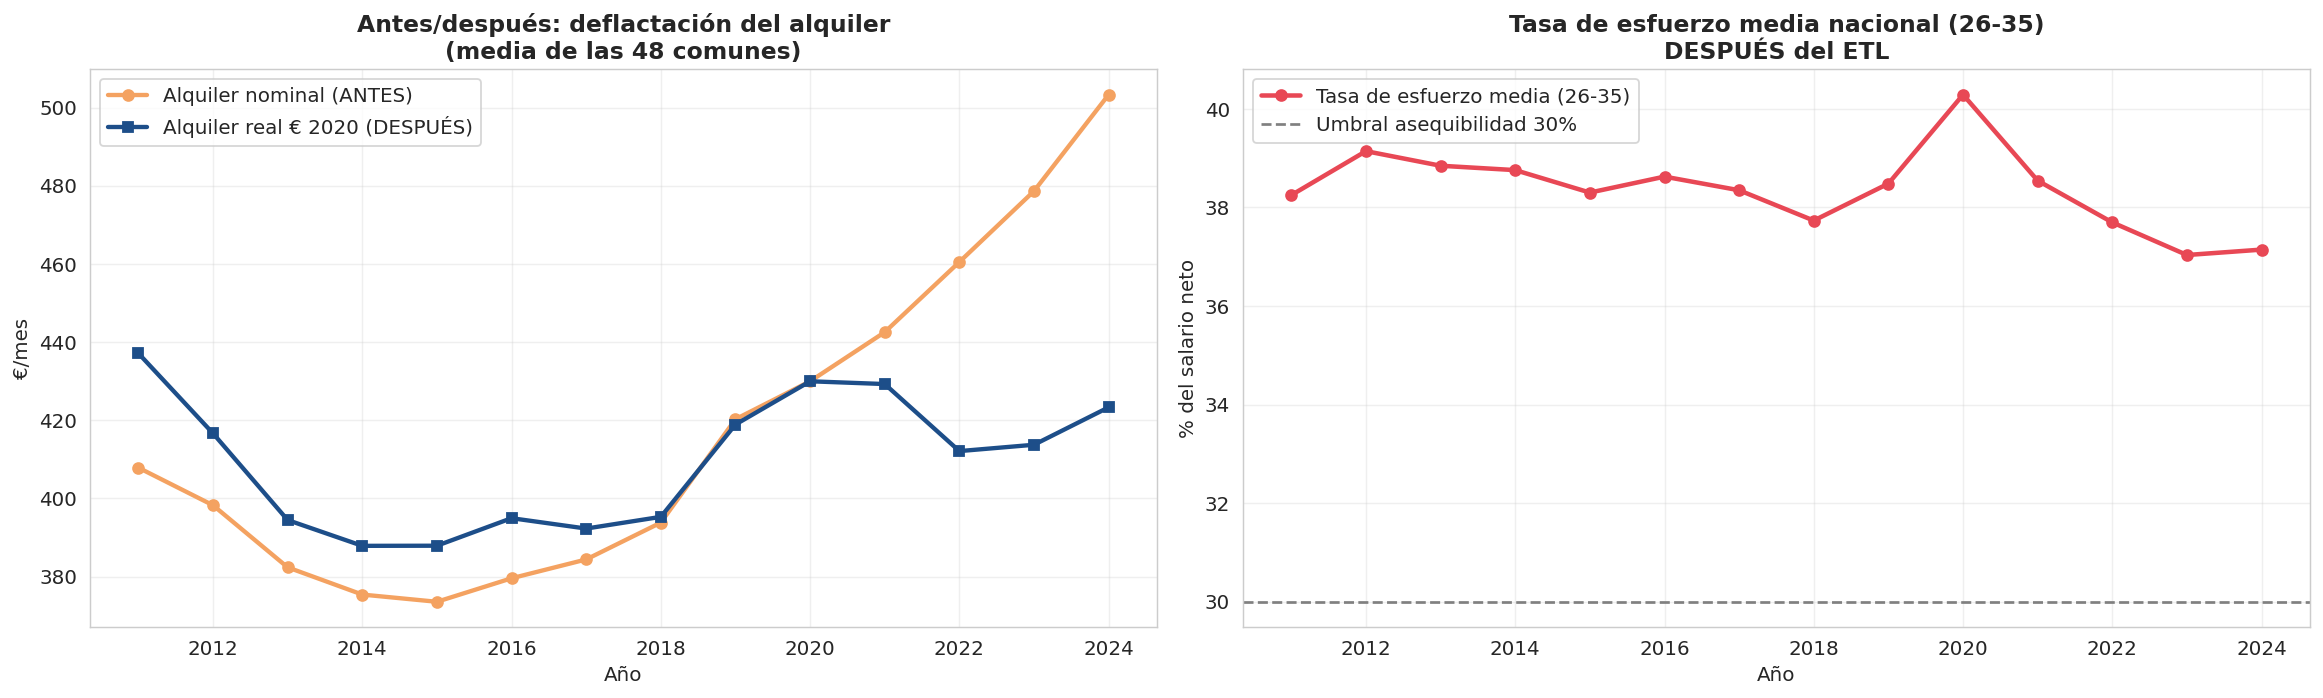


  [✓] Validación y visualización antes/después completadas.


In [21]:
# Validación + viz antes/después
print("="*60); print("  3.7 · Validación del panel y visualización antes/después"); print("="*60)
assert panel.shape[0]==len(CPRO_COMUN)*(ANIO_FIN-ANIO_INICIO+1), "Nº de filas inesperado"
assert not panel.duplicated(['cpro','año']).any(), "Claves duplicadas"
assert panel[['alquiler_mediano','neto_mes_26_35','paro_total','tasa_esfuerzo']].isna().sum().sum()==0, "NaN en núcleo"
assert panel['tasa_esfuerzo'].between(0,150).all(), "Tasa de esfuerzo fuera de rango plausible"
print("\n  ✓ 672 filas · claves únicas · 0 NaN núcleo · rangos plausibles")

import matplotlib.pyplot as plt
fig,(axA,axB)=plt.subplots(1,2,figsize=(18,5.5))
# ANTES/DESPUÉS de una transformación: alquiler NOMINAL vs REAL (deflactación)
nom=panel.groupby('año')['alquiler_mediano'].mean()
rea=panel.groupby('año')['alquiler_real'].mean()
axA.plot(nom.index,nom.values,marker='o',lw=2.4,color=PALETA[2],label='Alquiler nominal (ANTES)')
axA.plot(rea.index,rea.values,marker='s',lw=2.4,color=PALETA[0],label='Alquiler real € 2020 (DESPUÉS)')
axA.set_title('Antes/después: deflactación del alquiler\n(media de las 48 comunes)',fontweight='bold')
axA.set_xlabel('Año'); axA.set_ylabel('€/mes'); axA.legend(); axA.grid(alpha=0.3)
# KPI: tasa de esfuerzo media vs umbral 30%
te=panel.groupby('año')['tasa_esfuerzo'].mean()
axB.plot(te.index,te.values,marker='o',lw=2.5,color=PALETA[1],label='Tasa de esfuerzo media (26-35)')
axB.axhline(30,ls='--',color='gray',label='Umbral asequibilidad 30%')
axB.set_title('Tasa de esfuerzo media nacional (26-35)\nDESPUÉS del ETL',fontweight='bold')
axB.set_xlabel('Año'); axB.set_ylabel('% del salario neto'); axB.legend(); axB.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig02_3-7_antes_despues.png'), dpi=150, bbox_inches='tight'); plt.show()
print("\n  [✓] Validación y visualización antes/después completadas.")

*Figura 3. Antes y después de la transformación: deflactación del alquiler y tasa de esfuerzo tras el ETL. Fuente: elaboración propia.*

### **3.8 Proceso de eliminación de variables (explicación completa)**

Cada descarte responde a una de dos razones: falta de relevancia o riesgo de fuga/circularidad con la variable dependiente.

- *Tablas IPVA (t=59058/59059):* se descartan del panel por ser índices del propio alquiler, que predecirían la dependiente de forma circular. No se usan en el dataset final.
- *SERPAVI:* se conservan las 6 variables de vivienda colectiva (VC) y se descartan la vivienda unifamiliar y los totales mixtos, ya que la población joven reside en VC. En el panel núcleo entran `alquiler_mediano` (dependiente), `alquiler_m2`, `superficie_m2` y `n_contratos`; los percentiles `p25/p75` quedan disponibles para el EDA, fuera del núcleo.
- *IPC:* solo la medida Índice general nacional (el deflactor); se descartan las tres medidas de variación y el Grupo 04, por circularidad con el alquiler.
- *EPA:* del bloque por sexo se usa Ambos sexos y el indicador Tasa de paro; se descartan actividad y empleo.

### **3.9 Tratamiento de valores faltantes (decisión por caso)**

El panel núcleo no contiene ningún NaN (verificado con `assert`). Los faltantes se resuelven caso por caso, bajo un principio rector: no fabricar datos.

- *Provincias forales (47 NaN en SERPAVI, antes de restringir):* exclusión documentada del universo, no imputación. La AEAT no las cubre por su régimen fiscal y el SERPAVI tampoco de forma homogénea; imputar provincias que las fuentes tributarias no recogen sería inventar datos.
- *Lags y variaciones interanuales (NaN en 2011):* se conservan como NaN esperados, porque el primer año de cada provincia no tiene año previo. No es un fallo de calidad, sino una consecuencia mecánica de construir rezagos, y afecta solo a esas columnas, no al núcleo.
- *EAES de baja fiabilidad muestral (marcada por el INE):* se conserva en valor absoluto con la bandera `baja_fiabilidad`, sin descartar ni imputar, para preservar la trazabilidad.
- *Población 2023-2024:* no se estima ni se extrapola (la serie del Padrón llega a 2022); se usa el último año disponible (2022) y se documenta.

¿Por qué no se interpola ni se imputa? Las series de las 48 provincias comunes tienen cobertura completa 2011-2024 sin huecos internos, así que la interpolación no procede: no hay valores intermedios que rellenar. Donde sí hay ausencias —forales, lags de 2011, población 2023-24— imputarlas introduciría datos inexistentes; por eso la decisión es de exclusión o conservación documentada, más rigurosa que la imputación artificial.

En conjunto, las técnicas de transformación aplicadas cubren el cambio de valores (bruto→neto, deflactación), el aumento de datos (variables derivadas: tasa de esfuerzo, gradiente por edad, agregado 18-34 ponderado, lags y variaciones) y la reestructuración (wide→long, trimestral→anual).

---

### **Conclusiones de la Sección 3 — Limpieza y transformación**

El panel analítico final tiene 48 provincias comunes × 14 años = 672 observaciones, sin valores faltantes en las variables núcleo. Las transformaciones aplicadas —wide→long (SERPAVI), agregación trimestral→anual (EPA), conversión bruto→neto con SS e IRPF progresivo (AEAT), deflactación a euros de 2020 (IPC) e integración por CPRO— producen un dataset *tidy* listo para el análisis exploratorio y el modelado.

Como hallazgo preliminar, a confirmar en el EDA, la tasa de esfuerzo media de la banda 26-35 se sitúa por encima del umbral del 30% en buena parte del período y de las provincias, y el gradiente por edad apunta a una carga aún mayor para el grupo 18-25. El análisis formal —dispersión geográfica, series temporales y estacionariedad— se desarrolla en la Sección 4.

---

## **4. Análisis exploratorio (EDA)**

Con el panel ya construido (48 provincias comunes × 14 años), el EDA describe las variables, examina su distribución y sus outliers, su variación geográfica y temporal, las correlaciones entre ellas y la estacionariedad de las series (test ADF), preparando así el modelado posterior. Cada bloque enlaza con la pregunta de investigación: magnitud, variación geográfica y temporal, y proyección del desequilibrio alquiler–salario joven.

### **4.1 Estadística descriptiva**

Estadísticos de posición y dispersión de las variables del panel, junto con el coeficiente de asimetría (*skew*). La asimetría positiva del alquiler respalda el uso de la mediana, y no la media, como estadístico central del SERPAVI.

*Tabla 5. Estadísticos descriptivos de las principales variables del panel. Fuente: elaboración propia.*

In [22]:
# Estadística descriptiva
print("="*60); print("  4.1 · Estadística descriptiva del panel"); print("="*60)
num = ['alquiler_mediano','alquiler_real','neto_mes_26_35','paro_total','tasa_esfuerzo','smi_mes']
desc = panel[num].describe().T[['mean','std','min','25%','50%','75%','max']].round(2)
desc['skew'] = panel[num].skew().round(2)
print("\n", desc.to_string())
print(f"\n  Lectura:")
print(f"  · tasa_esfuerzo: media {panel['tasa_esfuerzo'].mean():.1f}% · mediana {panel['tasa_esfuerzo'].median():.1f}% "
      f"· rango {panel['tasa_esfuerzo'].min():.1f}–{panel['tasa_esfuerzo'].max():.1f}%")
print(f"  · alquiler_mediano: asimetría {panel['alquiler_mediano'].skew():.2f} (>0 → cola derecha; "
      f"se usa la MEDIANA como central, coherente con el SERPAVI).")
print(f"  · % de observaciones con esfuerzo > 30%: {100*panel['sobre_30'].mean():.1f}%")
print("\n  [✓] Descriptivos calculados.")

  4.1 · Estadística descriptiva del panel

                     mean    std    min    25%     50%     75%     max  skew
alquiler_mediano  416.47  86.57 300.00 350.00  400.00  450.00  800.00  1.43
alquiler_real     409.57  76.65 301.12 360.89  395.34  430.10  700.00  1.45
neto_mes_26_35   1090.86 167.82 724.24 971.92 1079.63 1193.94 1713.13  0.47
paro_total         18.73   7.43   6.34  12.64   17.75   23.56   42.31  0.58
tasa_esfuerzo      38.37   6.19  27.10  33.80   37.16   42.41   58.63  0.70
smi_mes           809.63 177.08 641.40 645.30  721.80  950.00 1134.00  0.51

  Lectura:
  · tasa_esfuerzo: media 38.4% · mediana 37.2% · rango 27.1–58.6%
  · alquiler_mediano: asimetría 1.43 (>0 → cola derecha; se usa la MEDIANA como central, coherente con el SERPAVI).
  · % de observaciones con esfuerzo > 30%: 95.8%

  [✓] Descriptivos calculados.


### **4.2 Distribución y outliers**

Distribución de la tasa de esfuerzo y del alquiler, con detección de outliers por el criterio del rango intercuartílico (IQR). Los valores extremos se documentan, pero no se eliminan, porque corresponden a provincias reales como Baleares o Madrid. Se contrasta además la normalidad (Shapiro-Wilk) y la asimetría de la tasa de esfuerzo, lo que justifica usar la mediana como estadístico central del SERPAVI.

  4.2 · Distribución y outliers
  tasa_esfuerzo: 2 outliers (IQR)  rango 27.1–58.6
  alquiler_mediano: 28 outliers (IQR)  rango 300.0–800.0
  Normalidad (Shapiro-Wilk) tasa_esfuerzo: W=0.954 · p=0.0000 -> NO normal (p<0.05)
  Asimetría (skew) tasa_esfuerzo: 0.70  (>0 = cola a la derecha -> la mediana representa mejor el valor típico)


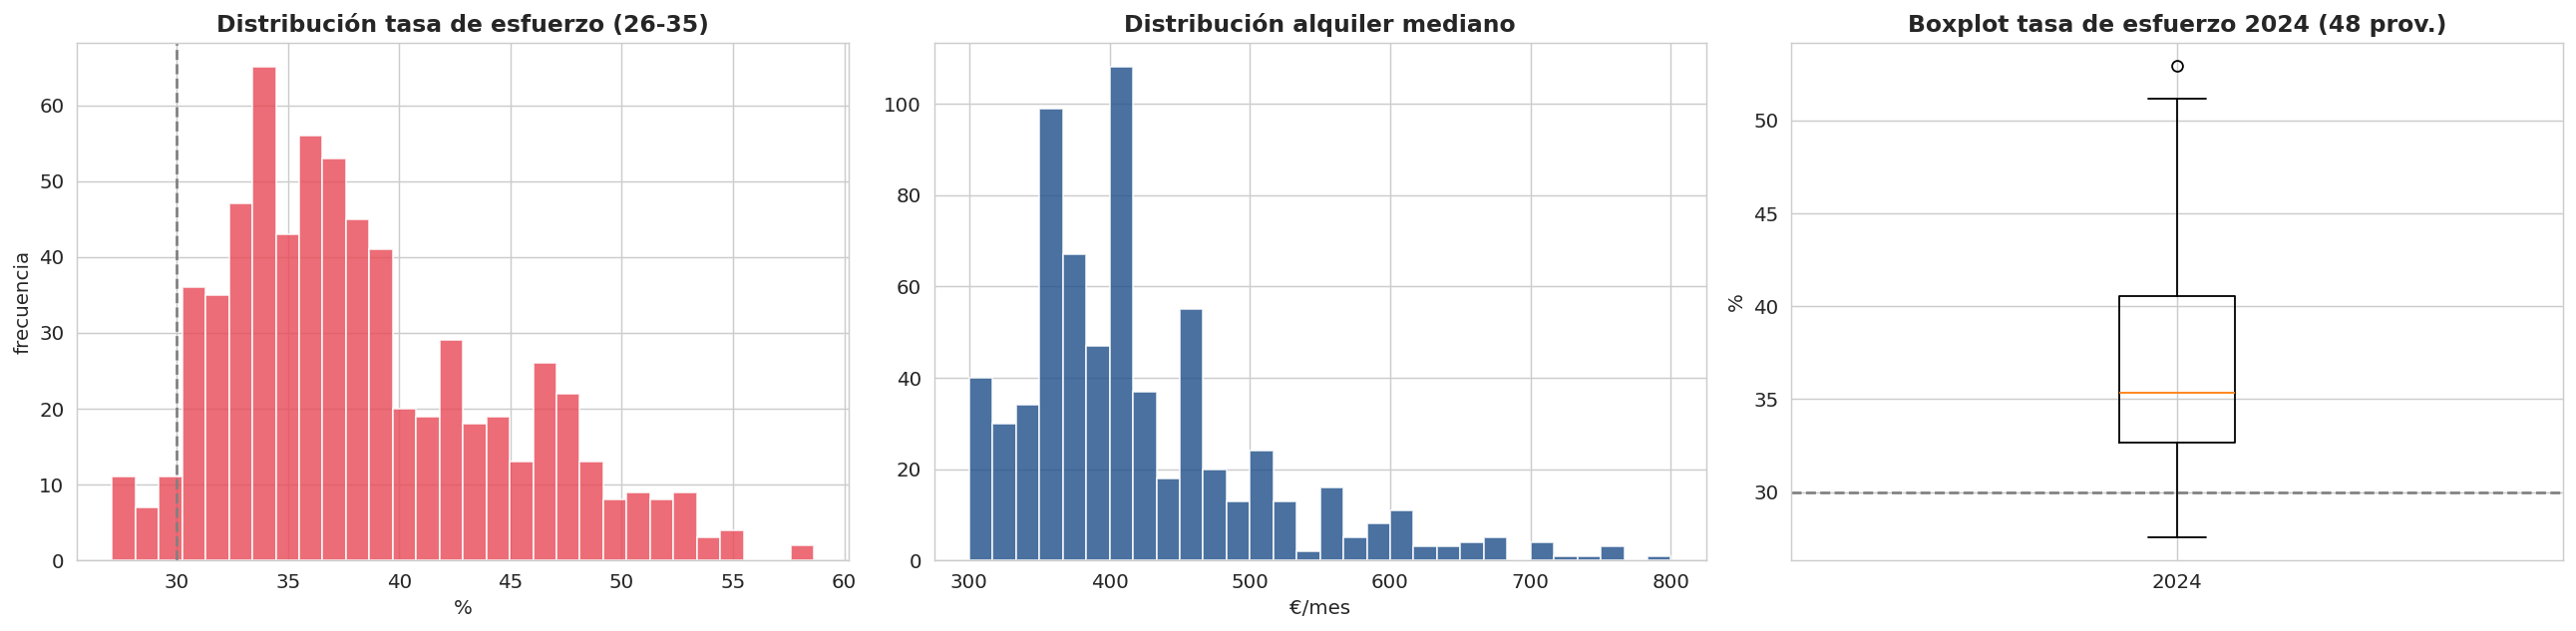


  [✓] Distribuciones y outliers documentados (no se eliminan: provincias reales).


In [23]:
# Distribución y outliers
print("="*60); print("  4.2 · Distribución y outliers"); print("="*60)
def _outliers(serie):
    q1,q3 = serie.quantile(.25), serie.quantile(.75); iqr=q3-q1
    lo,hi = q1-1.5*iqr, q3+1.5*iqr
    return serie[(serie<lo)|(serie>hi)]
for v in ['tasa_esfuerzo','alquiler_mediano']:
    o=_outliers(panel[v]); print(f"  {v}: {len(o)} outliers (IQR)  rango {panel[v].min():.1f}–{panel[v].max():.1f}")
from scipy import stats as _st
_sw = _st.shapiro(panel['tasa_esfuerzo']); _sk = panel['tasa_esfuerzo'].skew()
print(f"  Normalidad (Shapiro-Wilk) tasa_esfuerzo: W={_sw.statistic:.3f} · p={_sw.pvalue:.4f} -> {'NO normal (p<0.05)' if _sw.pvalue<0.05 else 'compatible con normal'}")
print(f"  Asimetría (skew) tasa_esfuerzo: {_sk:.2f}  (>0 = cola a la derecha -> la mediana representa mejor el valor típico)")
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,3,figsize=(20,5))
ax[0].hist(panel['tasa_esfuerzo'],bins=30,color=PALETA[1],alpha=0.8); ax[0].axvline(30,ls='--',color='gray')
ax[0].set_title('Distribución tasa de esfuerzo (26-35)',fontweight='bold'); ax[0].set_xlabel('%'); ax[0].set_ylabel('frecuencia')
ax[1].hist(panel['alquiler_mediano'],bins=30,color=PALETA[0],alpha=0.8)
ax[1].set_title('Distribución alquiler mediano',fontweight='bold'); ax[1].set_xlabel('€/mes')
data24=[panel[panel.año==2024]['tasa_esfuerzo'].values]
ax[2].boxplot(data24); ax[2].set_xticks([1]); ax[2].set_xticklabels(['2024']); ax[2].axhline(30,ls='--',color='gray')
ax[2].set_title('Boxplot tasa de esfuerzo 2024 (48 prov.)',fontweight='bold'); ax[2].set_ylabel('%')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig03_4-2_distribucion_outliers.png'), dpi=150, bbox_inches='tight'); plt.show()
print("\n  [✓] Distribuciones y outliers documentados (no se eliminan: provincias reales).")

*Figura 4. Distribución y valores atípicos de la tasa de esfuerzo. Fuente: elaboración propia.*

### **4.3 Dispersión geográfica**

Ranking provincial de la tasa de esfuerzo en 2024. La heterogeneidad entre provincias, que los agregados nacionales o autonómicos del CJE dejan ocultos, es la aportación provincial de este TFG.

  4.3 · Dispersión geográfica de la tasa de esfuerzo (2024)

  Más asequibles: Lugo 28%, Teruel 28%, Lleida 30%, Ourense 30%, Palencia 31%
  Menos asequibles: Madrid 47%, Sevilla 47%, Ceuta 50%, Balears, Illes 51%, Málaga 53%
  Rango provincial 2024: 28% – 53%  (amplitud 25 p.p.)


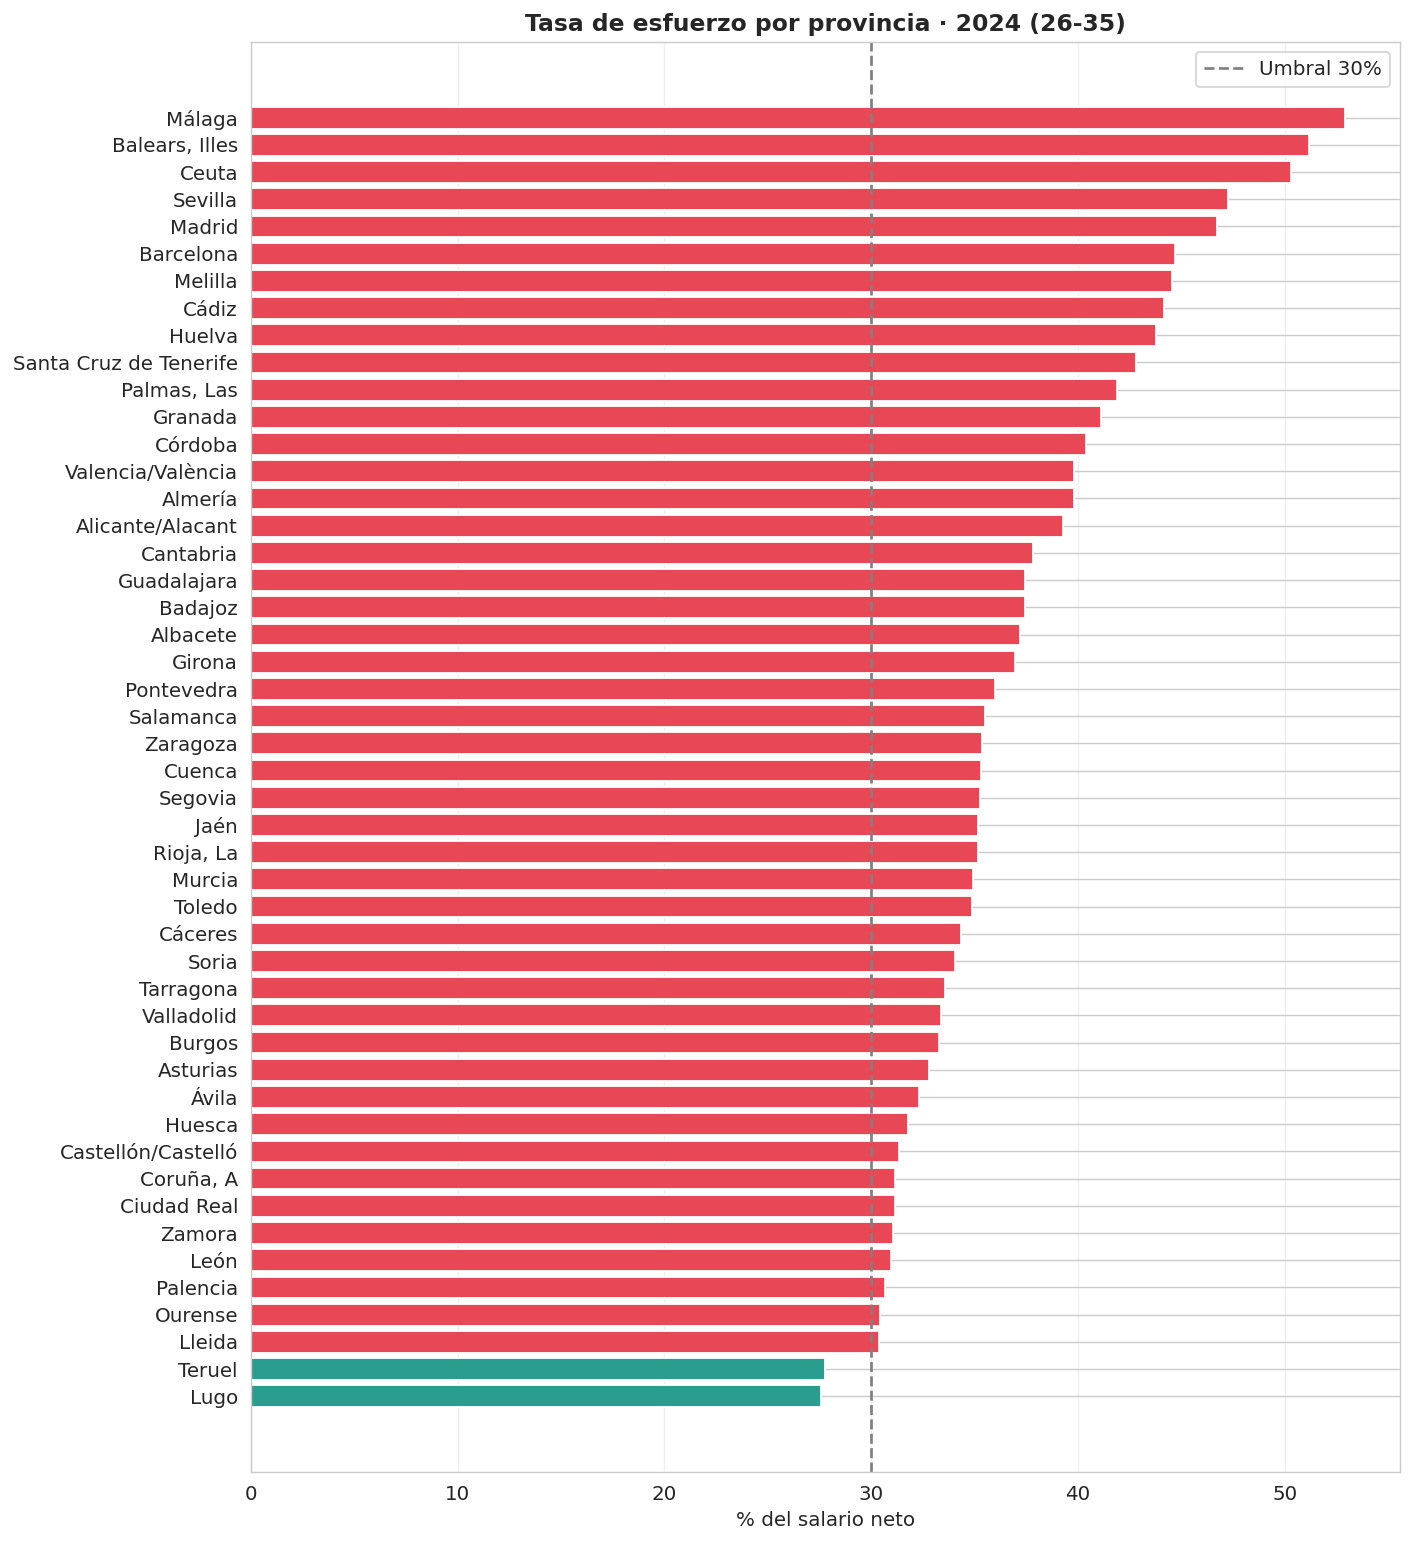


  [✓] Dispersión geográfica (ranking provincial) generada.


In [24]:
# Dispersión geográfica
print("="*60); print("  4.3 · Dispersión geográfica de la tasa de esfuerzo (2024)"); print("="*60)
p24=panel[panel.año==2024][['provincia','tasa_esfuerzo']].sort_values('tasa_esfuerzo')
print(f"\n  Más asequibles: "+", ".join(f"{r.provincia} {r.tasa_esfuerzo:.0f}%" for _,r in p24.head(5).iterrows()))
print(f"  Menos asequibles: "+", ".join(f"{r.provincia} {r.tasa_esfuerzo:.0f}%" for _,r in p24.tail(5).iterrows()))
print(f"  Rango provincial 2024: {p24.tasa_esfuerzo.min():.0f}% – {p24.tasa_esfuerzo.max():.0f}%  "
      f"(amplitud {p24.tasa_esfuerzo.max()-p24.tasa_esfuerzo.min():.0f} p.p.)")
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(11,12))
colors=[PALETA[1] if v>30 else PALETA[3] for v in p24.tasa_esfuerzo]
ax.barh(p24.provincia,p24.tasa_esfuerzo,color=colors); ax.axvline(30,ls='--',color='gray',label='Umbral 30%')
ax.set_title('Tasa de esfuerzo por provincia · 2024 (26-35)',fontweight='bold'); ax.set_xlabel('% del salario neto')
ax.legend(); ax.grid(alpha=0.3,axis='x'); plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig04_4-3_dispersion_geografica.png'), dpi=150, bbox_inches='tight'); plt.show()
print("\n  [✓] Dispersión geográfica (ranking provincial) generada.")

*Figura 5. Tasa de esfuerzo por provincia, 2024. Fuente: elaboración propia.*

### **4.4 Correlaciones**

Matriz de correlaciones (Pearson y Spearman) entre las variables del panel. Calcular las dos no es redundante: Pearson capta la asociación lineal y Spearman la monótona por rangos, robusta a valores extremos y a relaciones no lineales; que ambas coincidan refuerza la lectura y ayuda a anticipar relaciones (por ejemplo, alquiler–esfuerzo) y posibles colinealidades de cara al modelado.

De los resultados se desprende que la tasa de esfuerzo se asocia sobre todo con el **alquiler** (asociación positiva y la más alta del bloque), mientras que con el **salario** la asociación bivariante es débil y de signo negativo: donde los salarios son mayores, los alquileres también lo son, de modo que el efecto neto sobre el esfuerzo se diluye. Destaca además la fuerte relación negativa entre paro y salario, coherente con el mercado laboral. Pearson y Spearman apuntan en la misma dirección, lo que descarta que la relación dependa de unos pocos valores extremos. No se infiere causalidad: estas asociaciones se contrastan formalmente en el pilar de Análisis del Dato.

  4.4 · Correlaciones entre variables del panel

  Pearson:
                   alquiler_mediano  neto_mes_26_35  paro_total  smi_mes  tasa_esfuerzo
alquiler_mediano              1.00            0.62       -0.17     0.44           0.63
neto_mes_26_35                0.62            1.00       -0.71     0.65          -0.20
paro_total                   -0.17           -0.71        1.00    -0.57           0.48
smi_mes                       0.44            0.65       -0.57     1.00          -0.05
tasa_esfuerzo                 0.63           -0.20        0.48    -0.05           1.00

  Spearman:
                   alquiler_mediano  neto_mes_26_35  paro_total  smi_mes  tasa_esfuerzo
alquiler_mediano              1.00            0.60       -0.23     0.42           0.56
neto_mes_26_35                0.60            1.00       -0.74     0.57          -0.26
paro_total                   -0.23           -0.74        1.00    -0.61           0.49
smi_mes                       0.42            0.57     

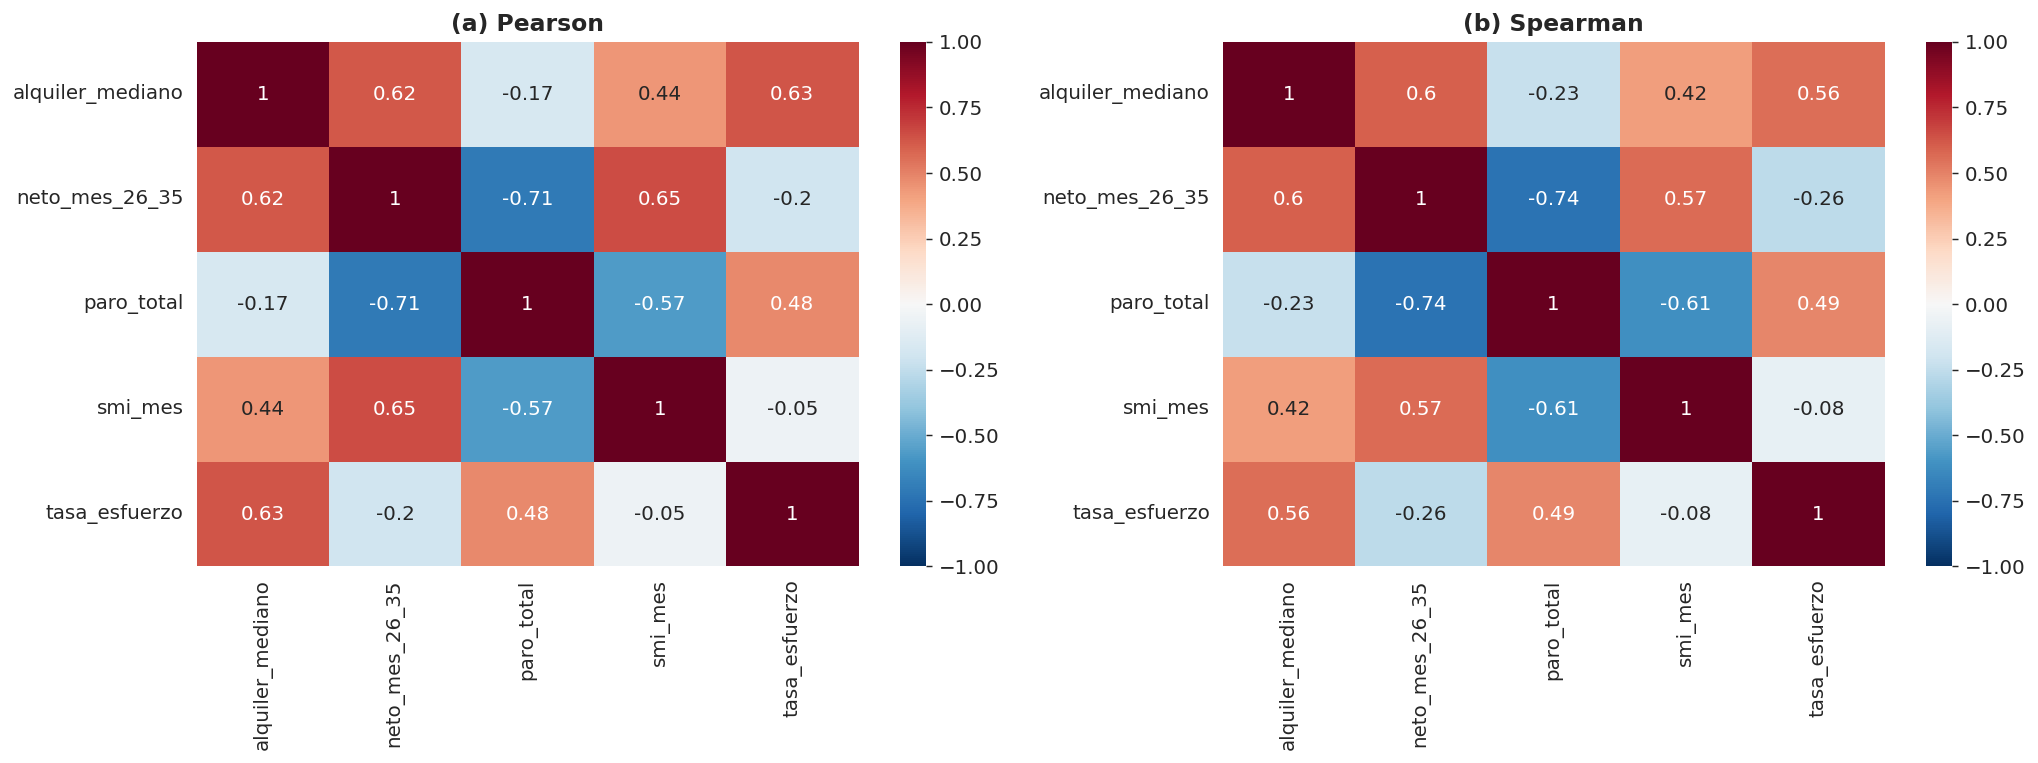


  Lectura: corr(alquiler, esfuerzo) = 0.63 (Pearson) / 0.56 (Spearman) -> coinciden;
           corr(salario, esfuerzo) = -0.20 (Pearson) / -0.26 (Spearman). El alquiler es la variable más asociada a la tasa de esfuerzo.

  [✓] Correlaciones (Pearson y Spearman) calculadas e interpretadas.


In [25]:
# Correlaciones
print("="*60); print("  4.4 · Correlaciones entre variables del panel"); print("="*60)
cols=['alquiler_mediano','neto_mes_26_35','paro_total','smi_mes','tasa_esfuerzo']
pear=panel[cols].corr(method='pearson').round(2)
spear=panel[cols].corr(method='spearman').round(2)
print("\n  Pearson:\n", pear.to_string())
print("\n  Spearman:\n", spear.to_string())
import matplotlib.pyplot as plt, seaborn as sns
fig,ax=plt.subplots(1,2,figsize=(16,6))
sns.heatmap(pear,annot=True,cmap='RdBu_r',center=0,vmin=-1,vmax=1,ax=ax[0]); ax[0].set_title('(a) Pearson',fontweight='bold')
sns.heatmap(spear,annot=True,cmap='RdBu_r',center=0,vmin=-1,vmax=1,ax=ax[1]); ax[1].set_title('(b) Spearman',fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig05_4-4_correlaciones.png'), dpi=150, bbox_inches='tight'); plt.show()
_pa=pear.loc['alquiler_mediano','tasa_esfuerzo']; _ps=pear.loc['neto_mes_26_35','tasa_esfuerzo']
_sa=spear.loc['alquiler_mediano','tasa_esfuerzo']; _ss=spear.loc['neto_mes_26_35','tasa_esfuerzo']
print(f"\n  Lectura: corr(alquiler, esfuerzo) = {_pa:.2f} (Pearson) / {_sa:.2f} (Spearman) -> coinciden;")
print(f"           corr(salario, esfuerzo) = {_ps:.2f} (Pearson) / {_ss:.2f} (Spearman). "
      "El alquiler es la variable más asociada a la tasa de esfuerzo.")
print("\n  [✓] Correlaciones (Pearson y Spearman) calculadas e interpretadas.")

*Figura 6. Matriz de correlaciones entre las variables del panel: (a) Pearson; (b) Spearman. Fuente: elaboración propia.*

### **4.5 Series temporales y estacionariedad (test ADF)**

Se estudia la evolución de la tasa de esfuerzo media nacional y se aplica el test de Dickey-Fuller aumentado (ADF) para evaluar la estacionariedad, requisito para el modelado de series temporales (ARIMA) del Análisis del Dato. El contraste enfrenta dos hipótesis: H0 —la serie tiene raíz unitaria, es decir, no es estacionaria— frente a H1 —la serie es estacionaria—, y se rechaza H0 cuando el p-valor cae por debajo de 0,05. Con solo 14 observaciones anuales la potencia del test es limitada, y así se hace constar.

  4.5 · Series temporales y estacionariedad (ADF)

  Tasa de esfuerzo media nacional: 38.3% (2011) → 37.1% (2024)

  ADF [tasa_esfuerzo media]: estadístico=-2.017, p-valor=0.279 → NO estacionaria (probable tendencia → diferenciar en el modelo ARIMA)

  ADF [alquiler_real medio]: estadístico=-4.878, p-valor=0.000 → estacionaria

  Nota: serie corta (14 años) → potencia limitada del ADF; se complementa con inspección visual.


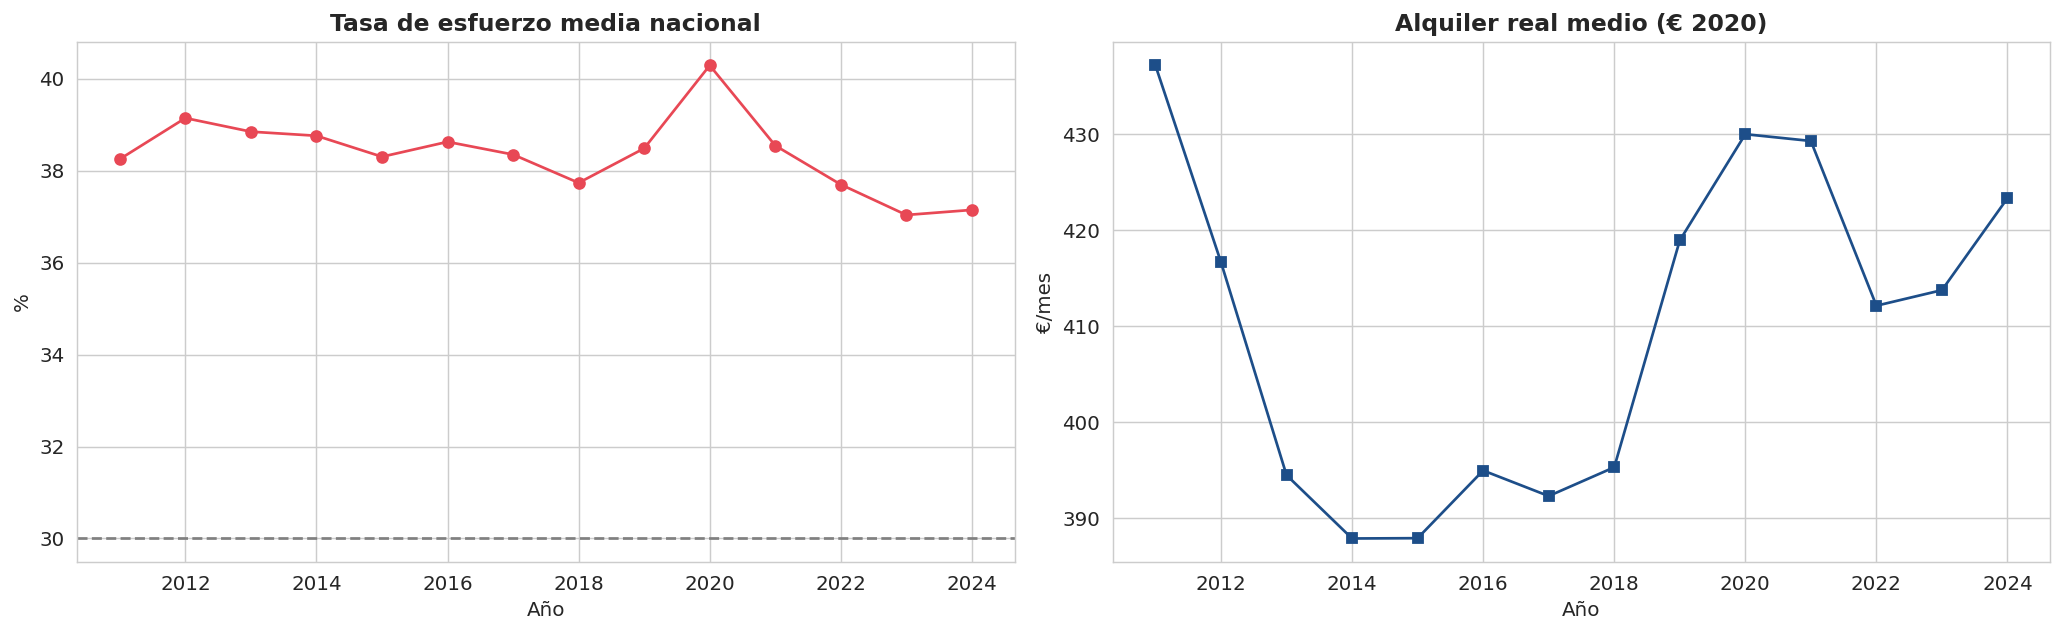


  [✓] Estudio de estacionariedad completado.


In [26]:
# Series temporales + ADF
from statsmodels.tsa.stattools import adfuller
print("="*60); print("  4.5 · Series temporales y estacionariedad (ADF)"); print("="*60)
serie = panel.groupby('año')['tasa_esfuerzo'].mean()
serie_alq = panel.groupby('año')['alquiler_real'].mean()
print(f"\n  Tasa de esfuerzo media nacional: {serie.iloc[0]:.1f}% ({serie.index[0]}) → {serie.iloc[-1]:.1f}% ({serie.index[-1]})")
for nom,s in [('tasa_esfuerzo media',serie),('alquiler_real medio',serie_alq)]:
    try:
        adf=adfuller(s.values, autolag='AIC')
        concl = "estacionaria" if adf[1]<0.05 else "NO estacionaria (probable tendencia → diferenciar en el modelo ARIMA)"
        print(f"\n  ADF [{nom}]: estadístico={adf[0]:.3f}, p-valor={adf[1]:.3f} → {concl}")
    except Exception as e:
        print(f"  ADF [{nom}]: no calculable ({e})")
print(f"\n  Nota: serie corta (14 años) → potencia limitada del ADF; se complementa con inspección visual.")
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(16,5))
ax[0].plot(serie.index,serie.values,marker='o',color=PALETA[1]); ax[0].axhline(30,ls='--',color='gray')
ax[0].set_title('Tasa de esfuerzo media nacional',fontweight='bold'); ax[0].set_xlabel('Año'); ax[0].set_ylabel('%')
ax[1].plot(serie_alq.index,serie_alq.values,marker='s',color=PALETA[0])
ax[1].set_title('Alquiler real medio (€ 2020)',fontweight='bold'); ax[1].set_xlabel('Año'); ax[1].set_ylabel('€/mes')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig06_4-5_series_adf.png'), dpi=150, bbox_inches='tight'); plt.show()
print("\n  [✓] Estudio de estacionariedad completado.")

*Figura 7. Evolución temporal de la tasa de esfuerzo y del alquiler real; contraste ADF. Fuente: elaboración propia.*

### **4.6 Gradiente por edad**

Comparación de la tasa de esfuerzo de las tres bandas (18-25, 26-35 y 36-45). Cuantifica la precariedad diferencial dentro de la juventud, un resultado que los agregados juveniles no dejan ver.

  4.6 · Gradiente de esfuerzo por edad

  Esfuerzo medio 2024 — 18-25: 72%  26-35: 37%  36-45: 31%


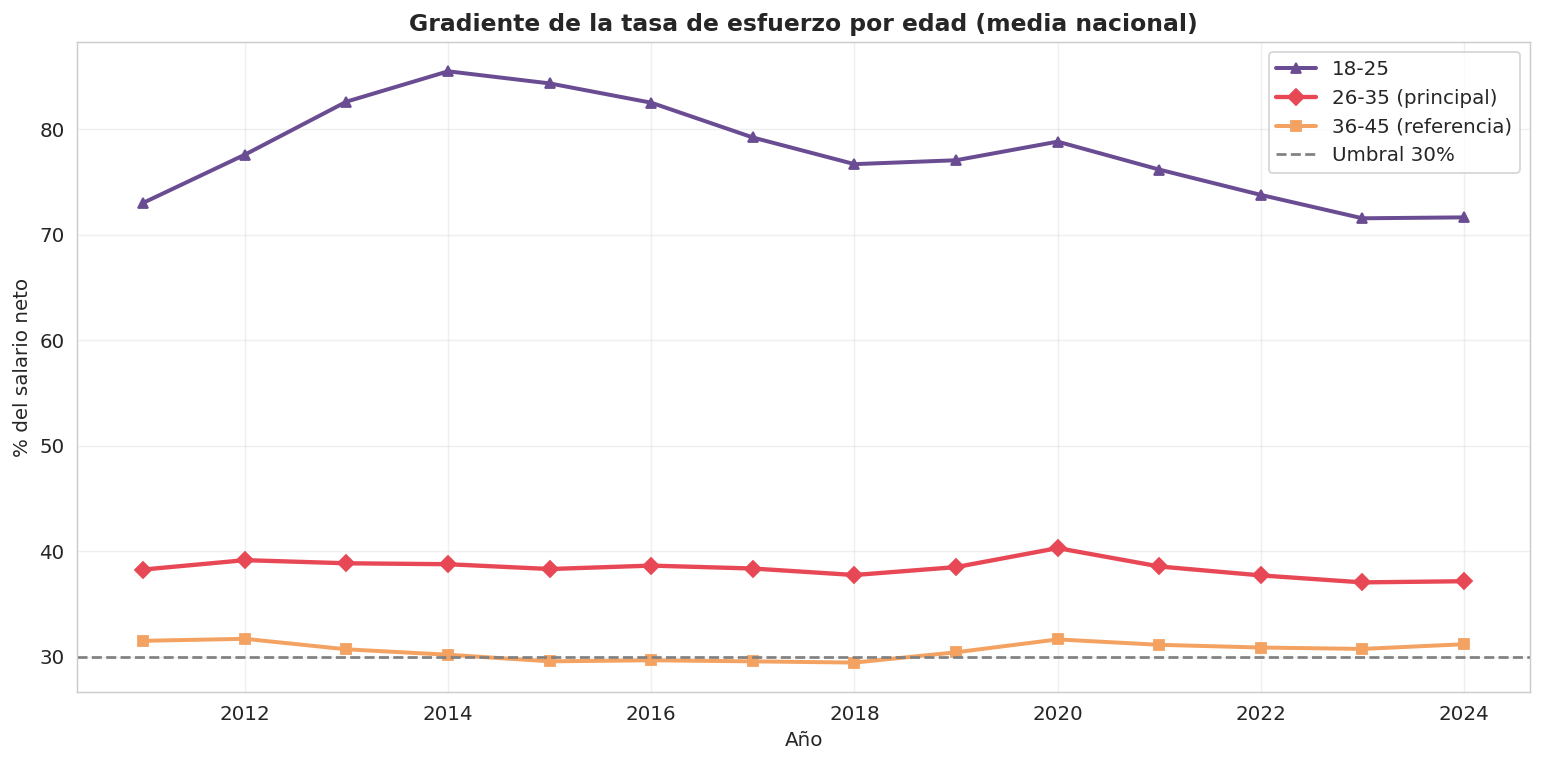


  [✓] Gradiente por edad analizado.


In [27]:
# Gradiente por edad
print("="*60); print("  4.6 · Gradiente de esfuerzo por edad"); print("="*60)
g=panel.groupby('año')[['tasa_esfuerzo_18_25','tasa_esfuerzo','tasa_esfuerzo_36_45']].mean()
print(f"\n  Esfuerzo medio 2024 — 18-25: {g.loc[2024,'tasa_esfuerzo_18_25']:.0f}%  "
      f"26-35: {g.loc[2024,'tasa_esfuerzo']:.0f}%  36-45: {g.loc[2024,'tasa_esfuerzo_36_45']:.0f}%")
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(12,6))
ax.plot(g.index,g['tasa_esfuerzo_18_25'],marker='^',lw=2.2,color=PALETA[4],label='18-25')
ax.plot(g.index,g['tasa_esfuerzo'],marker='D',lw=2.4,color=PALETA[1],label='26-35 (principal)')
ax.plot(g.index,g['tasa_esfuerzo_36_45'],marker='s',lw=2.2,color=PALETA[2],label='36-45 (referencia)')
ax.axhline(30,ls='--',color='gray',label='Umbral 30%')
ax.set_title('Gradiente de la tasa de esfuerzo por edad (media nacional)',fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('% del salario neto'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig07_4-6_gradiente_edad.png'), dpi=150, bbox_inches='tight'); plt.show()
print("\n  [✓] Gradiente por edad analizado.")

*Figura 8. Gradiente de la tasa de esfuerzo por edad. Fuente: elaboración propia.*

### **4.7 Validación externa (CJE / INJUVE)**

Los resultados concuerdan con los organismos de referencia: el Consejo de la Juventud de España (Observatorio de Emancipación) y el INJUVE (*Jóvenes en la EPA*) sitúan la tasa de emancipación juvenil en mínimos históricos (~15% en 2024) y estiman que alquilar una vivienda en solitario consume en torno al 90% del salario de una persona joven. Estas cifras nacionales (del CJE/INJUVE, citadas en la memoria) corroboran la magnitud del desequilibrio que aquí se mide a escala provincial; se usan como contraste externo cualitativo, no como variables del panel.

Esto perfila también la aportación del TFG: el seguimiento del CJE/INJUVE es nacional o autonómico y descriptivo, mientras que este trabajo aporta resolución provincial, explicativa y predictiva. La tasa de emancipación funciona como *benchmark* externo de validación, no como variable del panel, por publicarse solo a escala autonómica.

### **Conclusiones de la Sección 4 — EDA**

El análisis exploratorio respalda en términos descriptivos las hipótesis de trabajo y responde, también de forma descriptiva, a la pregunta de investigación:

- *Magnitud.* La tasa de esfuerzo de la banda 26-35 supera el umbral del 30% en la gran mayoría de provincias-año (cota superior con la AEAT; robusto en el análisis de sensibilidad).
- *Variación geográfica.* Hay una amplia dispersión provincial en 2024 (28% en Lugo/Teruel frente a 53% en Málaga; 25 p.p. de amplitud), lo que justifica el enfoque provincial frente a los agregados del CJE.
- *Asociación descriptiva dominante.* corr(alquiler, esfuerzo) = 0,63 frente a corr(salario, esfuerzo) = −0,20. La evolución del alquiler concentra buena parte de la tensión observada (hipótesis a contrastar formalmente en el Análisis del Dato), coherente con la caída del paro juvenil en el período.
- *Variación temporal.* La tasa de esfuerzo media no muestra una mejora estructural clara (38,3% en 2011 → 37,1% en 2024, siempre por encima del 30%) y el ADF la señala como no estacionaria (p≈0,28, habrá que tratar su tendencia en el modelo de series temporales (ARIMA)); el resultado de estacionariedad del alquiler real conviene tomarlo con cautela por lo corto de la serie (14 años).
- *Gradiente por edad.* La banda 18-25 soporta una carga muy superior, señal de la precariedad de la primera fase de emancipación.

Estos hallazgos alimentan el Análisis del Dato (determinantes con regresión regularizada —Ridge—, Random Forest y Gradient Boosting, tipologías con K-Means y proyección con ARIMA).

---

## **5. Dataset final y exportación**

Es la fase *Load* del ETL: se valida el panel analítico definitivo, se documenta su diccionario de variables, se contrasta el tipado antes/después (la foto en bruto frente al panel final) y se exporta a CSV para el Análisis del Dato.

### **5.1 Panel final y diccionario de variables**

El dataset analítico es un panel `provincia × año`: 48 provincias de régimen común × 14 años = 672 observaciones, sin valores faltantes en las variables núcleo.

*Tabla 6. Diccionario de variables del panel (30 campos). Fuente: elaboración propia.*

In [28]:
# Panel final + diccionario
print("="*60); print("  5.1 · Panel final (48 provincias comunes × 14 años)"); print("="*60)
print(f"\n  Dimensiones: {panel.shape[0]} filas × {panel.shape[1]} columnas")
print(f"  Provincias: {panel.cpro.nunique()} · Años: {panel.año.min()}–{panel.año.max()}")
print(f"  Duplicados (cpro,año): {panel.duplicated(['cpro','año']).sum()}")
DICCIONARIO = {
 'cpro':'Código INE de provincia (clave)','año':'Año (clave)','provincia':'Nombre de provincia','ccaa':'Comunidad autónoma',
 'alquiler_mediano':'Alquiler mediano mensual €/mes (SERPAVI) — dependiente',
 'alquiler_m2':'Alquiler mediano €/m²·mes','superficie_m2':'Superficie mediana m²','n_contratos':'Nº de contratos',
 'neto_mes_18_25':'Salario neto mensual 18-25 (€)','neto_mes_26_35':'Salario neto mensual 26-35 (€) — denominador KPI',
 'neto_mes_36_45':'Salario neto mensual 36-45 (€)','neto_mes_18_34':'Salario neto mensual 18-34 ponderado (€)',
 'sal_26_35':'Salario bruto anual 26-35 (€, AEAT)','paro_total':'Tasa de paro total provincial (%)',
 'factor_2020':'Factor de deflactación a € de 2020','smi_mes':'SMI mensual nacional (€)',
 'tasa_esfuerzo':'KPI: alquiler/salario neto 26-35 (%)','tasa_esfuerzo_18_25':'Esfuerzo 18-25 (%)',
 'tasa_esfuerzo_36_45':'Esfuerzo 36-45 (%)','tasa_esfuerzo_18_34':'Esfuerzo 18-34 (%)',
 'sobre_30':'1 si esfuerzo>30% (umbral asequibilidad)','alquiler_real':'Alquiler en € constantes 2020',
 'salario_real_26_35':'Salario neto real 26-35 (€ 2020)','D_2021':'Dummy ruptura base EPA (1 si año≥2021)',
 'alquiler_mediano_lag1':'Alquiler mediano del año anterior (€/mes)',
 'neto_mes_26_35_lag1':'Salario neto 26-35 del año anterior (€)',
 'paro_total_lag1':'Tasa de paro total del año anterior (%)',
 'tasa_esfuerzo_lag1':'Tasa de esfuerzo (26-35) del año anterior (%)',
 'var_alquiler_pct':'Variación interanual del alquiler (%)',
 'var_salario_pct':'Variación interanual del salario neto 26-35 (%)'}
print(f"\n  Diccionario de variables ({len(DICCIONARIO)} campos):")
for k,v in DICCIONARIO.items():
    print(f"    {k:<22} {v}")
faltan=[c for c in panel.columns if c not in DICCIONARIO]
print(f"\n  Columnas sin documentar: {faltan if faltan else 'ninguna ✓'}")
print("\n  [✓] Panel final documentado.")

  5.1 · Panel final (48 provincias comunes × 14 años)

  Dimensiones: 672 filas × 30 columnas
  Provincias: 48 · Años: 2011–2024
  Duplicados (cpro,año): 0

  Diccionario de variables (30 campos):
    cpro                   Código INE de provincia (clave)
    año                    Año (clave)
    provincia              Nombre de provincia
    ccaa                   Comunidad autónoma
    alquiler_mediano       Alquiler mediano mensual €/mes (SERPAVI) — dependiente
    alquiler_m2            Alquiler mediano €/m²·mes
    superficie_m2          Superficie mediana m²
    n_contratos            Nº de contratos
    neto_mes_18_25         Salario neto mensual 18-25 (€)
    neto_mes_26_35         Salario neto mensual 26-35 (€) — denominador KPI
    neto_mes_36_45         Salario neto mensual 36-45 (€)
    neto_mes_18_34         Salario neto mensual 18-34 ponderado (€)
    sal_26_35              Salario bruto anual 26-35 (€, AEAT)
    paro_total             Tasa de paro total provincial (%)
 

### **5.2 Tipado de datos: comparación antes / después**

Contraste del tipo de dato entre el estado bruto (Sección 2.7) y el panel final: las cabeceras leídas como texto pasan a numérico o entero, y los identificadores quedan correctamente tipados. Es la evidencia del trabajo de tipado del ETL.

In [29]:
# Tipado antes/después
print("="*60); print("  5.2 · Tipos de datos: antes (bruto) vs después (panel)"); print("="*60)
print("\n  ANTES (estado bruto, Sección 2.7):")
print(df_tipos_raw.to_string(index=False))
import pandas as pd
dt=panel.dtypes
res={'numéricas':int(sum(pd.api.types.is_numeric_dtype(t) for t in dt)),
     'enteras':int(sum(pd.api.types.is_integer_dtype(t) for t in dt)),
     'texto':int(sum(t==object for t in dt))}
print(f"\n  DESPUÉS (panel final): {panel.shape[1]} columnas → "
      f"numéricas={res['numéricas']} (de ellas enteras={res['enteras']}), texto={res['texto']}")
print("  Detalle de tipos del panel:")
for c,t in panel.dtypes.items(): print(f"    {c:<22} {t}")
print("\n  Lectura: en bruto casi todo era 'texto' (cabeceras leídas como datos);")
print("  el panel final tiene tipos correctos (float/int para magnitudes, object solo en etiquetas).")
print("\n  [✓] Comparación de tipado antes/después completada.")

  5.2 · Tipos de datos: antes (bruto) vs después (panel)

  ANTES (estado bruto, Sección 2.7):
  fuente  filas  cols  numericas  texto  fecha
 SERPAVI     53   282          0    282      0
    EAES   1978     4          0      4      0
EPA prov    179   292          0    292      0
EPA edad     80   680          0    680      0
     IPC    314  1173          0   1173      0
     SMI     61    10          0     10      0

  DESPUÉS (panel final): 30 columnas → numéricas=28 (de ellas enteras=4), texto=2
  Detalle de tipos del panel:
    cpro                   int64
    año                    int64
    alquiler_mediano       float64
    alquiler_m2            float64
    superficie_m2          float64
    n_contratos            float64
    neto_mes_18_25         float64
    neto_mes_26_35         float64
    neto_mes_36_45         float64
    neto_mes_18_34         float64
    sal_26_35              float64
    paro_total             float64
    factor_2020            float64
    smi_mes 

#### Resumen de variables: ANTES (bruto) → DESPUÉS (panel)

Tabla de texto (no gráfica) calculada por código desde los DataFrames: para cada fuente, cuántas columnas traía en bruto y cuántas variables aporta al panel; y para cada una de las 30 variables del panel, su origen, su tipo antes → después y la transformación aplicada. Resume de un vistazo el trabajo sobre las variables y refuerza el análisis de variables antes/después.

In [30]:
# Resumen de variables ANTES -> DESPUES (todo desde los DataFrames / metadatos del proceso)
# Origen y transformacion de cada variable del panel (documentacion del proceso, como el diccionario):
ORIGEN = {
 'cpro':('df_geo','clave geográfica'), 'provincia':('df_geo','clave geográfica'), 'ccaa':('df_geo','clave geográfica'),
 'año':('clave','clave temporal'),
 'alquiler_mediano':('SERPAVI','wide→long (tidy)'), 'alquiler_m2':('SERPAVI','wide→long'),
 'superficie_m2':('SERPAVI','wide→long'), 'n_contratos':('SERPAVI','wide→long'),
 'sal_26_35':('AEAT','salario bruto €/año'),
 'neto_mes_18_25':('AEAT','bruto→neto'), 'neto_mes_26_35':('AEAT','bruto→neto'), 'neto_mes_36_45':('AEAT','bruto→neto'),
 'neto_mes_18_34':('AEAT','agregado ponderado'),
 'paro_total':('EPA prov','trimestral→anual'),
 'factor_2020':('IPC','deflactor €2020'),
 'smi_mes':('SMI','serie anual'),
 'tasa_esfuerzo':('derivada','KPI alquiler/neto 26-35'), 'tasa_esfuerzo_18_25':('derivada','KPI por edad'),
 'tasa_esfuerzo_36_45':('derivada','KPI por edad'), 'tasa_esfuerzo_18_34':('derivada','KPI por edad'),
 'sobre_30':('derivada','umbral 30%'),
 'alquiler_real':('derivada','deflactada €2020'), 'salario_real_26_35':('derivada','deflactada €2020'),
 'D_2021':('derivada','dummy estructural'),
 'alquiler_mediano_lag1':('derivada','lag-1'), 'neto_mes_26_35_lag1':('derivada','lag-1'),
 'paro_total_lag1':('derivada','lag-1'), 'tasa_esfuerzo_lag1':('derivada','lag-1'),
 'var_alquiler_pct':('derivada','variación interanual'), 'var_salario_pct':('derivada','variación interanual'),
}
print("="*82); print("  RESUMEN DE VARIABLES: ANTES (bruto) → DESPUÉS (panel)"); print("="*82)

print("\n  [A] Por fuente:")
print(f"  {'Fuente':<18}{'Tamaño en bruto':>18}{'→ vars. al panel':>18}")
print("  " + "-"*54)
for f in ['SERPAVI','AEAT','EPA prov','IPC','SMI']:
    n = sum(1 for o,_ in ORIGEN.values() if o == f)
    print(f"  {f:<18}{SHAPES_RAW.get(f,'—'):>18}{n:>18}")
n_clave = sum(1 for o,_ in ORIGEN.values() if o in ('df_geo','clave'))
n_deriv = sum(1 for o,_ in ORIGEN.values() if o == 'derivada')
print(f"  {'Claves (geo/año)':<18}{'—':>18}{n_clave:>18}")
print(f"  {'Derivadas (3.6/3.6c)':<18}{'—':>18}{n_deriv:>18}")
print(f"  {'TOTAL panel':<18}{'':>18}{len(panel.columns):>18}")

print("\n  [B] Por variable  (origen · tipo antes → después · transformación):")
print(f"  {'Variable':<24}{'Origen':<12}{'Antes':<8}{'Después':<10}{'Transformación'}")
print("  " + "-"*80)
for col in panel.columns:
    o, tr = ORIGEN.get(col, ('—','—'))
    antes = '—' if o == 'derivada' else 'texto'
    print(f"  {col:<24}{o:<12}{antes:<8}{str(panel[col].dtype):<10}{tr}")

assert set(panel.columns) <= set(ORIGEN), "Hay columnas del panel sin origen documentado"
print("\n  [✓] Resumen antes→después de variables completo (sin columnas sin documentar).")


  RESUMEN DE VARIABLES: ANTES (bruto) → DESPUÉS (panel)

  [A] Por fuente:
  Fuente               Tamaño en bruto  → vars. al panel
  ------------------------------------------------------
  SERPAVI                     53 × 282                 4
  AEAT                          42 PDF                 5
  EPA prov                   179 × 292                 1
  IPC                       314 × 1173                 1
  SMI                          61 × 10                 1
  Claves (geo/año)                   —                 4
  Derivadas (3.6/3.6c)                 —                14
  TOTAL panel                                         30

  [B] Por variable  (origen · tipo antes → después · transformación):
  Variable                Origen      Antes   Después   Transformación
  --------------------------------------------------------------------------------
  cpro                    df_geo      texto   int64     clave geográfica
  año                     clave       texto   int64    

### **5.2b Dataset complementario: panel por edad**

Para estudiar la asequibilidad por banda de edad se construye un panel en formato largo `provincia × año × banda` (48 × 14 × 3 = 2.016 observaciones), donde el salario y la tasa de esfuerzo varían por banda (18-25 / 26-35 / 36-45) y el alquiler es el de la vivienda, común a las tres. Es un enriquecimiento legítimo: triplica las observaciones solo para las variables que realmente dependen de la edad, lo que permite analizar el gradiente de precariedad con mayor resolución.

In [31]:
print("="*60); print("  5.2b · Panel por edad (provincia × año × banda) = 2.016 obs."); print("="*60)
_base = panel[['cpro','provincia','ccaa','año','alquiler_mediano','factor_2020']]
_long = []
for b,lab in [('18_25','18-25'),('26_35','26-35'),('36_45','36-45')]:
    t = _base.merge(df_salario[['cpro','año',f'neto_mes_{b}']], on=['cpro','año'])
    t = t.rename(columns={f'neto_mes_{b}':'salario_neto_mes'}); t['banda_edad'] = lab
    _long.append(t)
panel_edad = pd.concat(_long, ignore_index=True)
panel_edad['tasa_esfuerzo'] = (panel_edad['alquiler_mediano']/panel_edad['salario_neto_mes']*100).round(2)
panel_edad['alquiler_real'] = (panel_edad['alquiler_mediano']*panel_edad['factor_2020']).round(2)
panel_edad['sobre_30'] = (panel_edad['tasa_esfuerzo']>30).astype(int)
panel_edad = panel_edad.sort_values(['cpro','año','banda_edad']).reset_index(drop=True)
print(f"\n  Dimensiones: {panel_edad.shape[0]} filas (48×14×3) × {panel_edad.shape[1]} columnas")
print(f"  Bandas: {sorted(panel_edad.banda_edad.unique())} · NaN: {int(panel_edad.isna().sum().sum())}")
print(f"  Esfuerzo medio 2024 por banda:")
print(panel_edad[panel_edad.año==2024].groupby('banda_edad')['tasa_esfuerzo'].mean().round(1).to_string())
panel_edad.to_csv(os.path.join(DIR_OUT, 'panel_TFG_por_edad_2016obs.csv'), index=False, encoding='utf-8-sig')
print(f"\n  ✓ Exportado: panel_TFG_por_edad_2016obs.csv")
print("\n  [✓] Panel complementario por edad listo.")

  5.2b · Panel por edad (provincia × año × banda) = 2.016 obs.

  Dimensiones: 2016 filas (48×14×3) × 11 columnas
  Bandas: ['18-25', '26-35', '36-45'] · NaN: 0
  Esfuerzo medio 2024 por banda:
banda_edad
18-25   71.60
26-35   37.10
36-45   31.20

  ✓ Exportado: panel_TFG_por_edad_2016obs.csv

  [✓] Panel complementario por edad listo.


### **5.2c Población joven y dimensión del impacto**

Fuente complementaria (INE, Estadística del Padrón): población de 18 a 34 años por provincia, para pasar del porcentaje de esfuerzo a la magnitud humana del problema, es decir, cuántos jóvenes viven en provincias donde alquilar en solitario supera el 30% del salario. Es contexto e impacto para el Análisis de Negocio y no entra en el panel de modelado. La cobertura es 2011-2022 (la serie histórica del Padrón, que no incluye 2023-2024, ya publicados por el INE en otra serie); el titular de impacto usa el último año disponible, 2022, sin estimar ni fabricar datos.

In [32]:
print("="*60); print("  5.2c · Población joven 18-34 por provincia (impacto)"); print("="*60)
import re
_raw = pd.read_excel(f'{DRIVE}/INE_poblacion_joven_provincia.xlsx', header=None)
# Bloque 'Ambos sexos' = columnas 1..25 ; fila 7 = años (2022..1998)
_colyear = {j:int(_raw.iloc[7, j]) for j in range(1, 26)}
_prov=None; _age=None; _recs={}
for _, row in _raw.iterrows():
    lab = row[0]
    if not isinstance(lab, str): continue
    nlead = len(lab) - len(lab.lstrip(' ')); st = lab.strip()
    if nlead == 0:                                   # provincia
        mm = re.match(r'^(\d{2})\s+', st); _prov = int(mm.group(1)) if mm else None; _age=None
    elif nlead <= 4:                                 # nivel edad
        ma = re.match(r'^(\d{1,2})\s+años?$', st);  _age = int(ma.group(1)) if ma else None
    elif st == 'TOTAL' and _prov is not None and _age is not None and 18 <= _age <= 34:
        for j in range(1, 26):
            y = _colyear[j]; v = row[j]
            if pd.notna(v): _recs[(_prov, y)] = _recs.get((_prov, y), 0) + float(v)
df_pob = pd.DataFrame([{'cpro':k[0], 'año':k[1], 'pob_18_34':int(v)} for k,v in _recs.items()])
df_pob = df_pob[(df_pob['cpro'].isin(CPRO_COMUN)) & (df_pob['año'].between(ANIO_INICIO, ANIO_FIN))]
print(f"\n  Cobertura: {df_pob['año'].min()}–{df_pob['año'].max()} · {df_pob['cpro'].nunique()} provincias · {len(df_pob)} filas")
print(f"  NaN: {int(df_pob['pob_18_34'].isna().sum())}")

# Dimensión del impacto (último año disponible)
_ult = df_pob['año'].max()
_imp = panel[panel['año']==_ult][['cpro','provincia','sobre_30']].merge(df_pob[df_pob['año']==_ult], on='cpro')
_afect = int(_imp.loc[_imp['sobre_30']==1, 'pob_18_34'].sum()); _tot = int(_imp['pob_18_34'].sum())
print(f"\n  Dimensión del impacto en {_ult} (jóvenes 18-34 en provincias donde la banda 26-35 supera el 30%):")
print(f"    {_afect:,} de {_tot:,} jóvenes  =  {100*_afect/_tot:.1f}%")
df_pob.to_csv(os.path.join(DIR_OUT, 'panel_TFG_poblacion_joven_2011_2022.csv'), index=False, encoding='utf-8-sig')
print(f"\n  ✓ Exportado: panel_TFG_poblacion_joven_2011_2022.csv")
print("\n  [✓] Población joven (impacto) integrada como dataset complementario.")

  5.2c · Población joven 18-34 por provincia (impacto)

  Cobertura: 2011–2022 · 48 provincias · 576 filas
  NaN: 0

  Dimensión del impacto en 2022 (jóvenes 18-34 en provincias donde la banda 26-35 supera el 30%):
    8,017,646 de 8,190,562 jóvenes  =  97.9%

  ✓ Exportado: panel_TFG_poblacion_joven_2011_2022.csv

  [✓] Población joven (impacto) integrada como dataset complementario.


### **5.3 Seguimiento de registros (tracking de la ETL)**

Resumen del número de observaciones (filas) y de columnas tras cada etapa del proceso, calculado de forma dinámica desde los propios DataFrames, sin valores escritos a mano. Conviene recordar que 1 observación = 1 fila = 1 registro; en el panel principal, una fila es una provincia en un año (no filas × columnas). El número de columnas refleja la evolución de las variables, es decir, el análisis de variables antes → después.

In [33]:
# Seguimiento de registros (tracking ETL) — todo calculado desde los DataFrames
print("="*66); print("  SEGUIMIENTO DE REGISTROS (tracking de la ETL)"); print("="*66)
print("  1 observación = 1 fila = 1 registro  ·  observaciones = df.shape[0]\n")
_track = [
    ("SERPAVI — bruto (wide)",            df_serpavi_raw.shape[0], df_serpavi_raw.shape[1]),
    ("SERPAVI — long/tidy (48 comunes)",  df_serpavi.shape[0],     df_serpavi.shape[1]),
    ("AEAT — salario bruto (42 PDF)",     df_aeat.shape[0],        df_aeat.shape[1]),
    ("AEAT — salario neto (panel)",       df_salario.shape[0],     df_salario.shape[1]),
    ("EPA provincial — anual",            df_paro.shape[0],        df_paro.shape[1]),
    ("IPC — deflactor anual (nacional)",  df_defl.shape[0],        df_defl.shape[1]),
    ("PANEL final (merge + derivadas)",   panel.shape[0],          panel.shape[1]),
    ("Panel por edad",                    panel_edad.shape[0],     panel_edad.shape[1]),
    ("Población joven",                   df_pob.shape[0],         df_pob.shape[1]),
]
print(f"  {'Etapa':<35}{'Observaciones':>14}{'Columnas':>11}")
print("  "+"-"*60)
for _nm,_r,_c in _track:
    print(f"  {_nm:<35}{_r:>14,}{_c:>11}")
print()
_pr=panel["cpro"].nunique(); _an=panel["año"].nunique(); _bn=panel_edad["banda_edad"].nunique()
print(f"  Panel principal : {_pr} provincias x {_an} años = {panel.shape[0]} observaciones")
print(f"  Panel por edad  : {_pr} x {_an} x {_bn} bandas = {panel_edad.shape[0]} observaciones")
print(f"  Población joven : {df_pob['cpro'].nunique()} x {df_pob['año'].nunique()} años = {df_pob.shape[0]} observaciones")
print("\n  [OK] Trazabilidad de registros por etapa generada.")


  SEGUIMIENTO DE REGISTROS (tracking de la ETL)
  1 observación = 1 fila = 1 registro  ·  observaciones = df.shape[0]

  Etapa                               Observaciones   Columnas
  ------------------------------------------------------------
  SERPAVI — bruto (wide)                         52        282
  SERPAVI — long/tidy (48 comunes)              672          8
  AEAT — salario bruto (42 PDF)                 672          8
  AEAT — salario neto (panel)                   672         15
  EPA provincial — anual                        672          3
  IPC — deflactor anual (nacional)               14          3
  PANEL final (merge + derivadas)               672         30
  Panel por edad                              2,016         11
  Población joven                               576          3

  Panel principal : 48 provincias x 14 años = 672 observaciones
  Panel por edad  : 48 x 14 x 3 bandas = 2016 observaciones
  Población joven : 48 x 12 años = 576 observaciones

  [OK] Tr

### **5.4 Auditoría final automática del dataset**

Antes de exportar se ejecuta una comprobación programática de integridad con **9 controles**: dimensiones, claves, nulos del núcleo y completitud del diccionario. Si algo no cuadra, la ejecución se detiene.

In [34]:
# Auditoría final automática del dataset (integridad antes de exportar)
_checks = {
    'panel 672 filas'      : panel.shape[0] == 672,
    'panel 30 columnas'    : panel.shape[1] == 30,
    '48 provincias'        : panel['cpro'].nunique() == 48,
    '14 años'             : panel['año'].nunique() == 14,
    'sin duplicados'       : panel.duplicated(['cpro','año']).sum() == 0,
    'sin NaN núcleo'       : panel[['alquiler_mediano','neto_mes_26_35','paro_total','tasa_esfuerzo']].isna().sum().sum() == 0,
    'panel edad 2016'      : panel_edad.shape[0] == 2016,
    'poblacion 576'        : df_pob.shape[0] == 576,
    'diccionario completo' : set(panel.columns) == set(DICCIONARIO.keys()),
}
print('='*60); print('  AUDITORÍA FINAL DEL DATASET'); print('='*60)
for _k, _v in _checks.items():
    print(f"  {'OK' if _v else 'XX'}  {_k}")
assert all(_checks.values()), 'Alguna comprobación final del dataset no se cumple'
print('\n  [OK] Todas las comprobaciones de integridad superadas.')


  AUDITORÍA FINAL DEL DATASET
  OK  panel 672 filas
  OK  panel 30 columnas
  OK  48 provincias
  OK  14 años
  OK  sin duplicados
  OK  sin NaN núcleo
  OK  panel edad 2016
  OK  poblacion 576
  OK  diccionario completo

  [OK] Todas las comprobaciones de integridad superadas.


### **5.5 Exportación del dataset**

El panel se exporta a CSV (codificación UTF-8) para su uso en el Análisis del Dato, junto con el diccionario de variables.

**Carga e infraestructura de almacenamiento.** La arquitectura separa tres niveles: los datos brutos sin modificar (`data/raw/`, con los Excel y la subcarpeta `AEAT_sueldos/` de 42 PDF), los datos transformados (los CSV de salida, en `data/clean/`, carpeta hermana de `raw`) y la trazabilidad (`diccionario_variables.csv`). Las salidas son el panel principal (`panel_TFG_alquiler_salario_48prov_2011_2024.csv`), el panel por edad (`panel_TFG_por_edad_2016obs.csv`) y la población joven (`panel_TFG_poblacion_joven_2011_2022.csv`). Se elige CSV por el volumen moderado del panel, su portabilidad y la facilidad de revisión; el pipeline puede reconstruir el dataset final desde los brutos sin modificarlos.

In [35]:
# Exportación
print("="*60); print("  5.5 · Exportación del panel a CSV"); print("="*60)
RUTA_PANEL = os.path.join(DIR_OUT, 'panel_TFG_alquiler_salario_48prov_2011_2024.csv')
panel.to_csv(RUTA_PANEL, index=False, encoding='utf-8-sig')
import pandas as pd
pd.DataFrame(list(DICCIONARIO.items()), columns=['variable','descripcion']).to_csv(
    os.path.join(DIR_OUT, 'diccionario_variables.csv'), index=False, encoding='utf-8-sig')
import os
print(f"\n  ✓ {RUTA_PANEL}  ({os.path.getsize(RUTA_PANEL)/1024:.1f} KB · {len(panel)} filas)")
print(f"  ✓ diccionario_variables.csv  ({len(DICCIONARIO)} campos)")
print(f"\n  Relectura de verificación:")
_chk = pd.read_csv(RUTA_PANEL)
print(f"    {_chk.shape[0]} filas × {_chk.shape[1]} columnas · NaN núcleo: "
      f"{int(_chk[['alquiler_mediano','neto_mes_26_35','paro_total','tasa_esfuerzo']].isna().sum().sum())}")
print(f"\n  Carpeta de salida: {DIR_OUT}")
print("\n  [✓] Dataset exportado y verificado.")

  5.5 · Exportación del panel a CSV

  ✓ /content/drive/MyDrive/TFG-Accesibilidad-Vivienda-Joven/data/clean/panel_TFG_alquiler_salario_48prov_2011_2024.csv  (192.0 KB · 672 filas)
  ✓ diccionario_variables.csv  (30 campos)

  Relectura de verificación:
    672 filas × 30 columnas · NaN núcleo: 0

  Carpeta de salida: /content/drive/MyDrive/TFG-Accesibilidad-Vivienda-Joven/data/clean

  [✓] Dataset exportado y verificado.


### **Conclusiones de la Sección 5 — Dataset final**

Se ha construido y exportado un panel analítico de 672 observaciones (48 provincias de régimen común × 14 años, 2011-2024), elaborado por completo a partir de fuentes oficiales y sin valores inventados. El dataset integra el alquiler (SERPAVI), el salario joven provincial (AEAT), el paro (EPA), el deflactor (IPC) y el SMI, además de las variables derivadas (la tasa de esfuerzo y su gradiente por edad, las series reales y las dummies).

### **Conclusiones globales de la Ingeniería del Dato**

- *Origen.* Combinación manual de 7 fuentes oficiales de 4 organismos, con dos variables clave —alquiler y salario— de naturaleza tributaria y mismo universo (48 provincias comunes), lo que da coherencia al KPI.
- *Transformación.* wide→long, agregación temporal, conversión bruto→neto (SS+IRPF), deflactación e integración por CPRO, con un tratamiento honesto de los faltantes (exclusión documentada de forales, sin imputación).
- *EDA.* La tasa de esfuerzo de la banda joven supera mayoritariamente el umbral del 30% (robusto en sensibilidad), con fuerte heterogeneidad provincial y series no estacionarias; la asociación descriptiva entre alquiler y esfuerzo es superior a la del salario, lo que apunta a que la evolución del alquiler concentra buena parte de la tensión.
- *Aportación.* Un dataset provincial reproducible que va más allá del seguimiento descriptivo nacional o autonómico existente (CJE) y que habilita el modelado explicativo, de tipologías y de proyección del Análisis del Dato.

Como fuente complementaria de impacto se añade la población joven de 18 a 34 años por provincia (INE, 2011-2022), que permite traducir el porcentaje de esfuerzo en magnitud humana para el Análisis de Negocio. El dataset queda listo para la siguiente fase del TFG.


## **Fuentes de datos (APA)**

*Referencias de las fuentes de datos utilizadas en la Ingeniería del Dato (APA 7.ª). La bibliografía académica completa se recoge en la memoria.*

- Agencia Estatal de Administración Tributaria. (2025). *Mercado de Trabajo y Pensiones en las Fuentes Tributarias. Salario medio por provincia, edad y sexo (Modelo 190)*. https://sede.agenciatributaria.gob.es/Sede/datosabiertos/catalogo/hacienda/Mercado_de_Trabajo_y_Pensiones_en_las_Fuentes_Tributarias.shtml
- Consejo de la Juventud de España. (2025). *Observatorio de Emancipación de las Personas Jóvenes en España. Segundo semestre de 2024*. https://www.cje.org/observatorio-de-emancipacion/
- Eurostat. (2024). *Estimated average age of young people leaving the parental household (yth_demo_030)*. https://ec.europa.eu/eurostat/databrowser/view/yth_demo_030
- Instituto de la Juventud (INJUVE). (2025). *Informe Juventud en España 2024*. https://www.injuve.es/observatorio/demografia-e-informacion-general/informe-juventud-en-espana-2024-y-resumen-ejecutivo
- Instituto Nacional de Estadística. (2025a). *Encuesta Anual de Estructura Salarial. Ganancia media anual por trabajador: sexo y edad (Tabla 28201)*. https://www.ine.es/jaxiT3/Tabla.htm?t=28201
- Instituto Nacional de Estadística. (2025b). *Encuesta de Población Activa. Tasas de actividad, paro y empleo por provincia y sexo (Tabla 65349)*. https://www.ine.es/jaxiT3/Tabla.htm?t=65349
- Instituto Nacional de Estadística. (2025c). *Encuesta de Población Activa. Tasas de paro por distintos grupos de edad, sexo y comunidad autónoma (Tabla 65334)*. https://www.ine.es/jaxiT3/Tabla.htm?t=65334
- Instituto Nacional de Estadística. (2025d). *Índice de Precios de Consumo. Índices por comunidades autónomas: general y de grupos ECOICOP (Tabla 76136)*. https://www.ine.es/jaxiT3/Tabla.htm?t=76136
- Instituto Nacional de Estadística. (2025e). *Principales series de población desde 1998. Población por provincias, edad (año a año), españoles/extranjeros, sexo y año*. https://www.ine.es/jaxi/Tabla.htm?path=/t20/e245/p08/l0/&file=03003.px
- Ministerio de Trabajo y Economía Social. (2025). *Salario mínimo interprofesional. Serie histórica (SMI-1)*. https://www.mites.gob.es/estadisticas/bel/SMI/index.htm
- Ministerio de Vivienda y Agenda Urbana. (2025). *Sistema Estatal de Referencia del Precio del Alquiler de Vivienda (SERPAVI)*. https://www.mivau.gob.es/vivienda/alquila-bien-es-tu-derecho/serpavi